## Initiate The Launch

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Important Libraries

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


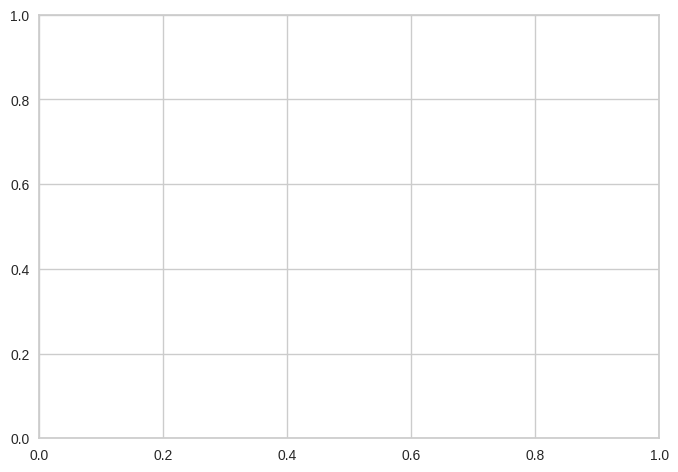

In [2]:
!pip install colorama
!pip install termcolor
!pip install matplotlib
!pip install xgboost
!pip install tensorflow


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
import seaborn as sns
import re
import plotly.express as px
import plotly.io as pio
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as missing_number
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, accuracy_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay
from yellowbrick.classifier import PrecisionRecallCurve

import nltk
nltk.download("punkt")
nltk.download('stopwords')
nltk.download('wordnet')

# Importing plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.express as px
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

#Figure&Display options
%matplotlib inline
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option('max_colwidth', 200)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)






import colorama
from colorama import Fore, Style  # maakes strings colored
from termcolor import colored

import ipywidgets

from ipywidgets import interact







# **User Defined Function**

In [3]:
def missing_values(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values[missing_values['Missing_Number']>0]

In [4]:
def first_looking(df):
    print(colored("Shape:", attrs=['bold']), df.shape,'\n',
          colored('-'*79, 'red', attrs=['bold']),
          colored("\nInfo:\n", attrs=['bold']), sep='')
    print(df.info(), '\n',
          colored('-'*79, 'red', attrs=['bold']), sep='')
    print(colored("Number of Uniques:\n", attrs=['bold']), df.nunique(),'\n',
          colored('-'*79, 'red', attrs=['bold']), sep='')
    print(colored("Missing Values:\n", attrs=['bold']), missing_values(df),'\n',
          colored('-'*79, 'red', attrs=['bold']), sep='')
    print(colored("All Columns:", attrs=['bold']), list(df.columns),'\n',
          colored('-'*79, 'red', attrs=['bold']), sep='')

    df.columns= df.columns.str.lower().str.replace('&', '_').str.replace(' ', '_')

    print(colored("Columns after rename:", attrs=['bold']), list(df.columns),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')


def multicolinearity_control(df):
    feature =[]
    collinear=[]
    for col in df.corr().columns:
        for i in df.corr().index:
            if (abs(df.corr()[col][i])> .9 and abs(df.corr()[col][i]) < 1):
                    feature.append(col)
                    collinear.append(i)
                    print(colored(f"Multicolinearity alert in between:{col} - {i}",
                                  "red", attrs=['bold']), df.shape,'\n',
                                  colored('-'*79, 'red', attrs=['bold']), sep='')

def duplicate_values(df):
    print(colored("Duplicate check...", attrs=['bold']), sep='')
    duplicate_values = df.duplicated(subset=None, keep='first').sum()
    if duplicate_values > 0:
        df.drop_duplicates(keep='first', inplace=True)
        print(duplicate_values, colored("Duplicates were dropped!"),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')
    else:
        print(colored("There are no duplicates"),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')

def drop_columns(df, drop_columns):
    if drop_columns !=[]:
        df.drop(drop_columns, axis=1, inplace=True)
        print(drop_columns, 'were dropped')
    else:
        print(colored('We will now check the missing values and if necessary will drop realted columns!', attrs=['bold']),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')

def drop_null(df, limit):
    print('Shape:', df.shape)
    for i in df.isnull().sum().index:
        if (df.isnull().sum()[i]/df.shape[0]*100)>limit:
            print(df.isnull().sum()[i], 'percent of', i ,'null and were dropped')
            df.drop(i, axis=1, inplace=True)
            print('new shape:', df.shape)
    print('New shape after missing value control:', df.shape)

## To view summary information about the column

In [5]:
def first_look(col):
    print("column name    : ", col)
    print("--------------------------------")
    print("per_of_nulls   : ", "%", round(df[col].isnull().sum()/df.shape[0]*100, 2))
    print("num_of_nulls   : ", df[col].isnull().sum())
    print("num_of_uniques : ", df[col].nunique())
    print(df[col].value_counts(dropna = False))

# Data Analysis

## Reading the Data

In [6]:
data = pd.read_csv('/content/drive/MyDrive/CSE445 (Project)/Womens Clothing E-Commerce Reviews.csv')
df = data.copy()
print(data.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')


## Information of data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [8]:
df.shape

(23486, 11)

## Showing Data

In [9]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses


# EDA - Data Visualization

## An Overview of the Data

In [10]:
first_looking(df)

Shape:(23486, 11)
-------------------------------------------------------------------------------
Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None
------------------------------------------

In [11]:
df.head(10)

,unnamed:_0,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses
5,5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of...",2,0,4,General,Dresses,Dresses
6,6,858,39,Cagrcoal shimmer fun,"I aded this in my basket at hte last mintue to see what it would look like in person. (store pick up). i went with teh darkler color only because i am so pale :-) hte color is really gorgeous, and...",5,1,1,General Petite,Tops,Knits
7,7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, and had a ton of stuff (as always) to try on and used this top to pair (skirts and pants). everything went with it. the color is really nice charcoal wi...",4,1,4,General Petite,Tops,Knits
8,8,1077,24,Flattering,I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,5,1,0,General,Dresses,Dresses
9,9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite to make sure the length wasn't too long. i typically wear an xs regular in retailer dresses. if you're less busty (34b cup or smaller), a s petite will...",5,1,0,General,Dresses,Dresses


In [12]:
df.sample(10)

,unnamed:_0,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name
5793,5793,818,61,Weird shape,"The pattern is very adorable. unfortunately the design is flawed. sizing is great at the waist and hip, and the length is spot on, but the top is wide. it's strange because i don't think it would ...",2,0,23,General,Tops,Blouses
16574,16574,916,39,Selling out...,"I ordered this on a whim as i though, hey, i don't have off the shoulder tops let's try ti, looks cute...\r\ni ordered the nude after debating, but glad i did, it is a bit warmer in color, and i n...",5,1,13,General Petite,Tops,Fine gauge
2438,2438,895,56,Comfortable but stylish,Great top for the older woman who wants to be stylish but needs a little extra room. the subtle color goes with anything. i love it!!,5,1,1,General Petite,Tops,Fine gauge
9369,9369,1059,46,NaN,"Thought this looked so cute, especially for averting frame. it arrived and was too large, the fabric felt super cheap, and the lace detail on the shoulders was very prominent.... and not in a good...",3,0,0,General Petite,Bottoms,Pants
2209,2209,867,22,NaN,"So soft. this is the best basic tee i've bought in a long time and it fits so nicely on my frame. i'm 5'8"" ans 130 lb, medium bust and got an xs.",5,1,0,General Petite,Tops,Knits
19798,19798,943,49,Gorgeous sweater... but not so flattering.,"I have to say, this sweater is gorgeous!!! i bought it in the green motif and absolutely loved the variety of colors used. i just didn't like the fit. it was so... blah. i felt like an old lady we...",4,1,2,General,Tops,Sweaters
4703,4703,836,37,Super cute top,Love the way this top fits. got many compliments on it! wish the arm holes were a little closer fit - can see the bra peeking out a teensy bit.,4,1,0,General Petite,Tops,Blouses
13578,13578,1077,35,Love the dress. runs very big.,Snagged this dress in store today. the only reason i didn't give it 5 stars is because it is dry clean only although i will probably attempt to home wash. it runs very large. i am usually a medium...,4,1,3,General,Dresses,Dresses
17692,17692,1092,35,Lovely dress,"This dress will be very useful. it fits loose, but it is suppose to. i plan to wear this to casual parties, out to dinner, and possibly a wedding at a winery. i weigh am 5' 6"", weigh 145 lbs, and ...",4,1,5,General,Dresses,Dresses
4257,4257,1081,27,"Great dress, even better with a belt!","Easy to wear and very cute, especially for curvy ladies. but, i think it looks best worn with a best, or a blazer on top, something to emphasize the waist a bit more.",4,1,0,General,Dresses,Dresses


In [13]:
df.drop("unnamed:_0", axis=1, inplace=True)
df.head(10)

,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses
5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of...",2,0,4,General,Dresses,Dresses
6,858,39,Cagrcoal shimmer fun,"I aded this in my basket at hte last mintue to see what it would look like in person. (store pick up). i went with teh darkler color only because i am so pale :-) hte color is really gorgeous, and...",5,1,1,General Petite,Tops,Knits
7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, and had a ton of stuff (as always) to try on and used this top to pair (skirts and pants). everything went with it. the color is really nice charcoal wi...",4,1,4,General Petite,Tops,Knits
8,1077,24,Flattering,I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,5,1,0,General,Dresses,Dresses
9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite to make sure the length wasn't too long. i typically wear an xs regular in retailer dresses. if you're less busty (34b cup or smaller), a s petite will...",5,1,0,General,Dresses,Dresses


### Statistical Analysis

In [14]:
df.describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu').format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max
clothing_id,23486.00,918.12,203.30,0.00,861.00,936.00,1078.00,1205.00
age,23486.00,43.20,12.28,18.00,34.00,41.00,52.00,99.00
rating,23486.00,4.20,1.11,1.00,4.00,5.00,5.00,5.00
recommended_ind,23486.00,0.82,0.38,0.00,1.00,1.00,1.00,1.00
positive_feedback_count,23486.00,2.54,5.70,0.00,0.00,1.00,3.00,122.00


In [15]:
df.describe(include=object).T

,count,unique,top,freq
title,19676,13993,Love it!,136
review_text,22641,22634,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,3
division_name,23472,3,General,13850
department_name,23472,6,Tops,10468
class_name,23472,20,Dresses,6319


### to find how many unique values clothing_id (Numerical) features have

In [16]:
for col in df.select_dtypes(include=[np.number]).columns:
  print(colored(f"{col}", 'green', attrs=['bold']), f"feature has", colored(f"{df[col].nunique()}", 'green', attrs=['bold']), f"unique values.")

clothing_id feature has 1206 unique values.
age feature has 77 unique values.
rating feature has 5 unique values.
recommended_ind feature has 2 unique values.
positive_feedback_count feature has 82 unique values.


### to find how many unique values title (Object) features have

In [17]:
for col in df.select_dtypes(include="object").columns:
  print(colored(f"{col}", 'green', attrs=['bold']), f"feature has", colored(f"{df[col].nunique()}", 'green', attrs=['bold']), f"unique values.")

title feature has 13993 unique values.
review_text feature has 22634 unique values.
division_name feature has 3 unique values.
department_name feature has 6 unique values.
class_name feature has 20 unique values.


### Graph Plotting

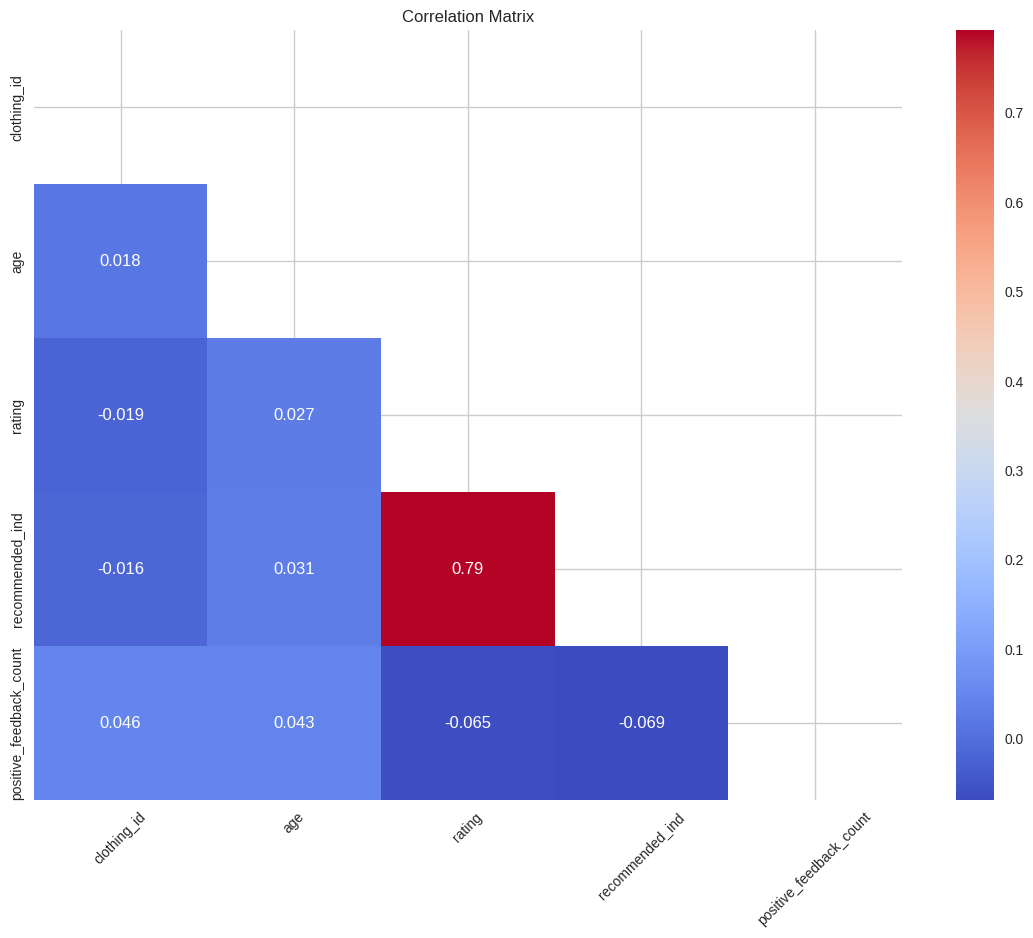

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include='number')


matrix = np.triu(numeric_df.corr())

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', mask=matrix)
plt.xticks(rotation=45)
plt.title('Correlation Matrix')
plt.show()


## Analyzing the Target Variable

In [19]:
df.columns

Index(['clothing_id', 'age', 'title', 'review_text', 'rating',
       'recommended_ind', 'positive_feedback_count', 'division_name',
       'department_name', 'class_name'],
      dtype='object')

In [20]:
df["division_name"].value_counts()

division_name
General           13850
General Petite     8120
Initmates          1502
Name: count, dtype: int64

In [21]:
df["recommended_ind"].value_counts()

recommended_ind
1    19314
0     4172
Name: count, dtype: int64

In [22]:
first_look("recommended_ind")

column name    :  recommended_ind
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  2
recommended_ind
1    19314
0     4172
Name: count, dtype: int64


In [23]:
df["recommended_ind"].describe().T

count   23486.00
mean        0.82
std         0.38
min         0.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
Name: recommended_ind, dtype: float64

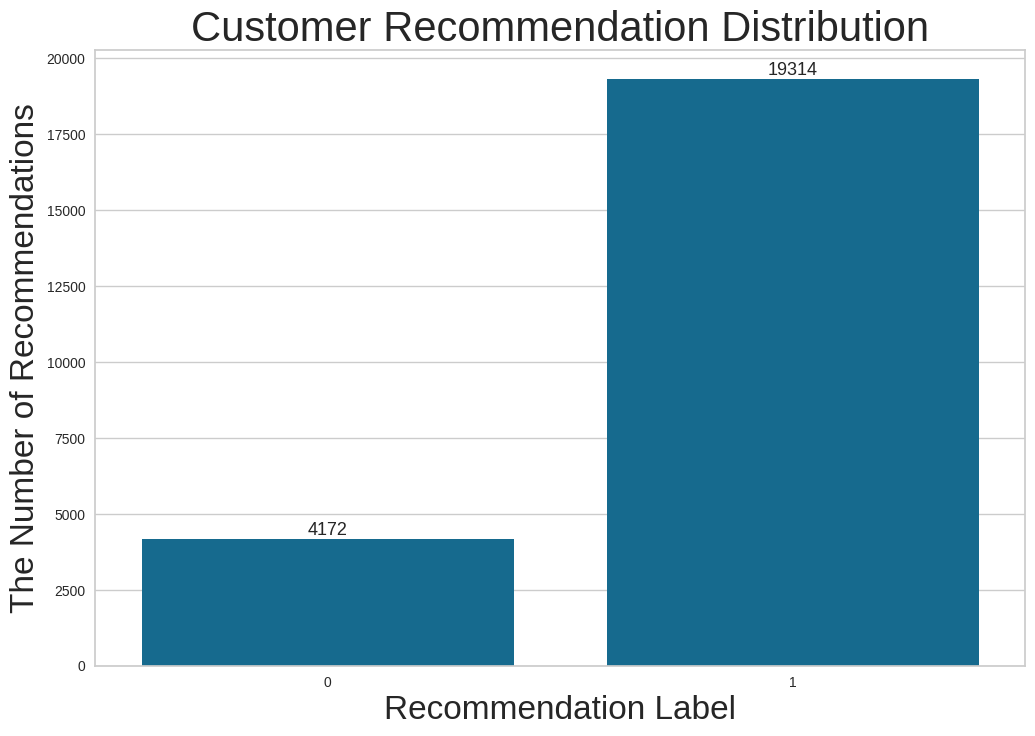

In [24]:
sns.countplot(x = df.recommended_ind, data = df)
plt.title('Customer Recommendation Distribution', fontsize=30)
plt.xlabel("Recommendation Label", fontsize=24)
plt.ylabel("The Number of Recommendations", fontsize=24)

for index,value in enumerate(df.recommended_ind.value_counts().sort_values()):
     plt.text(index, value, f"{value}", ha="center", va="bottom", fontsize = 13);

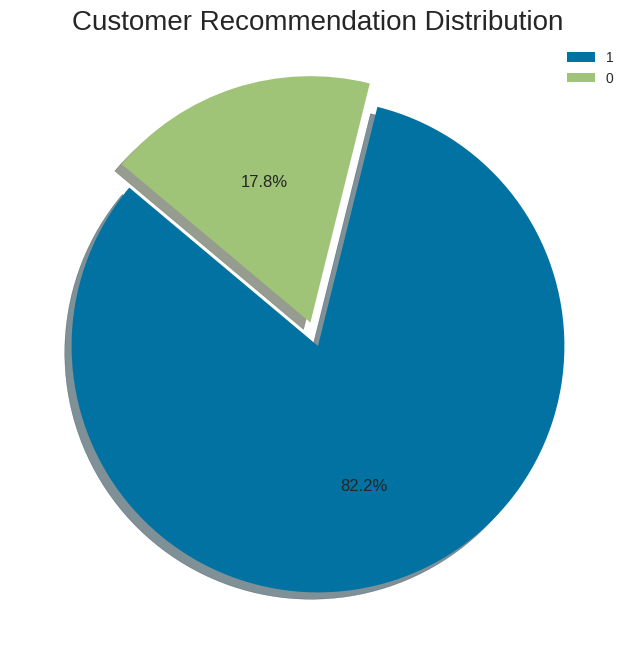

In [25]:
plt.figure(figsize=(8, 8))

explode = [0, 0.1]
plt.pie(df['recommended_ind'].value_counts(), explode=explode, autopct='%1.1f%%', shadow=True, startangle=140)
plt.legend(labels=['1', '0'])
plt.title('Customer Recommendation Distribution', fontsize=20)
plt.axis('off');

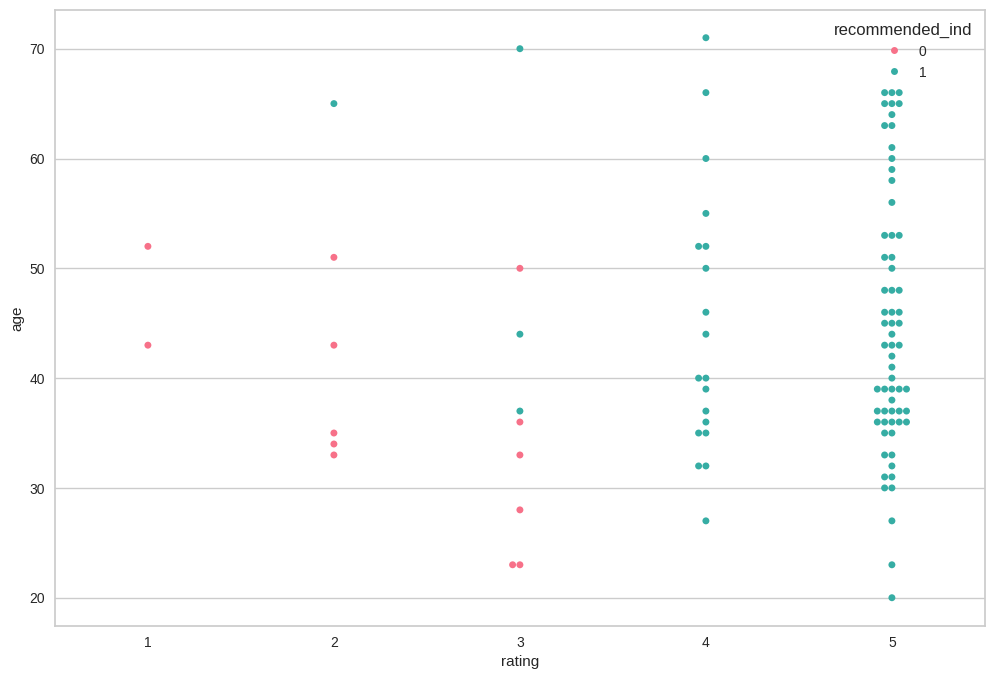

In [26]:
sampled_df = df.sample(n=100)
sns.swarmplot(y="age", x="rating", hue="recommended_ind", data=sampled_df, palette="husl");

<Axes: xlabel='division_name', ylabel='age'>

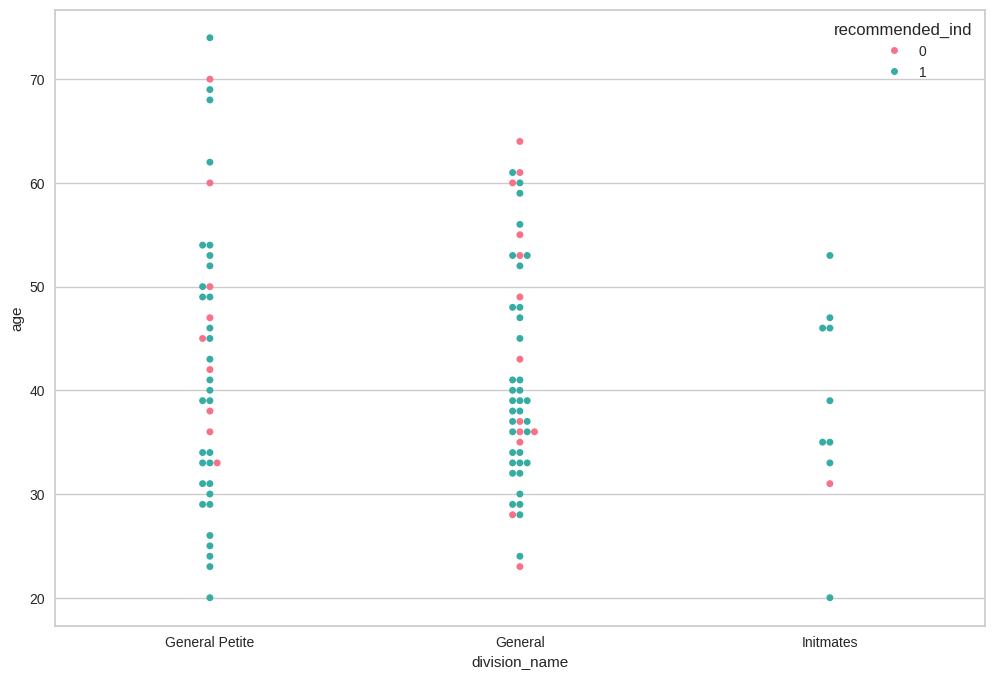

In [27]:
sampled_df = df.sample(n=100)
sns.swarmplot(y="age", x="division_name", hue="recommended_ind", data=sampled_df, palette="husl")

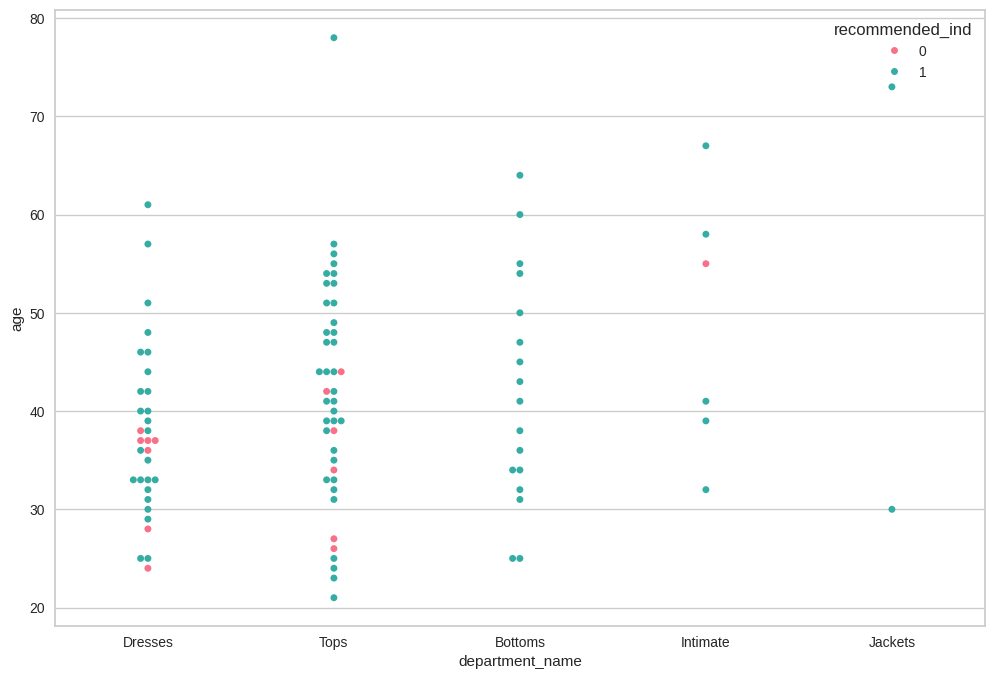

In [28]:
sampled_df = df.sample(n=100)
sns.swarmplot(y="age", x="department_name", hue="recommended_ind", data=sampled_df, palette="husl");

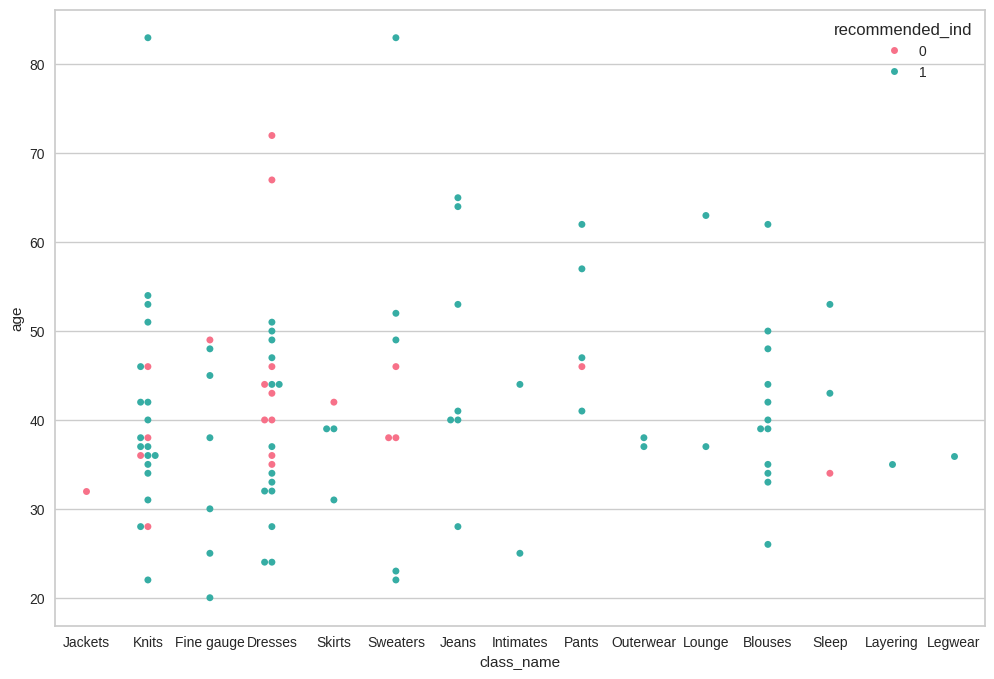

In [29]:
sampled_df = df.sample(n=100)
sns.swarmplot(y="age", x="class_name", hue="recommended_ind", data=sampled_df, palette="husl");

### Exaimining Other Features

In [30]:
df["rating"].value_counts()

rating
5    13131
4     5077
3     2871
2     1565
1      842
Name: count, dtype: int64

In [31]:
first_look("rating")

column name    :  rating
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  5
rating
5    13131
4     5077
3     2871
2     1565
1      842
Name: count, dtype: int64


In [32]:
df["rating"].describe().T

count   23486.00
mean        4.20
std         1.11
min         1.00
25%         4.00
50%         5.00
75%         5.00
max         5.00
Name: rating, dtype: float64

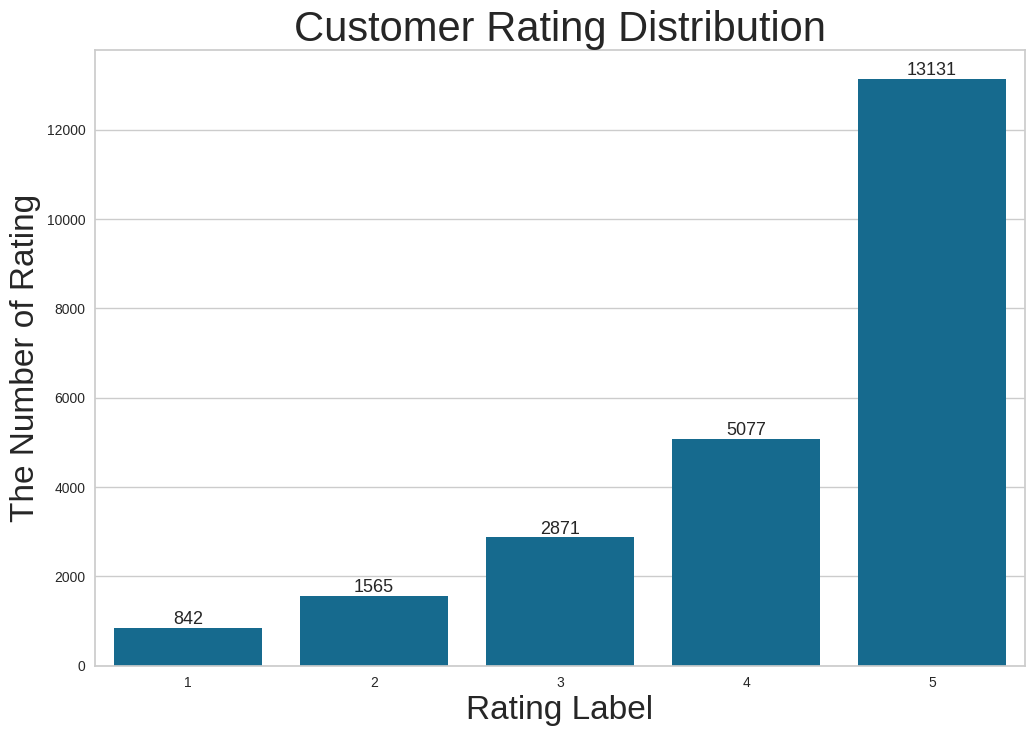

In [33]:
sns.countplot(x = df.rating, data = df)
plt.title('Customer Rating Distribution', fontsize=30)
plt.xlabel("Rating Label", fontsize=24)
plt.ylabel("The Number of Rating", fontsize=24)

for index,value in enumerate(df.rating.value_counts().sort_values()):
     plt.text(index, value, f"{value}", ha="center", va="bottom", fontsize = 13);

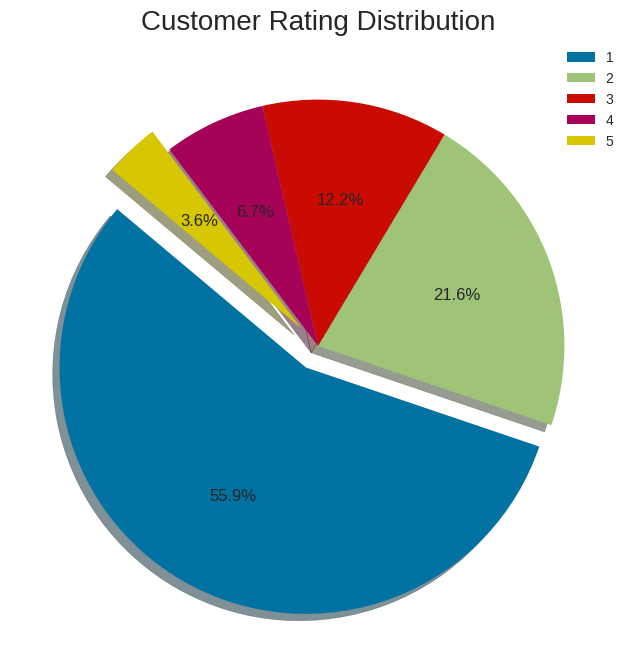

In [34]:
plt.figure(figsize=(8, 8))

explode = [0.1, 0, 0, 0, 0.1]
plt.pie(df['rating'].value_counts(), explode=explode, autopct='%1.1f%%', shadow=True, startangle=140)
plt.legend(labels=['1', '2', '3', '4','5'])
plt.title('Customer Rating Distribution', fontsize=20)
plt.axis('off');

In [35]:
df["age"].value_counts()

age
39    1269
35     909
36     842
34     804
38     780
37     766
41     741
33     725
46     713
42     651
32     631
48     626
40     617
44     617
43     579
31     569
47     564
53     560
45     529
29     513
49     490
56     471
52     442
28     428
26     423
30     407
50     398
54     395
51     393
57     363
27     344
60     341
62     338
25     331
55     328
59     321
58     277
66     276
64     247
23     247
24     245
63     239
61     227
65     226
67     157
22     146
68     141
69     113
20     108
21     102
70      93
71      51
74      50
72      46
83      43
19      40
73      40
75      26
77      18
78      15
79      15
82      13
76      10
80      10
85       6
84       6
89       5
81       5
91       5
18       4
87       4
94       3
93       2
90       2
86       2
99       2
92       1
Name: count, dtype: int64

In [36]:
first_look("age")

column name    :  age
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  77
age
39    1269
35     909
36     842
34     804
38     780
37     766
41     741
33     725
46     713
42     651
32     631
48     626
40     617
44     617
43     579
31     569
47     564
53     560
45     529
29     513
49     490
56     471
52     442
28     428
26     423
30     407
50     398
54     395
51     393
57     363
27     344
60     341
62     338
25     331
55     328
59     321
58     277
66     276
64     247
23     247
24     245
63     239
61     227
65     226
67     157
22     146
68     141
69     113
20     108
21     102
70      93
71      51
74      50
72      46
83      43
19      40
73      40
75      26
77      18
78      15
79      15
82      13
76      10
80      10
85       6
84       6
89       5
81       5
91       5
18       4
87       4
94       3
93       2
90       2
86       2
99       2
92       1
Name: count, dtype: int64


In [37]:
df["age"].describe().T

count   23486.00
mean       43.20
std        12.28
min        18.00
25%        34.00
50%        41.00
75%        52.00
max        99.00
Name: age, dtype: float64

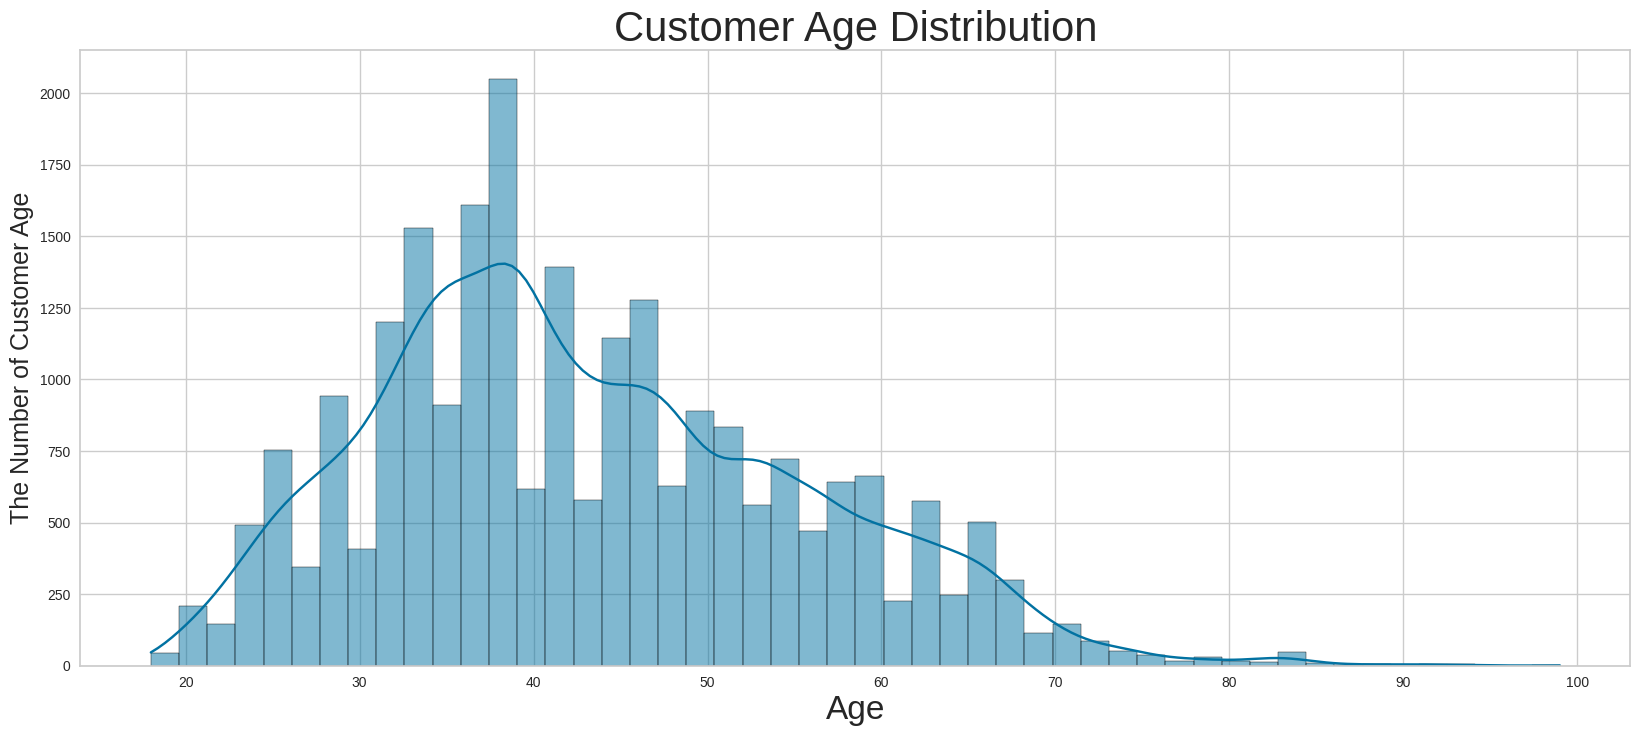

In [38]:
plt.figure(figsize = (20, 8))
plt.title('Customer Age Distribution', fontsize=30)
plt.xlabel("Age", fontsize=24)
plt.ylabel("The Number of Customer Age", fontsize=18)

sns.histplot(df, x='age', kde = True, bins = 50);

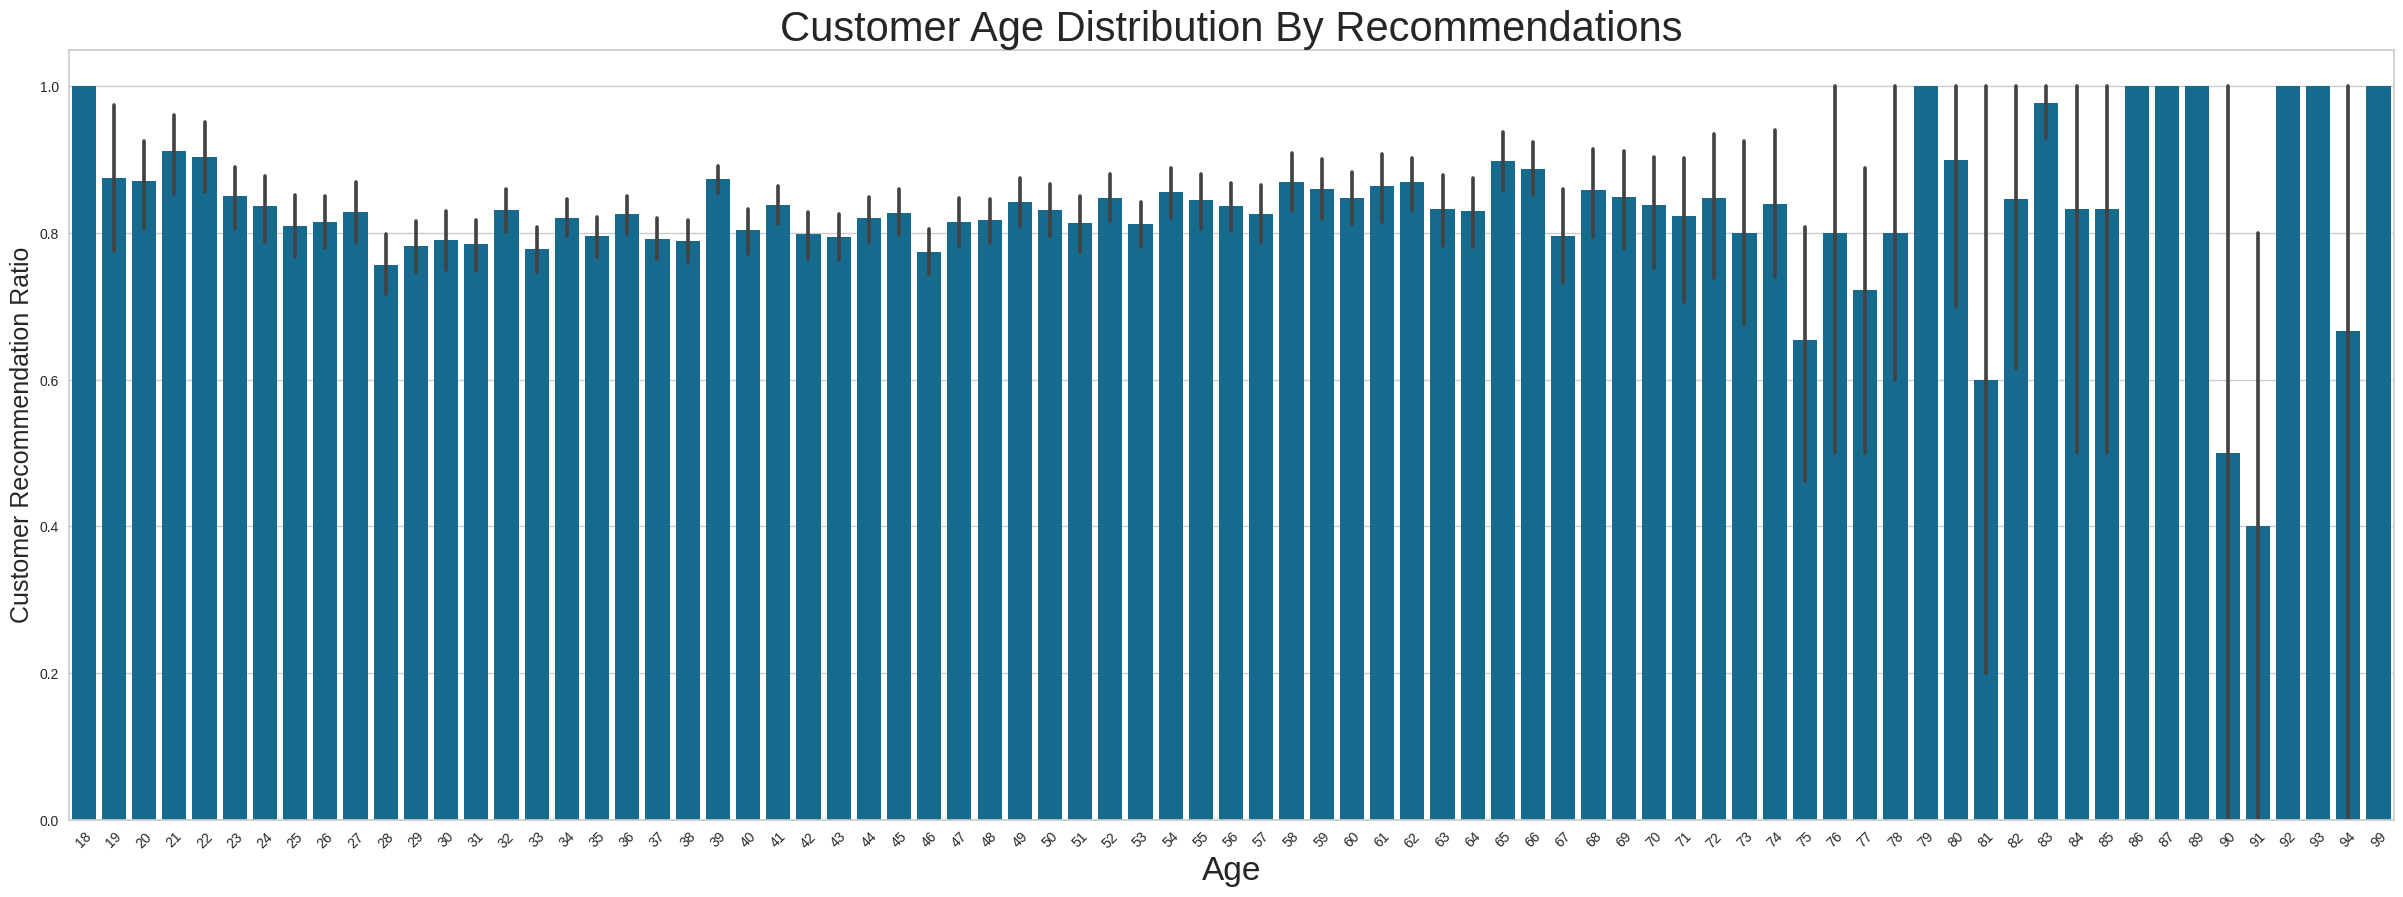

In [39]:
fig_dims = (30, 10)
fig, ax = plt.subplots(figsize=fig_dims)
sns.barplot(data = df, x = "age", y = "recommended_ind", ax=ax)

plt.title('Customer Age Distribution By Recommendations', fontsize=30)
plt.xlabel("Age", fontsize=24)
plt.ylabel("Customer Recommendation Ratio", fontsize=18)
plt.xticks(rotation = 45);

In [40]:

fig = px.histogram(df['age'], color=df['recommended_ind'],
                   labels={'value': 'Age', 'color': 'Recommended'},
                   color_discrete_map={0: "magenta", 1: "MediumPurple"},
                   marginal='box')
fig.update_traces(marker=dict(line=dict(color='#000000', width=2)))
fig.update_layout(title_text='Distribution of the Age and Recommendation',
                  title_x=0.5, title_font=dict(size=20))
fig.update_layout(barmode='overlay')


pio.renderers.default = 'colab'


fig.show()

In [41]:
df["positive_feedback_count"].value_counts()

positive_feedback_count
0      11176
1       4043
2       2193
3       1433
4        922
5        673
6        525
7        374
8        319
9        261
10       225
11       178
12       146
14       121
13       102
15        94
17        81
16        74
18        62
19        54
20        40
23        31
21        30
22        29
25        25
28        24
26        23
24        21
27        20
30        18
31        17
29        15
32        10
42         9
37         9
38         8
34         7
35         6
36         6
33         6
51         5
81         4
45         4
39         4
65         4
43         4
40         3
47         3
57         3
41         3
44         3
53         2
49         2
46         2
58         2
55         2
64         1
89         1
68         1
56         1
48         1
98         1
93         1
95         1
50         1
99         1
87         1
69         1
66         1
54         1
108        1
122        1
52         1
78         1
82         1
6

In [42]:
first_look("positive_feedback_count")

column name    :  positive_feedback_count
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  82
positive_feedback_count
0      11176
1       4043
2       2193
3       1433
4        922
5        673
6        525
7        374
8        319
9        261
10       225
11       178
12       146
14       121
13       102
15        94
17        81
16        74
18        62
19        54
20        40
23        31
21        30
22        29
25        25
28        24
26        23
24        21
27        20
30        18
31        17
29        15
32        10
42         9
37         9
38         8
34         7
35         6
36         6
33         6
51         5
81         4
45         4
39         4
65         4
43         4
40         3
47         3
57         3
41         3
44         3
53         2
49         2
46         2
58         2
55         2
64         1
89         1
68         1
56         1
48         1
98         1
93         1
95         1
50  

In [43]:
df["positive_feedback_count"].describe().T

count   23486.00
mean        2.54
std         5.70
min         0.00
25%         0.00
50%         1.00
75%         3.00
max       122.00
Name: positive_feedback_count, dtype: float64

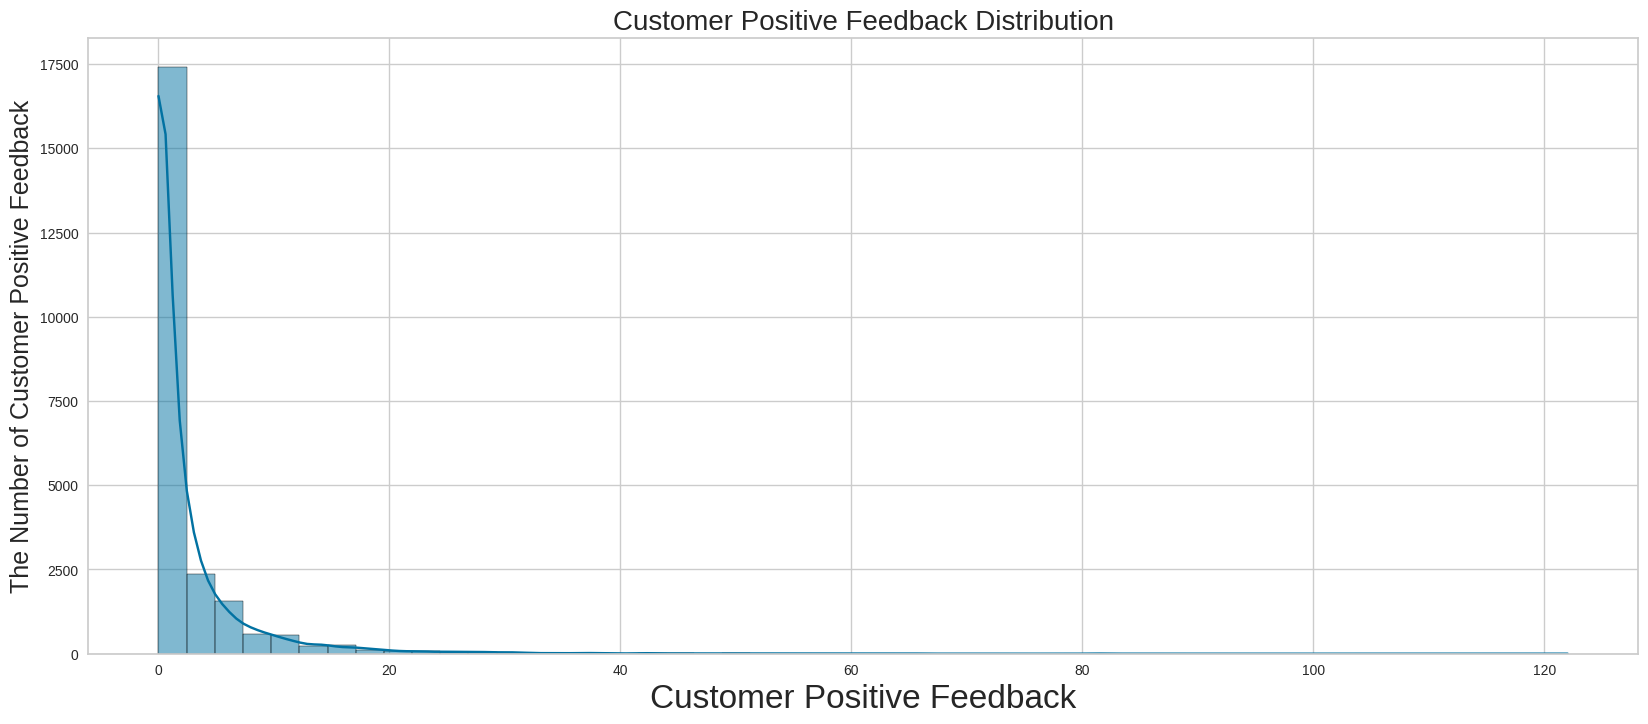

In [44]:
plt.figure(figsize = (20, 8))
plt.title('Customer Positive Feedback Distribution', fontsize=20)
plt.xlabel("Customer Positive Feedback", fontsize=24)
plt.ylabel("The Number of Customer Positive Feedback", fontsize=18)

sns.histplot(df, x='positive_feedback_count', kde = True, bins = 50);

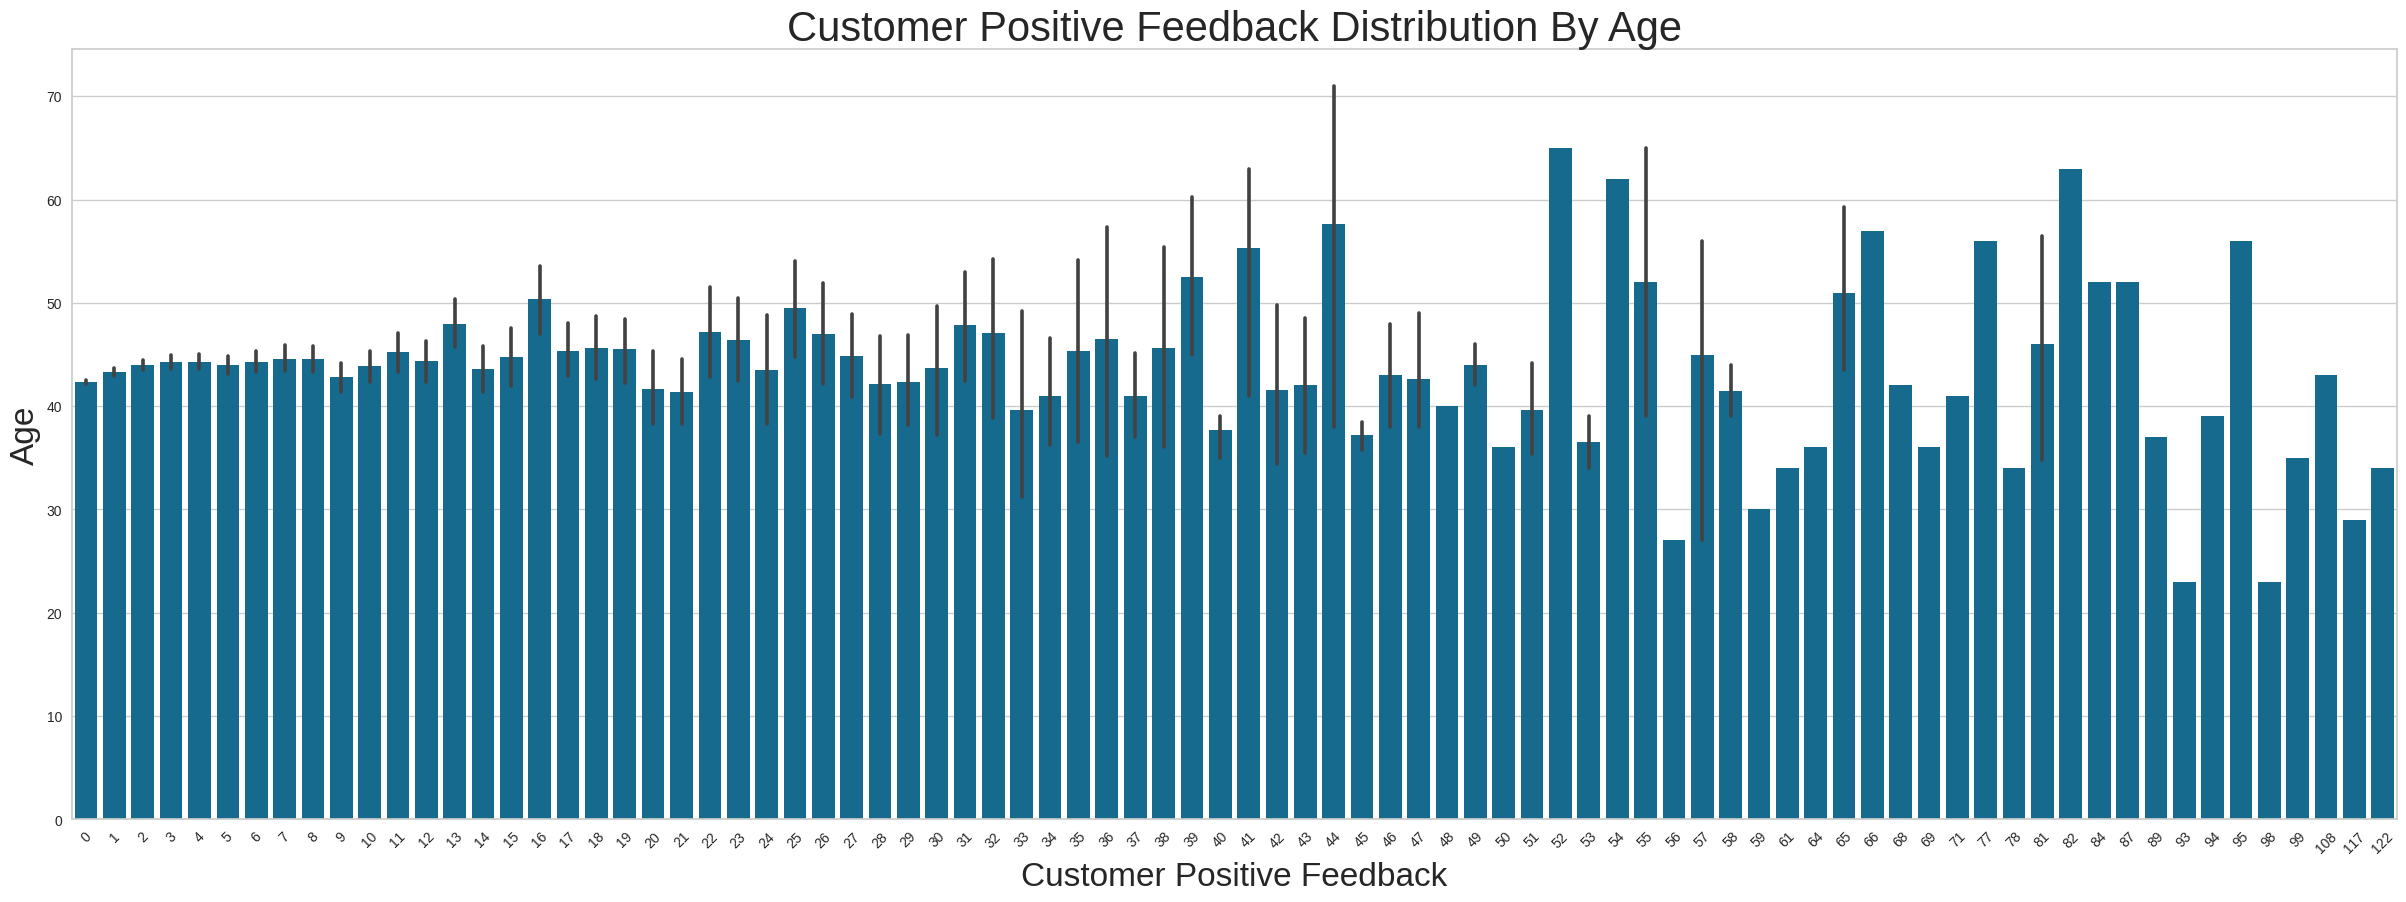

In [45]:
fig_dims = (30, 10)
fig, ax = plt.subplots(figsize=fig_dims)
sns.barplot(data = df, x = "positive_feedback_count", y = "age", ax=ax)

plt.xlabel("Customer Positive Feedback", fontsize=24)
plt.ylabel("Age", fontsize=24)

plt.title('Customer Positive Feedback Distribution By Age', fontsize=30)
plt.xticks(rotation = 45);

In [46]:
df["division_name"].value_counts()

division_name
General           13850
General Petite     8120
Initmates          1502
Name: count, dtype: int64

In [47]:
first_look("division_name")

column name    :  division_name
--------------------------------
per_of_nulls   :  % 0.06
num_of_nulls   :  14
num_of_uniques :  3
division_name
General           13850
General Petite     8120
Initmates          1502
NaN                  14
Name: count, dtype: int64


In [48]:
df["division_name"].describe().T

count       23472
unique          3
top       General
freq        13850
Name: division_name, dtype: object

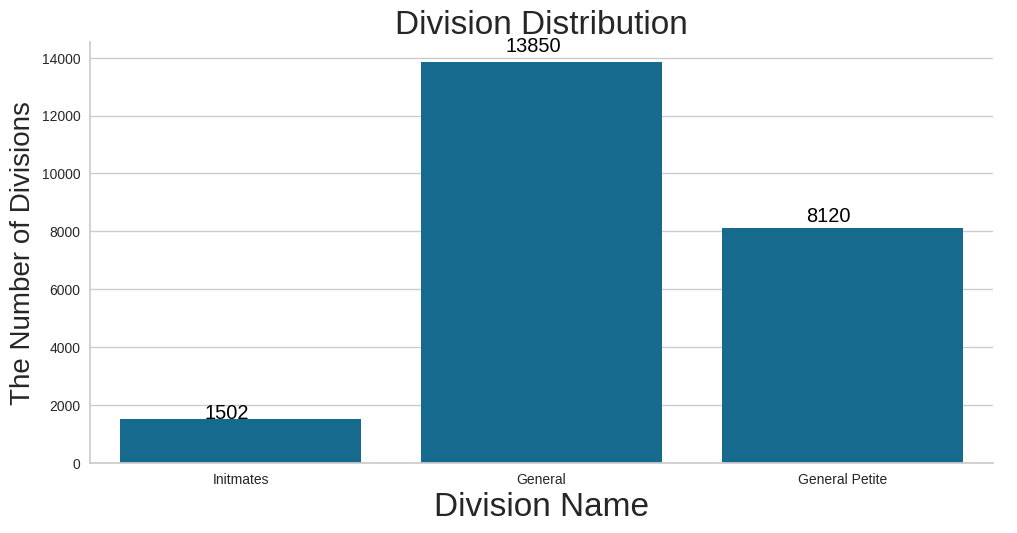

In [49]:
g = sns.catplot( x='division_name',
             kind="count",
             data=df,
             height=5,
             aspect=2)

plt.title('Division Distribution', fontsize=24)
plt.xlabel("Division Name", fontsize=24)
plt.ylabel("The Number of Divisions", fontsize=20)

ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.28,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', size='large')

plt.show()

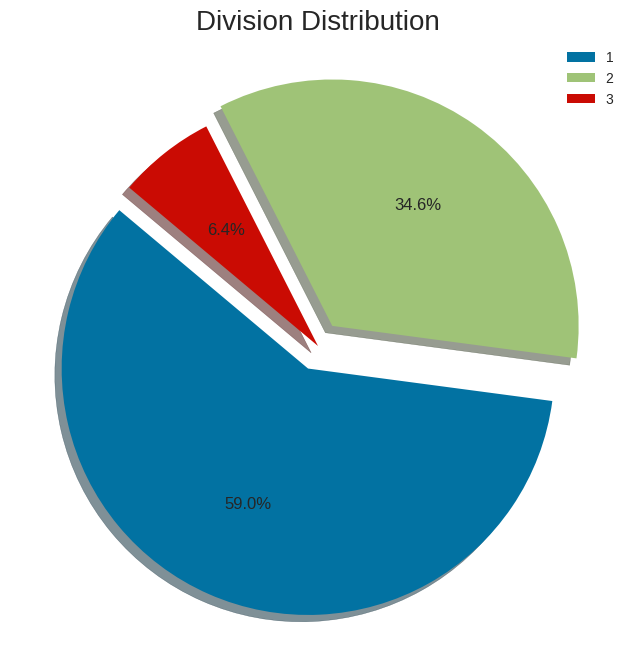

In [50]:
plt.figure(figsize=(8, 8))

explode = [0.1, 0.1, 0]
plt.pie(df['division_name'].value_counts(), explode=explode, autopct='%1.1f%%', shadow=True, startangle=140)
plt.legend(labels=['1', '2', '3'])
plt.title('Division Distribution', fontsize=20)
plt.axis('off');



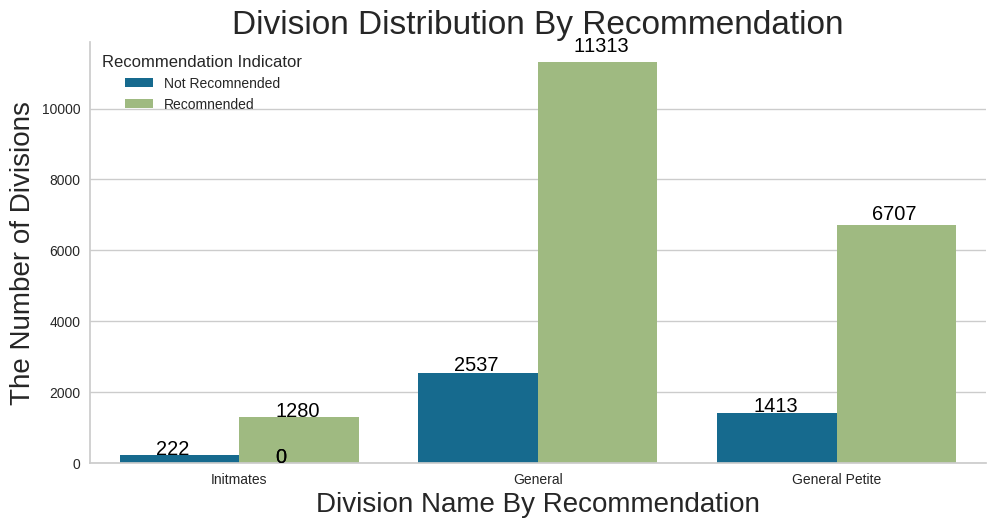

In [51]:
g = sns.catplot(data = df, x ="division_name", hue = "recommended_ind", kind='count', height=5, aspect=2, legend_out=False)

plt.title('Division Distribution By Recommendation', fontsize=24)
plt.xlabel("Division Name By Recommendation", fontsize=20)
plt.ylabel("The Number of Divisions", fontsize=20)
plt.legend(title='Recommendation Indicator', loc='upper left', labels=['Not Recomnended', 'Recomnended'])

ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.12,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', size='large')

plt.show()

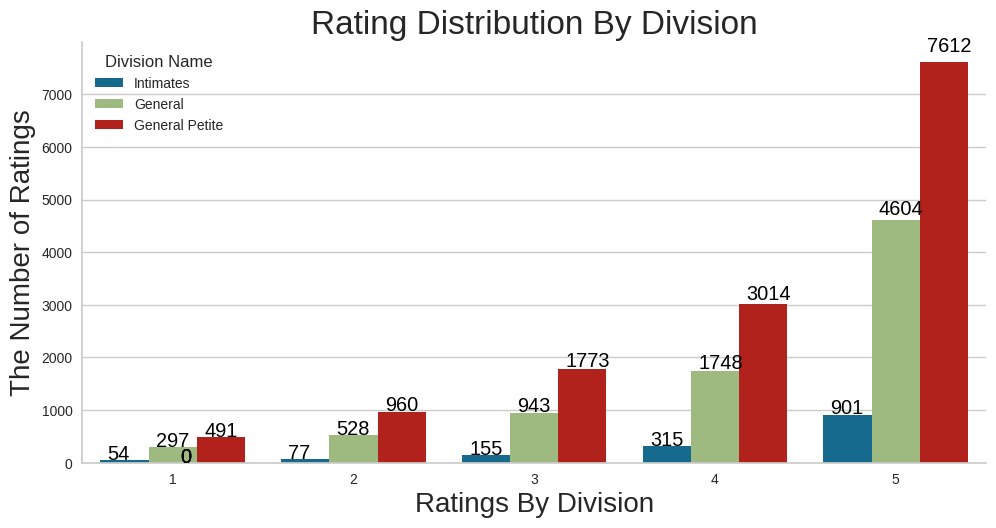

In [52]:
g = sns.catplot(data = df, x ="rating", hue = "division_name", kind='count', height=5, aspect=2, legend_out=False)

plt.title('Rating Distribution By Division', fontsize=24)
plt.xlabel("Ratings By Division", fontsize=20)
plt.ylabel("The Number of Ratings", fontsize=20)
plt.legend(title='Division Name', loc='upper left', labels=['Intimates', 'General', 'General Petite'])

ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.04,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', size='large')

plt.show()

In [53]:
df["department_name"].value_counts()

department_name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Name: count, dtype: int64

In [54]:
first_look("department_name")

column name    :  department_name
--------------------------------
per_of_nulls   :  % 0.06
num_of_nulls   :  14
num_of_uniques :  6
department_name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
NaN            14
Name: count, dtype: int64


In [55]:
df["department_name"].describe().T

count     23472
unique        6
top        Tops
freq      10468
Name: department_name, dtype: object

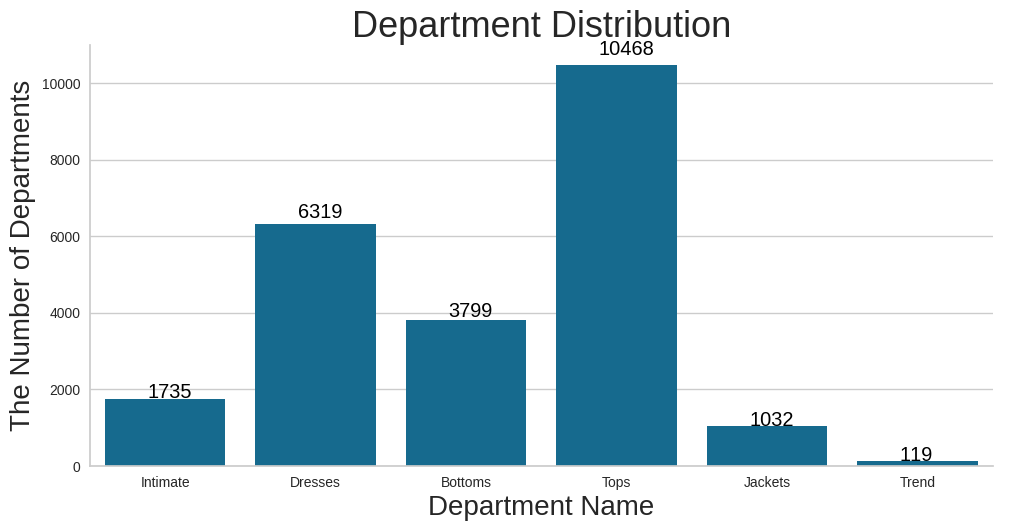

In [56]:
g = sns.catplot(data = df, x ="department_name", kind='count', height=5, aspect=2)

plt.title('Department Distribution', fontsize=26)
plt.xlabel("Department Name", fontsize=20)
plt.ylabel("The Number of Departments", fontsize=20)

ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.28,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', size='large')

plt.show()

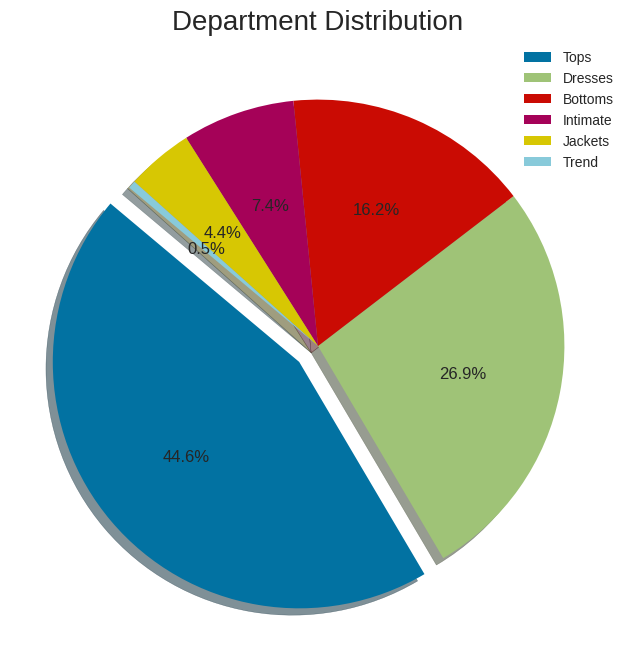

In [57]:
plt.figure(figsize=(8, 8))

explode = [0.1, 0, 0, 0, 0, 0]
plt.pie(df['department_name'].value_counts(), explode=explode, autopct='%1.1f%%', shadow=True, startangle=140)
plt.legend(labels=['Tops', 'Dresses', 'Bottoms', 'Intimate', 'Jackets', 'Trend'])
plt.title('Department Distribution', fontsize=20)
plt.axis('off');

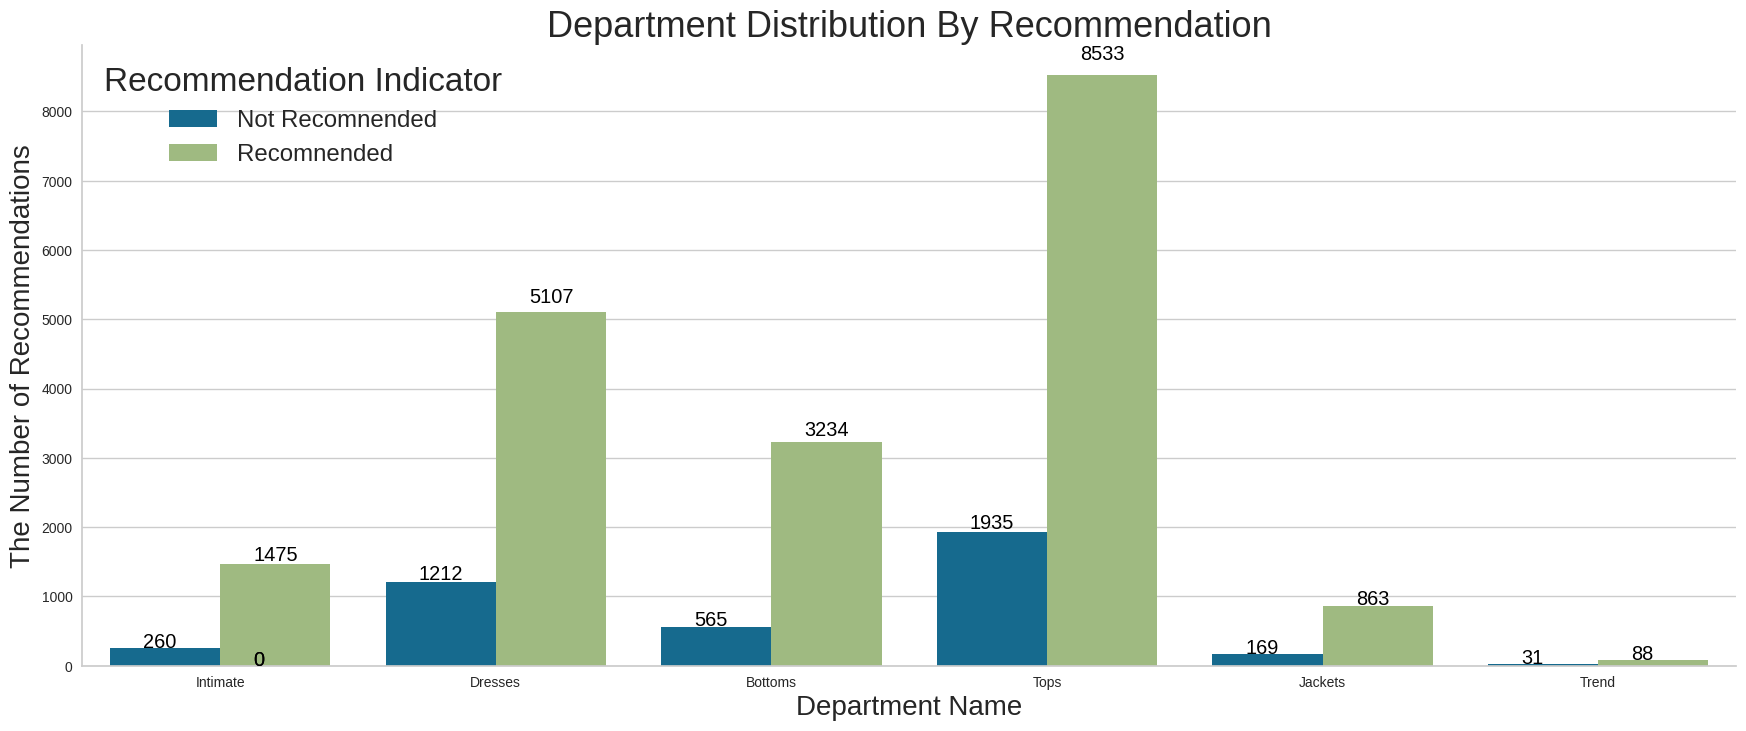

In [58]:
g = sns.catplot(data = df, x ="department_name", hue = "recommended_ind", kind='count', height=7, aspect=2.5, legend_out=False)

plt.title('Department Distribution By Recommendation', fontsize=26)
plt.xlabel("Department Name", fontsize=20)
plt.ylabel("The Number of Recommendations", fontsize=20)
plt.legend(title='Recommendation Indicator', loc='upper left', labels=['Not Recomnended', 'Recomnended'], fontsize='x-large', title_fontsize='24')

ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.12,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', size='large')

plt.show()

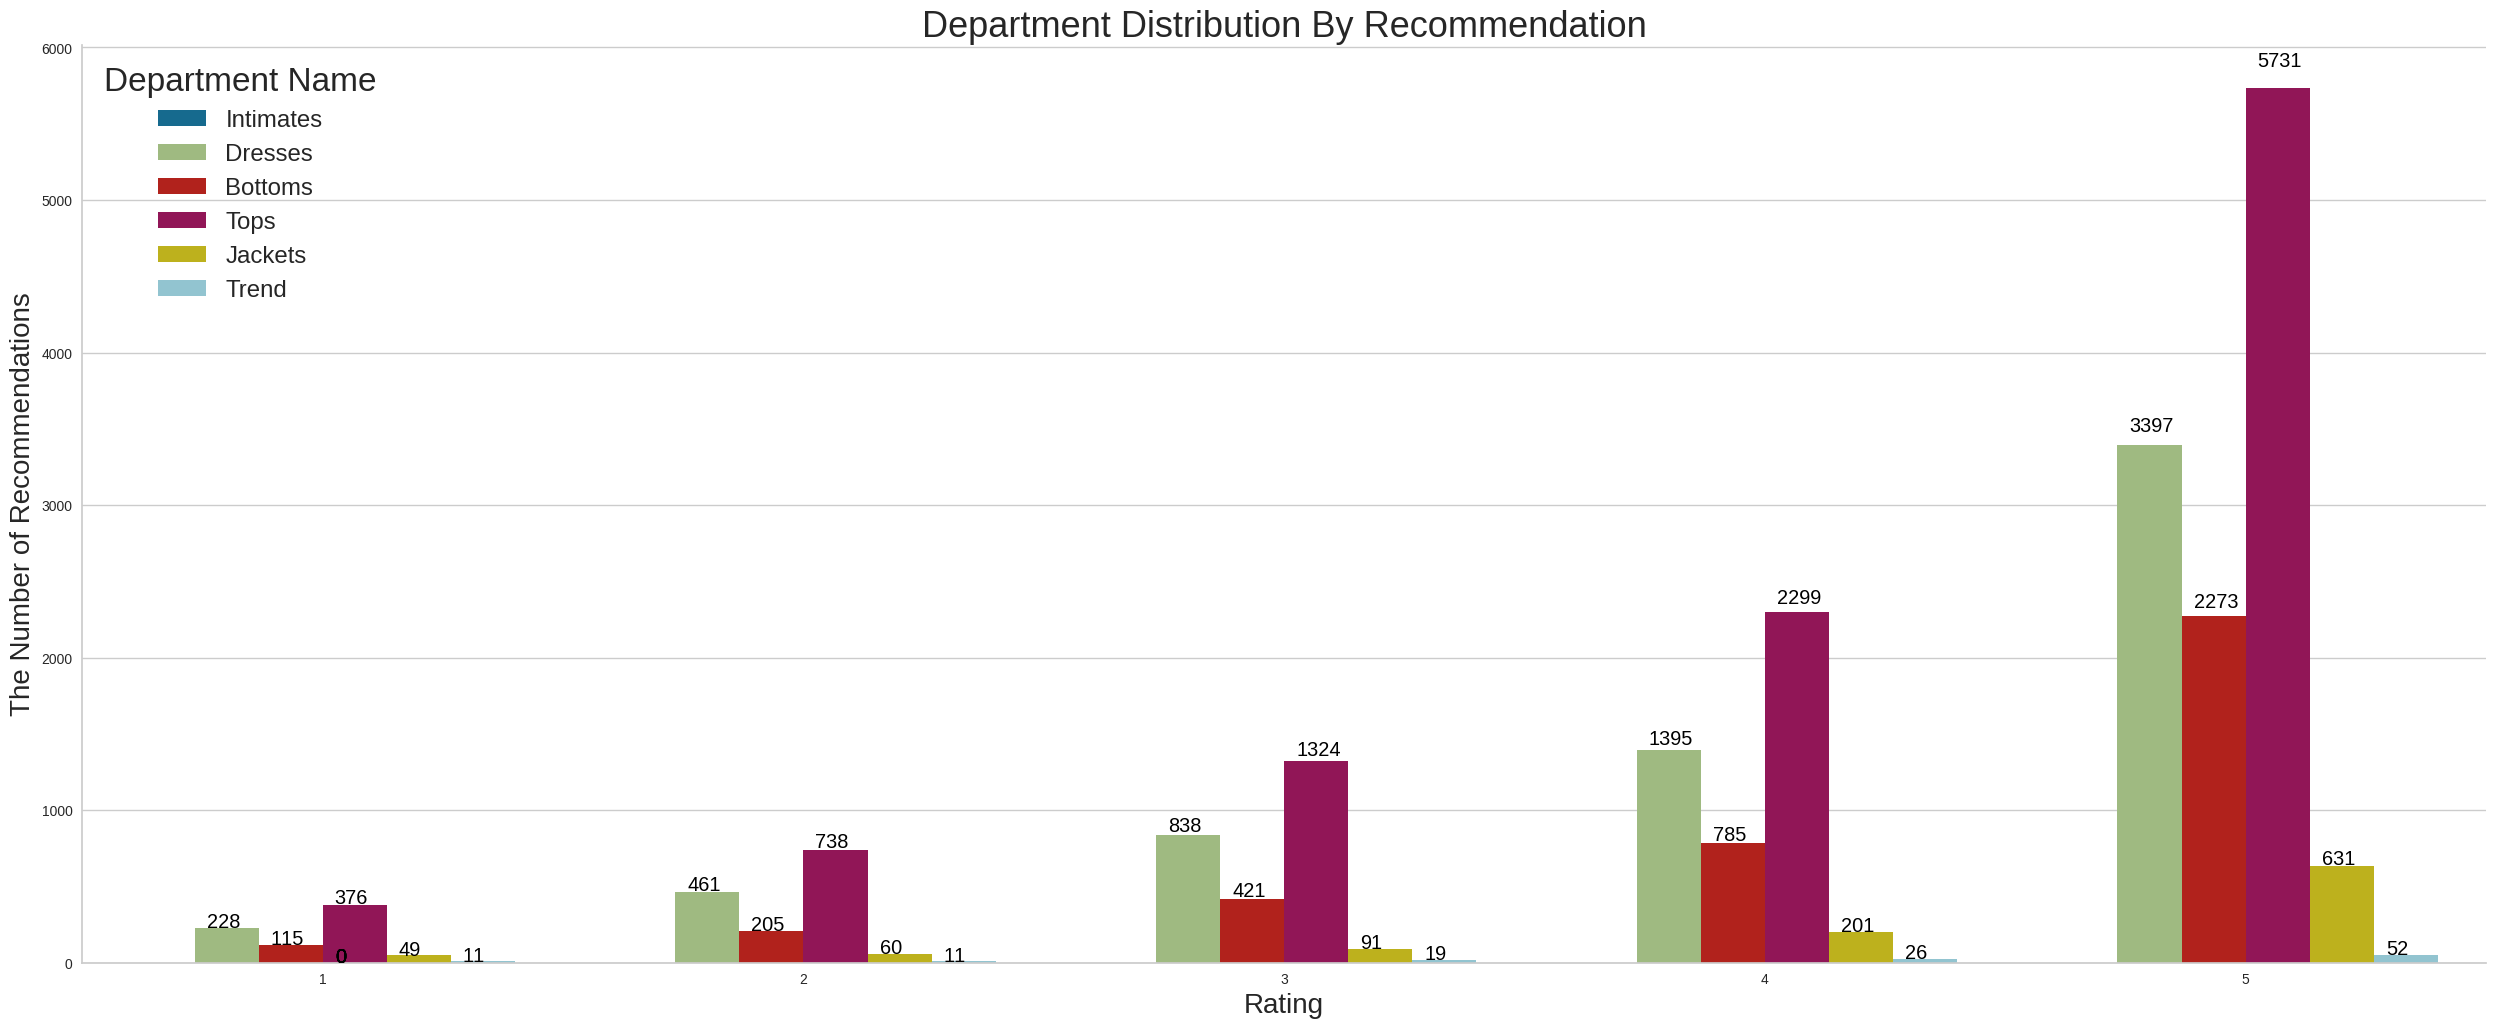

In [59]:



category_order = ['Intimates', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']


g = sns.catplot(data=df, x="rating", hue="department_name", kind='count', height=10, aspect=2.5, legend_out=False, order=[1, 2, 3, 4, 5], hue_order=category_order)

plt.title('Department Distribution By Recommendation', fontsize=26)
plt.xlabel("Rating", fontsize=20)  # Corrected xlabel
plt.ylabel("The Number of Recommendations", fontsize=20)
plt.legend(title='Department Name', loc='upper left', labels=category_order, fontsize='x-large', title_fontsize=24)


ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.025,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', fontsize='large')


plt.show()


### Examining of Class_name Variable

In [60]:
df["class_name"].value_counts()

class_name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
Casual bottoms       2
Chemises             1
Name: count, dtype: int64

In [61]:
first_look("class_name")

column name    :  class_name
--------------------------------
per_of_nulls   :  % 0.06
num_of_nulls   :  14
num_of_uniques :  20
class_name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
NaN                 14
Casual bottoms       2
Chemises             1
Name: count, dtype: int64


In [62]:
df["class_name"].describe().T

count       23472
unique         20
top       Dresses
freq         6319
Name: class_name, dtype: object

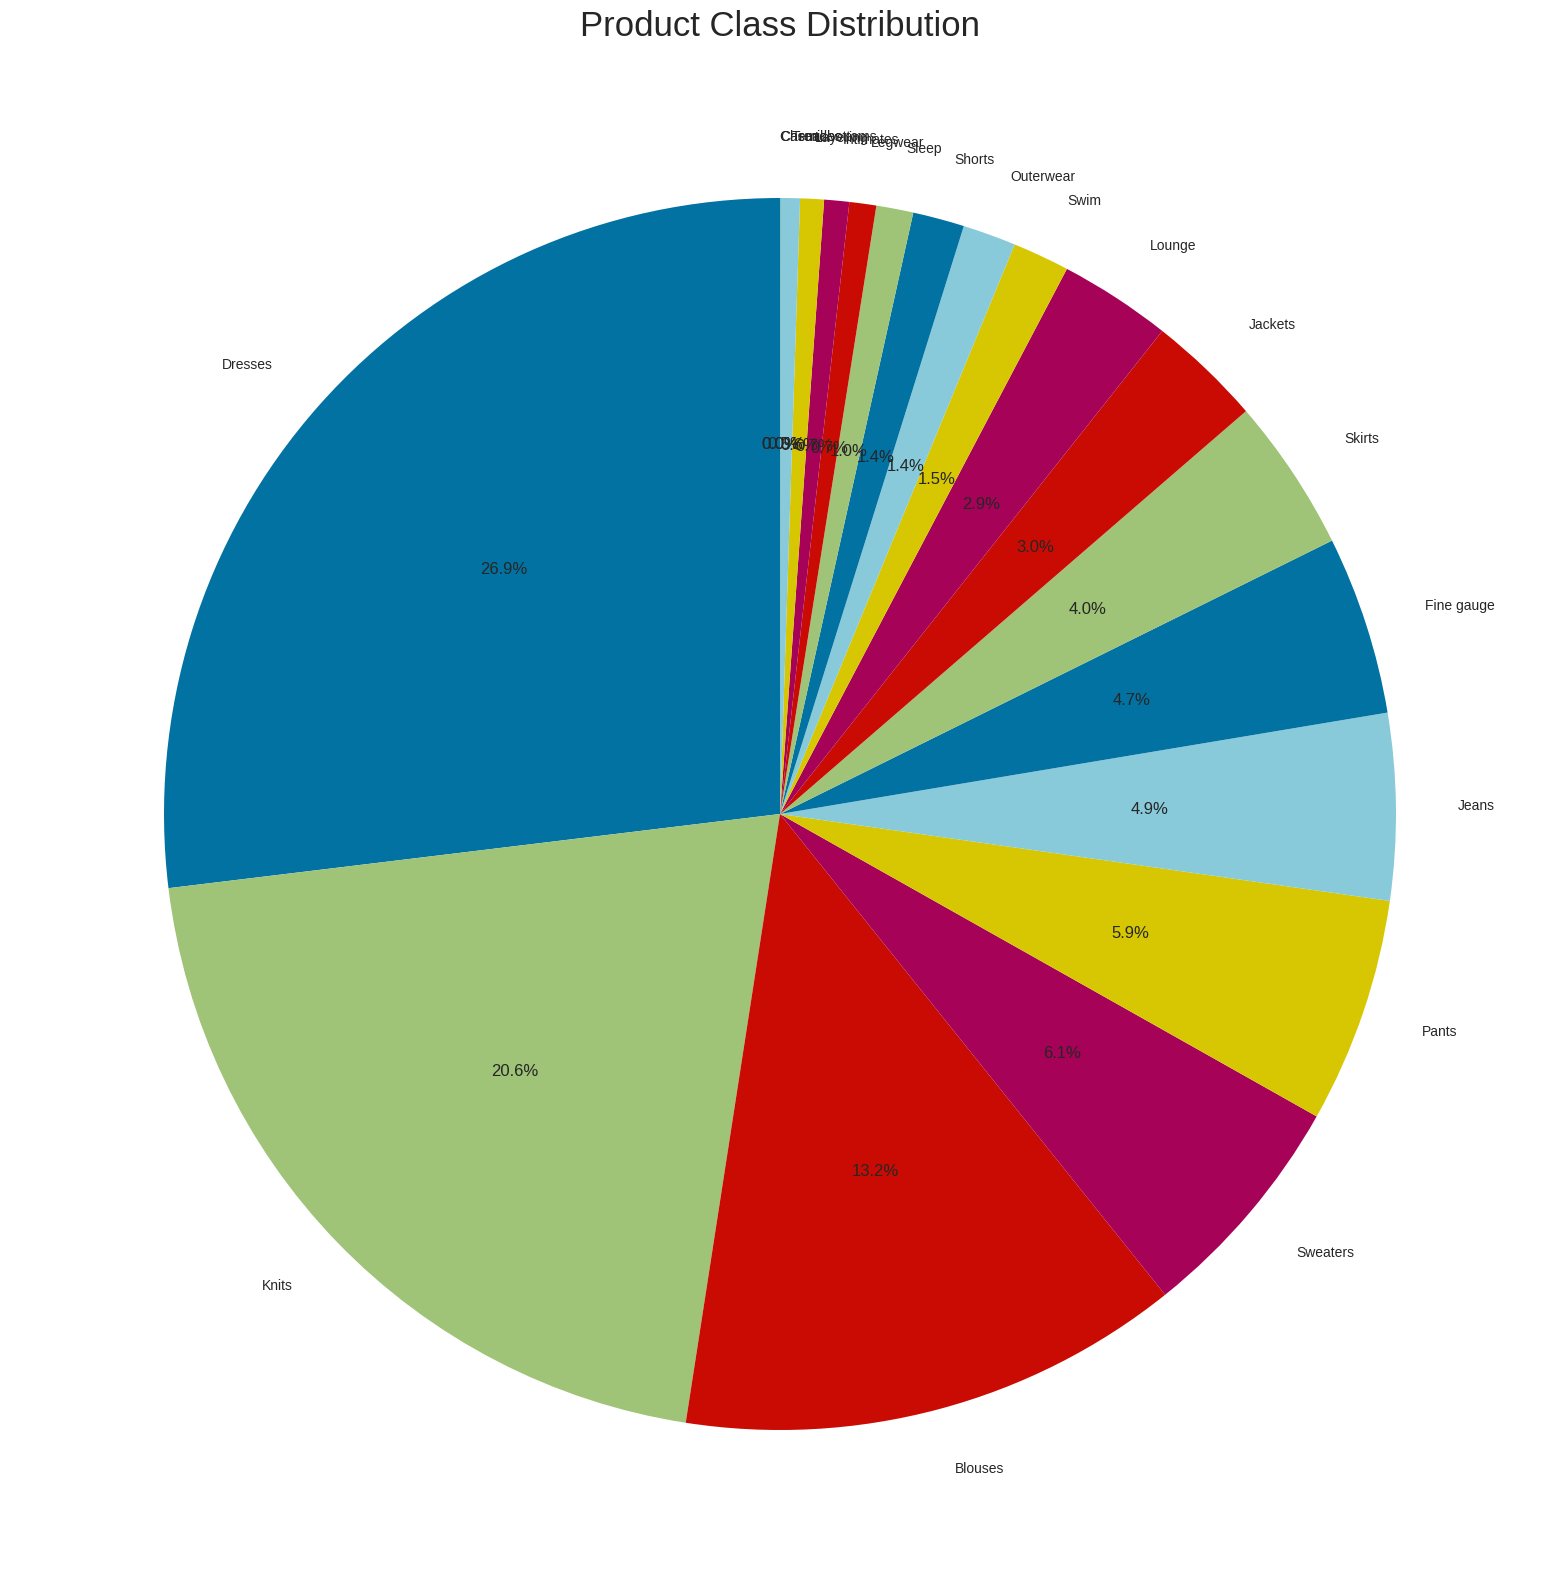

In [63]:
plt.figure(figsize=(20, 20))
plt.title('Product Class Distribution', fontsize=25)
labels = df["class_name"].value_counts().index
sizes = df["class_name"].value_counts().values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)


plt.gca().set_prop_cycle('color', plt.cm.tab10.colors)


plt.show()

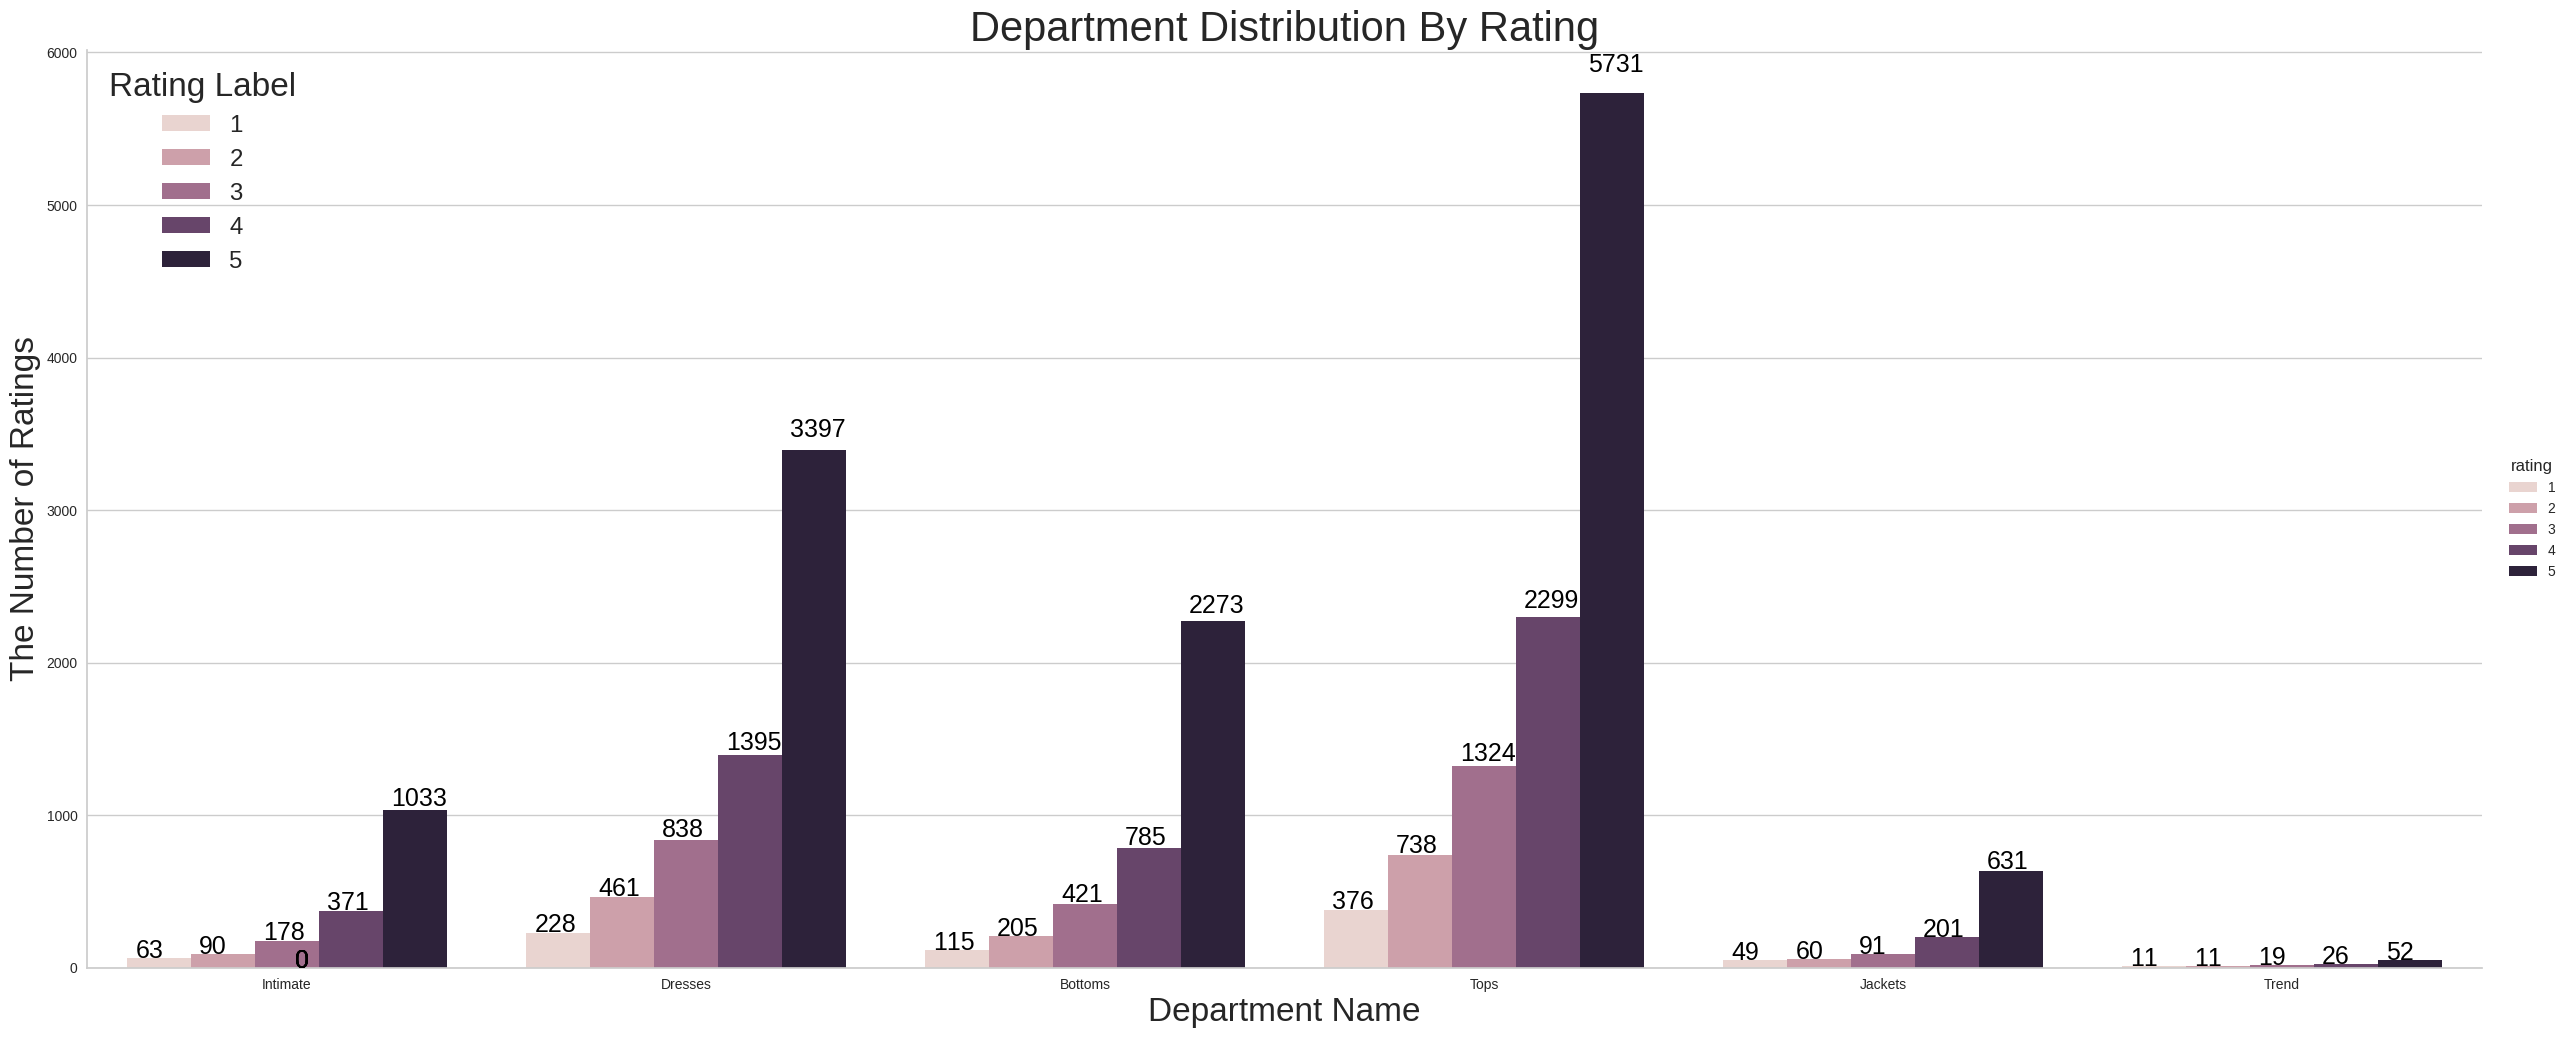

In [64]:
g = sns.catplot(data = df, x ="department_name", hue = "rating", kind='count', height=10, aspect=2.5)

sns.set_context(rc = {'figure.figsize':(30, 12)})
plt.title('Department Distribution By Rating', fontsize=30)
plt.xlabel("Department Name", fontsize=24)
plt.ylabel("The Number of Ratings", fontsize=24)
plt.legend(title='Rating Label', loc='upper left', labels=['1', '2', '3', '4', '5'], fontsize='x-large', title_fontsize='24')

ax = g.facet_axis(0, 0)
for p in ax.patches:
    ax.text(p.get_x() + 0.02,
            p.get_height() * 1.025,
            '{0:.0f}'.format(p.get_height()),
            color='black', rotation='horizontal', fontsize = 18)

In [65]:

#Calculate word frequencies
FreqOfWords = df['review_text'].str.split(expand=True).stack().value_counts()
FreqOfWords_top200 = FreqOfWords[:200]


fig = px.treemap(FreqOfWords_top200, path=[FreqOfWords_top200.index], values=FreqOfWords_top200, width=1000, height=600)
fig.update_layout(title_text='Top 200 Frequent Words in the Dataset (Before Cleaning)',
                  title_x=0.5, title_font=dict(size=20))
fig.update_traces(textinfo="label+value")


pio.renderers.default = 'colab'


fig.show()

### Creating categorical and numerical sets for the examination of crosstab information.

In [66]:
df_cat = df[['division_name', 'department_name', 'class_name', "recommended_ind"]]
df_cat["recommended_ind"] = df_cat["recommended_ind"].apply(lambda x: "Recommended" if x>=1 else "Not Recommended")
df_cat.rename({'division_name': 'Division Name', 'department_name': 'Department Name', 'class_name': 'Class Name', 'recommended_ind': 'Recommendation Indicator'}, axis=1, inplace=True)
df_cat

,Division Name,Department Name,Class Name,Recommendation Indicator
0,Initmates,Intimate,Intimates,Recommended
1,General,Dresses,Dresses,Recommended
2,General,Dresses,Dresses,Not Recommended
3,General Petite,Bottoms,Pants,Recommended
4,General,Tops,Blouses,Recommended
...,...,...,...,...
23481,General Petite,Dresses,Dresses,Recommended
23482,General Petite,Tops,Knits,Recommended
23483,General Petite,Dresses,Dresses,Not Recommended
23484,General,Dresses,Dresses,Recommended


In [67]:
df_num = df[['age', 'rating', 'positive_feedback_count', 'recommended_ind']]
df_num["recommended_ind"] = df_num["recommended_ind"].apply(lambda x: "Recommended" if x>=1 else "Not Recommended")
df_num.rename({'age': 'Age', 'rating': 'Rating', 'positive_feedback_count': 'Positive Feedback', 'recommended_ind': 'Recommendation Indicator'}, axis=1, inplace=True)
df_num

,Age,Rating,Positive Feedback,Recommendation Indicator
0,33,4,0,Recommended
1,34,5,4,Recommended
2,60,3,0,Not Recommended
3,50,5,0,Recommended
4,47,5,6,Recommended
...,...,...,...,...
23481,34,5,0,Recommended
23482,48,3,0,Recommended
23483,31,3,1,Not Recommended
23484,28,3,2,Recommended


In [68]:
for i, col in enumerate(df_cat.columns):
    xtab = pd.crosstab(df_cat[col], df_cat["Recommendation Indicator"], normalize=True)
    print(colored('-'*55, 'red', attrs=['bold']), sep='')
    print(xtab*100)

-------------------------------------------------------
Recommendation Indicator  Not Recommended  Recommended
Division Name                                         
General                             10.81        48.20
General Petite                       6.02        28.57
Initmates                            0.95         5.45
-------------------------------------------------------
Recommendation Indicator  Not Recommended  Recommended
Department Name                                       
Bottoms                              2.41        13.78
Dresses                              5.16        21.76
Intimate                             1.11         6.28
Jackets                              0.72         3.68
Tops                                 8.24        36.35
Trend                                0.13         0.37
-------------------------------------------------------
Recommendation Indicator  Not Recommended  Recommended
Class Name                                            
Blouses

In [69]:
for i, col in enumerate(df_num.columns):
    xtab = pd.crosstab(df_num[col], df_num["Recommendation Indicator"], normalize=True)
    print(colored('-'*55, 'red', attrs=['bold']), sep='')
    print(xtab*100)

-------------------------------------------------------
Recommendation Indicator  Not Recommended  Recommended
Age                                                   
18                                   0.00         0.02
19                                   0.02         0.15
20                                   0.06         0.40
21                                   0.04         0.40
22                                   0.06         0.56
23                                   0.16         0.89
24                                   0.17         0.87
25                                   0.27         1.14
26                                   0.33         1.47
27                                   0.25         1.21
28                                   0.44         1.38
29                                   0.48         1.71
30                                   0.36         1.37
31                                   0.52         1.90
32                                   0.45         2.24
33       

### Most Categorized Dresses

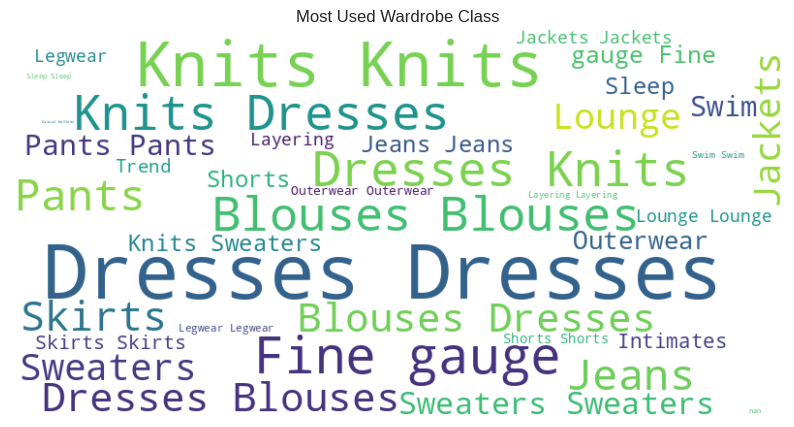

In [70]:
text = ' '.join(df['class_name'].astype(str))


wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Used Wardrobe Class')
plt.axis('off')
plt.show()

# Feature Selection

In [71]:
df.columns

Index(['clothing_id', 'age', 'title', 'review_text', 'rating',
       'recommended_ind', 'positive_feedback_count', 'division_name',
       'department_name', 'class_name'],
      dtype='object')

In [72]:
df.drop(['clothing_id', 'age', 'title', 'rating',
       'positive_feedback_count', 'division_name',
       'department_name', 'class_name'], axis=1, inplace=True)

In [73]:
df.head(5)

,review_text,recommended_ind
0,Absolutely wonderful - silky and sexy and comfortable,1
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",1
2,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,0
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",1
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,1


## Detecting & Handling With Missing Values

In [74]:
df['review_text'].isnull().value_counts()

review_text
False    22641
True       845
Name: count, dtype: int64

In [75]:
df['recommended_ind'].isnull().value_counts()

recommended_ind
False    23486
Name: count, dtype: int64

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_text      22641 non-null  object
 1   recommended_ind  23486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 367.1+ KB


In [77]:
df = df.dropna()

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 0 to 23485
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_text      22641 non-null  object
 1   recommended_ind  22641 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 530.6+ KB


In [79]:
df['review_text'].isnull().value_counts()

review_text
False    22641
Name: count, dtype: int64

In [80]:
df['recommended_ind'].isnull().value_counts()

recommended_ind
False    22641
Name: count, dtype: int64

In [81]:
missing_values(df)

,Missing_Number,Missing_Percent


In [82]:
df["review_text"].str.isspace().sum()

0

In [83]:
df[df["review_text"].str.isspace() == True].index

Index([], dtype='int64')

# Text Mining

## Tokenization, Noise Removal & Lexicon Normalization

In [84]:
def cleaning_fsa(data):

    import re

    #1. Remove Puncs
    # \w typically matches [A-Za-z0-9_]
    text = re.sub('[^\w\s]','', data)

    #2. Tokenize
    text_tokens = word_tokenize(text.lower())

    #3. Remove numbers
    tokens_without_punc = [w for w in text_tokens if w.isalpha()]

    #4. Removing Stopwords
    tokens_without_sw = [t for t in tokens_without_punc if t not in stop_words]

    #5. lemma
    text_cleaned = [WordNetLemmatizer().lemmatize(t) for t in tokens_without_sw]

    #joining
    return " ".join(text_cleaned)

In [85]:
stop_words = stopwords.words('english')

In [86]:
text = cleaning_fsa(str(df["review_text"]))
text

'absolutely wonderful silky sexy comfortable love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length high hope dress really wanted work initially ordered petite small usual size found outrageously small small fact co love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment shirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt happy snag dress great price easy slip flattering cut color combo reminds maternity clothes soft stretchy shiny material cut flattering drape nicely found one button close front looked awkward nice long sleevesnnot bu fit well top see never would worked im glad able try store didnt order online different fabric would bought dress wedding summer cute unfortunately fit isnt perfect medium fit waist perfectly way long big bust sh dress lovely platinum feminine fit perfectly easy wear comfy highly recommend name length d

In [87]:
df["review_text"] = df["review_text"].apply(cleaning_fsa)
df["review_text"].head()

0                                                                                                                                                                absolutely wonderful silky sexy comfortable
1                       love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite
2    high hope dress really wanted work initially ordered petite small usual size found outrageously small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom...
3                                                                                                                   love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment
4                                                                                             shirt flattering due adjustable front tie perfect length wear legging sleeveless pair 

In [88]:
df.head(5)

,review_text,recommended_ind
0,absolutely wonderful silky sexy comfortable,1
1,love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite,1
2,high hope dress really wanted work initially ordered petite small usual size found outrageously small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom...,0
3,love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment,1
4,shirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt,1


## Handling Rare Words

In [89]:
" ".join(df["review_text"]).split()

['absolutely',
 'wonderful',
 'silky',
 'sexy',
 'comfortable',
 'love',
 'dress',
 'sooo',
 'pretty',
 'happened',
 'find',
 'store',
 'im',
 'glad',
 'bc',
 'never',
 'would',
 'ordered',
 'online',
 'bc',
 'petite',
 'bought',
 'petite',
 'love',
 'length',
 'hit',
 'little',
 'knee',
 'would',
 'definitely',
 'true',
 'midi',
 'someone',
 'truly',
 'petite',
 'high',
 'hope',
 'dress',
 'really',
 'wanted',
 'work',
 'initially',
 'ordered',
 'petite',
 'small',
 'usual',
 'size',
 'found',
 'outrageously',
 'small',
 'small',
 'fact',
 'could',
 'zip',
 'reordered',
 'petite',
 'medium',
 'ok',
 'overall',
 'top',
 'half',
 'comfortable',
 'fit',
 'nicely',
 'bottom',
 'half',
 'tight',
 'layer',
 'several',
 'somewhat',
 'cheap',
 'net',
 'layer',
 'imo',
 'major',
 'design',
 'flaw',
 'net',
 'layer',
 'sewn',
 'directly',
 'zipper',
 'c',
 'love',
 'love',
 'love',
 'jumpsuit',
 'fun',
 'flirty',
 'fabulous',
 'every',
 'time',
 'wear',
 'get',
 'nothing',
 'great',
 'complimen

In [90]:
word_values = pd.Series(" ".join(df["review_text"]).split()).value_counts()
word_values

dress       11319
fit         10091
size         9349
love         8968
top          8256
            ...  
takeout         1
teenybop        1
hugely          1
shirred         1
platinum        1
Name: count, Length: 16758, dtype: int64

In [91]:
rare_words = word_values[word_values <= 2]
rare_words

wristforearm    2
magnolia        2
smalltight      2
urban           2
underrated      2
               ..
takeout         1
teenybop        1
hugely          1
shirred         1
platinum        1
Name: count, Length: 10935, dtype: int64

In [92]:
rare_words.value_counts()

count
1    9058
2    1877
Name: count, dtype: int64

In [93]:
len(rare_words)

10935

In [94]:
rare_words.index

Index(['wristforearm', 'magnolia', 'smalltight', 'urban', 'underrated',
       'henleys', 'greenyellow', 'outrageous', 'blueteal', 'status',
       ...
       'quaiity', 'befo', 'slam', 'brokenin', 'accomadate', 'takeout',
       'teenybop', 'hugely', 'shirred', 'platinum'],
      dtype='object', length=10935)

In [95]:
df["review_text"] = df["review_text"].apply(lambda x: " ".join([i for i in x.split() if i not in rare_words.index]))
df["review_text"].head()


0                                                                                                                                                                absolutely wonderful silky sexy comfortable
1                       love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite
2    high hope dress really wanted work initially ordered petite small usual size found small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight l...
3                                                                                                                   love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment
4                                                                                             shirt flattering due adjustable front tie perfect length wear legging sleeveless pair 

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 0 to 23485
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_text      22641 non-null  object
 1   recommended_ind  22641 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 530.6+ KB


In [97]:
df.head(5)

,review_text,recommended_ind
0,absolutely wonderful silky sexy comfortable,1
1,love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite,1
2,high hope dress really wanted work initially ordered petite small usual size found small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight l...,0
3,love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment,1
4,shirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt,1


# Word Cloud- Frequently Used Words

## Detecting Positive & Negative Reviews

In [98]:
df.columns

Index(['review_text', 'recommended_ind'], dtype='object')

In [99]:
df[df["recommended_ind"] == 0]

,review_text,recommended_ind
2,high hope dress really wanted work initially ordered petite small usual size found small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight l...,0
5,love tracy reese dress one petite foot tall usually wear brand dress pretty package lot dress skirt long full overwhelmed small frame stranger alteration shortening skirt would take away embellish...,0
10,dress run small esp zipper area run ordered sp typically fit tight material top look feel cheap even pulling cause rip fabric pretty disappointed going christmas dress year needle say going back,0
22,first pullover styling side zipper wouldnt purchased knew side zipper large bust side zipper next impossible second tulle feel look cheap slip awkward tight shape underneath look like described sa...,0
25,loved material didnt really look long dress purchased large medium im atleast material foot gap front much wider look felt like dress fell flat returned im usually large med fit better jean,0
...,...,...
23449,tried color really pretty fun want pair pant looked awful muscular thigh dont think cut falttering also comfortable looked crotch seemed little low though pant correct size,0
23450,wanted love jacket soft great color unfortunately light weight almost like shirt fabric nice heft fabric though nice length accept sleeve short small right size looking something slightly warmer l...,0
23460,purchased good price typically love maeve winwin fabric thin slinky unfortunate way made finding appropriate undergarment difficult add slip helped figured since im losing weight would look better...,0
23478,surprised positive review product terrible cut weird place make look wide skirt also like picture darker heavier material isnt great return,0


In [100]:
df[df["recommended_ind"] == 1]

,review_text,recommended_ind
0,absolutely wonderful silky sexy comfortable,1
1,love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite,1
3,love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment,1
4,shirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt,1
6,basket hte last see would look like person store pick went teh color pale hte color really gorgeous turn trying little baggy hte x hte size bummer petite decided though said everything pant skirt ...,1
...,...,...
23479,wasnt sure ordering skirt couldnt see person first im glad skirt design well made doesnt look feel cheap color isnt red worked pale skin better anticipated wore daughter dance production tall boot...,1
23481,happy snag dress great price easy slip flattering cut color combo,1
23482,reminds maternity clothes soft stretchy shiny material cut flattering drape nicely found one button close front looked awkward nice long sleeve maybe others ok,1
23484,bought dress wedding summer cute unfortunately fit isnt perfect medium fit waist perfectly way long big bust shoulder wanted spend money could get tailored felt like might worth side note dress de...,1


In [101]:
df["recommended_ind"].value_counts()

recommended_ind
1    18540
0     4101
Name: count, dtype: int64

## Gethering Negative & Positive Words

In [102]:
" ".join(df["review_text"]).split()

['absolutely',
 'wonderful',
 'silky',
 'sexy',
 'comfortable',
 'love',
 'dress',
 'sooo',
 'pretty',
 'happened',
 'find',
 'store',
 'im',
 'glad',
 'bc',
 'never',
 'would',
 'ordered',
 'online',
 'bc',
 'petite',
 'bought',
 'petite',
 'love',
 'length',
 'hit',
 'little',
 'knee',
 'would',
 'definitely',
 'true',
 'midi',
 'someone',
 'truly',
 'petite',
 'high',
 'hope',
 'dress',
 'really',
 'wanted',
 'work',
 'initially',
 'ordered',
 'petite',
 'small',
 'usual',
 'size',
 'found',
 'small',
 'small',
 'fact',
 'could',
 'zip',
 'reordered',
 'petite',
 'medium',
 'ok',
 'overall',
 'top',
 'half',
 'comfortable',
 'fit',
 'nicely',
 'bottom',
 'half',
 'tight',
 'layer',
 'several',
 'somewhat',
 'cheap',
 'net',
 'layer',
 'imo',
 'major',
 'design',
 'flaw',
 'net',
 'layer',
 'sewn',
 'directly',
 'zipper',
 'c',
 'love',
 'love',
 'love',
 'jumpsuit',
 'fun',
 'flirty',
 'fabulous',
 'every',
 'time',
 'wear',
 'get',
 'nothing',
 'great',
 'compliment',
 'shirt',
 'f

In [103]:
neg_words = " ".join(df[df["recommended_ind"] == 0].review_text).split()
neg_words

['high',
 'hope',
 'dress',
 'really',
 'wanted',
 'work',
 'initially',
 'ordered',
 'petite',
 'small',
 'usual',
 'size',
 'found',
 'small',
 'small',
 'fact',
 'could',
 'zip',
 'reordered',
 'petite',
 'medium',
 'ok',
 'overall',
 'top',
 'half',
 'comfortable',
 'fit',
 'nicely',
 'bottom',
 'half',
 'tight',
 'layer',
 'several',
 'somewhat',
 'cheap',
 'net',
 'layer',
 'imo',
 'major',
 'design',
 'flaw',
 'net',
 'layer',
 'sewn',
 'directly',
 'zipper',
 'c',
 'love',
 'tracy',
 'reese',
 'dress',
 'one',
 'petite',
 'foot',
 'tall',
 'usually',
 'wear',
 'brand',
 'dress',
 'pretty',
 'package',
 'lot',
 'dress',
 'skirt',
 'long',
 'full',
 'overwhelmed',
 'small',
 'frame',
 'stranger',
 'alteration',
 'shortening',
 'skirt',
 'would',
 'take',
 'away',
 'embellishment',
 'garment',
 'love',
 'color',
 'idea',
 'style',
 'work',
 'returned',
 'dress',
 'dress',
 'run',
 'small',
 'esp',
 'zipper',
 'area',
 'run',
 'ordered',
 'sp',
 'typically',
 'fit',
 'tight',
 'mat

In [104]:
pos_words =" ".join(df[df["recommended_ind"] == 1].review_text).split()
pos_words

['absolutely',
 'wonderful',
 'silky',
 'sexy',
 'comfortable',
 'love',
 'dress',
 'sooo',
 'pretty',
 'happened',
 'find',
 'store',
 'im',
 'glad',
 'bc',
 'never',
 'would',
 'ordered',
 'online',
 'bc',
 'petite',
 'bought',
 'petite',
 'love',
 'length',
 'hit',
 'little',
 'knee',
 'would',
 'definitely',
 'true',
 'midi',
 'someone',
 'truly',
 'petite',
 'love',
 'love',
 'love',
 'jumpsuit',
 'fun',
 'flirty',
 'fabulous',
 'every',
 'time',
 'wear',
 'get',
 'nothing',
 'great',
 'compliment',
 'shirt',
 'flattering',
 'due',
 'adjustable',
 'front',
 'tie',
 'perfect',
 'length',
 'wear',
 'legging',
 'sleeveless',
 'pair',
 'well',
 'cardigan',
 'love',
 'shirt',
 'basket',
 'hte',
 'last',
 'see',
 'would',
 'look',
 'like',
 'person',
 'store',
 'pick',
 'went',
 'teh',
 'color',
 'pale',
 'hte',
 'color',
 'really',
 'gorgeous',
 'turn',
 'trying',
 'little',
 'baggy',
 'hte',
 'x',
 'hte',
 'size',
 'bummer',
 'petite',
 'decided',
 'though',
 'said',
 'everything',
 '

## Word Cloud

In [105]:
review_text = df["review_text"]

In [106]:
all_words = " ".join(review_text)

In [107]:
all_words[:100]

'absolutely wonderful silky sexy comfortable love dress sooo pretty happened find store im glad bc ne'

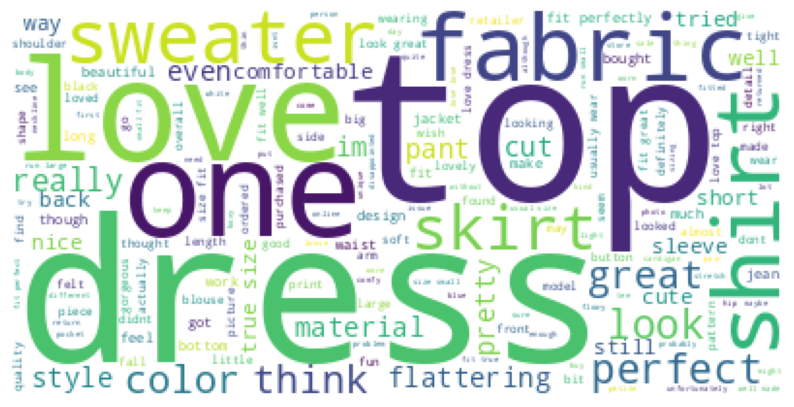

In [108]:
from wordcloud import WordCloud

wordcloud = WordCloud(background_color="white", max_words =250).generate(all_words)

plt.figure(figsize = (10, 10))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

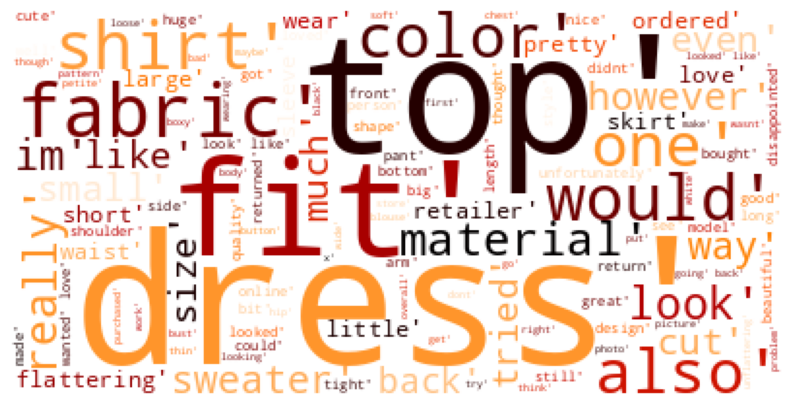

In [109]:
wordcloud = WordCloud(background_color="white", max_words =250, colormap='gist_heat').generate(str(neg_words))

plt.figure(figsize = (10, 10))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

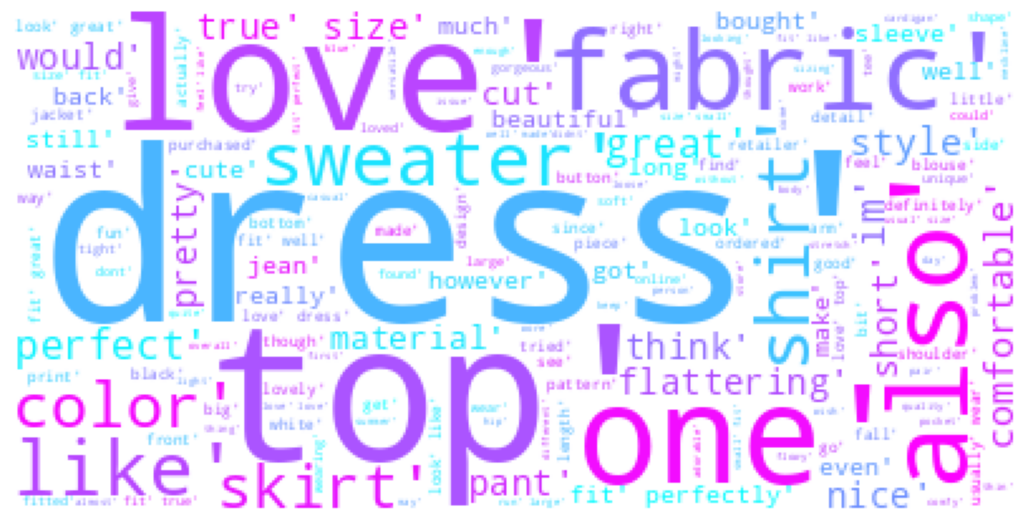

In [110]:
wordcloud = WordCloud(background_color="white", max_words =250, colormap='cool').generate(str(pos_words))

plt.figure(figsize = (13, 13))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Implementing Models

## Model Training

In [135]:
df.head()

,review_text,recommended_ind
0,absolutely wonderful silky sexy comfortable,1
1,love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hit little knee would definitely true midi someone truly petite,1
2,high hope dress really wanted work initially ordered petite small usual size found small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight l...,0
3,love love love jumpsuit fun flirty fabulous every time wear get nothing great compliment,1
4,shirt flattering due adjustable front tie perfect length wear legging sleeveless pair well cardigan love shirt,1


### Train & Test

In [136]:
X = df["review_text"]
y= df["recommended_ind"]

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=101)

## Vectorization

### Count Vectorization

In [138]:
vectorizer = CountVectorizer()

X_train_count = vectorizer.fit_transform(X_train)
X_test_count = vectorizer.transform(X_test)

In [139]:
type(X_train_count)

scipy.sparse._csr.csr_matrix

In [140]:
X_train_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [141]:
vectorizer.get_feature_names_out()

array(['aa', 'ab', 'abby', ..., 'zipping', 'zone', 'zoom'], dtype=object)

In [142]:
pd.DataFrame(X_train_count.toarray(), columns = vectorizer.get_feature_names_out())

,aa,ab,abby,abdomen,ability,able,abo,abovetheknee,absolute,absolutely,absolutley,abstract,absurd,abt,abundance,ac,accent,accented,accentuate,accentuated,accentuates,accentuating,accept,acceptable,access,accessorize,accessorized,accessorizing,accessory,accident,accidental,accidentally,accommodate,accommodates,accommodating,accomodate,according,accordingly,account,accurate,accurately,achieve,across,acrylic,act,action,active,activewear,activity,actual,actuality,actually,ad,ada,add,added,addicted,adding,addition,additional,additionally,address,adequate,adequately,adjust,adjustable,adjusted,adjusting,adjustment,admire,admired,admiring,admit,admittedly,adn,ador,adorable,adore,adored,adult,advantage,advertised,advice,advise,advised,aesthetic,aesthetically,affair,affect,afford,affordable,afraid,afternoon,afterward,afterwards,ag,age,ageappropriate,aged,ago,...,word,wore,work,workable,workappropriate,worked,working,workmanship,workout,workplace,workthe,world,worn,worried,worry,worrying,worse,worst,worth,worthwhile,worthy,wou,woul,would,wouldnt,wouldve,wound,woven,wow,wowed,wrap,wrapped,wrapping,wri,wring,wrinkle,wrinkled,wrinkling,wrinkly,wrist,write,writing,written,wrong,wrote,xl,xlarge,xmas,xsi,xsmall,xsmallsmall,xsp,xspetite,xssm,xtra,xx,xxl,xxsmall,xxsp,yarn,yay,yeah,year,yearold,yearround,yellow,yellowish,yelloworange,yellowy,yep,yes,yesterday,yet,yikes,yo,yoga,yoke,york,youd,youll,young,younger,youre,youthful,youve,yr,yuck,yucky,yummy,zag,zero,zig,zigzag,zip,zipped,zipper,zippered,zipping,zone,zoom
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

### TF-IDF Vectorization

In [143]:
tf_idf_vectorizer = TfidfVectorizer()

X_train_tf_idf = tf_idf_vectorizer.fit_transform(X_train)
X_test_tf_idf = tf_idf_vectorizer.transform(X_test)

In [144]:
X_train_tf_idf.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [145]:
pd.DataFrame(X_train_tf_idf.toarray(), columns = tf_idf_vectorizer.get_feature_names_out())

,aa,ab,abby,abdomen,ability,able,abo,abovetheknee,absolute,absolutely,absolutley,abstract,absurd,abt,abundance,ac,accent,accented,accentuate,accentuated,accentuates,accentuating,accept,acceptable,access,accessorize,accessorized,accessorizing,accessory,accident,accidental,accidentally,accommodate,accommodates,accommodating,accomodate,according,accordingly,account,accurate,accurately,achieve,across,acrylic,act,action,active,activewear,activity,actual,actuality,actually,ad,ada,add,added,addicted,adding,addition,additional,additionally,address,adequate,adequately,adjust,adjustable,adjusted,adjusting,adjustment,admire,admired,admiring,admit,admittedly,adn,ador,adorable,adore,adored,adult,advantage,advertised,advice,advise,advised,aesthetic,aesthetically,affair,affect,afford,affordable,afraid,afternoon,afterward,afterwards,ag,age,ageappropriate,aged,ago,...,word,wore,work,workable,workappropriate,worked,working,workmanship,workout,workplace,workthe,world,worn,worried,worry,worrying,worse,worst,worth,worthwhile,worthy,wou,woul,would,wouldnt,wouldve,wound,woven,wow,wowed,wrap,wrapped,wrapping,wri,wring,wrinkle,wrinkled,wrinkling,wrinkly,wrist,write,writing,written,wrong,wrote,xl,xlarge,xmas,xsi,xsmall,xsmallsmall,xsp,xspetite,xssm,xtra,xx,xxl,xxsmall,xxsp,yarn,yay,yeah,year,yearold,yearround,yellow,yellowish,yelloworange,yellowy,yep,yes,yesterday,yet,yikes,yo,yoga,yoke,york,youd,youll,young,younger,youre,youthful,youve,yr,yuck,yucky,yummy,zag,zero,zig,zigzag,zip,zipped,zipper,zippered,zipping,zone,zoom
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0

### Function for comparing models at the end.

In [146]:
def eval(model, X_train, X_test):
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    print("Test_Set")
    print(classification_report(y_test, y_pred))
    print("Train_Set")
    print(classification_report(y_train, y_pred_train))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.show()

# Machine Learning Model Implementation

## Logistic Regression

### Logistic Regression Using Count Vectorizor

In [147]:
log = LogisticRegression(C =0.6, max_iter=1000, class_weight= "balanced", random_state=101)
log.fit(X_train_count,y_train)

LogisticRegression(C=0.6, class_weight='balanced', max_iter=1000,
                   random_state=101)

Scores
Test_Set
              precision    recall  f1-score   support

           0       0.61      0.80      0.69       820
           1       0.95      0.89      0.92      3709

    accuracy                           0.87      4529
   macro avg       0.78      0.84      0.81      4529
weighted avg       0.89      0.87      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       0.72      0.96      0.82      3281
           1       0.99      0.92      0.95     14831

    accuracy                           0.92     18112
   macro avg       0.85      0.94      0.89     18112
weighted avg       0.94      0.92      0.93     18112



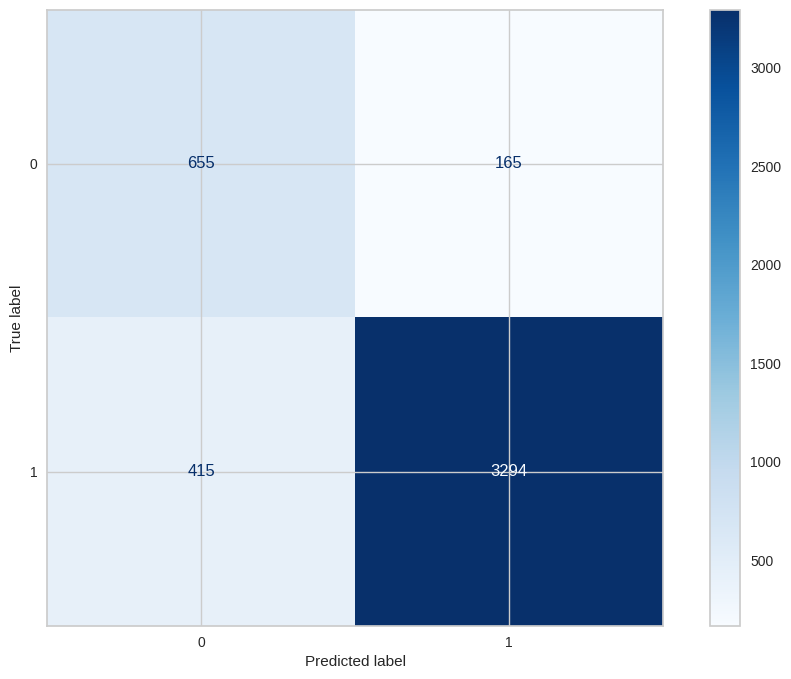

In [148]:
print("Scores")

eval(log, X_train_count, X_test_count)

In [149]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score

custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = LogisticRegression(C =0.6, max_iter=1000, class_weight= "balanced", random_state=101)
    scores = cross_val_score(model, X_train_count, y_train, cv = 10, scoring = j).mean()
    if i == "recall-1":
        log_count_rec = scores
    elif i == "f1-1":
        log_count_f1 = scores
    elif i == "accuracy":
        log_count_acc = scores
    print(f" {i:20} score for count vectorizor : {scores}\n")

 accuracy             score for count vectorizor : 0.8663865231239555

 precision-0          score for count vectorizor : 0.6004732142128997

 recall-0             score for count vectorizor : 0.7860432574690488

 f1-0                 score for count vectorizor : 0.6806600348422279

 precision-1          score for count vectorizor : 0.9492144073093828

 recall-1             score for count vectorizor : 0.8841613760989325

 f1-1                 score for count vectorizor : 0.9155098938458213



### Logistic Regression Using TF-IDF Vectorizer

In [150]:
log = LogisticRegression(C=0.1, max_iter=1000, random_state=101, class_weight="balanced")

log.fit(X_train_tf_idf,y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=101)

Scores
Test_Set
              precision    recall  f1-score   support

           0       0.55      0.86      0.67       820
           1       0.97      0.85      0.90      3709

    accuracy                           0.85      4529
   macro avg       0.76      0.85      0.79      4529
weighted avg       0.89      0.85      0.86      4529

Train_Set
              precision    recall  f1-score   support

           0       0.57      0.89      0.69      3281
           1       0.97      0.85      0.91     14831

    accuracy                           0.86     18112
   macro avg       0.77      0.87      0.80     18112
weighted avg       0.90      0.86      0.87     18112



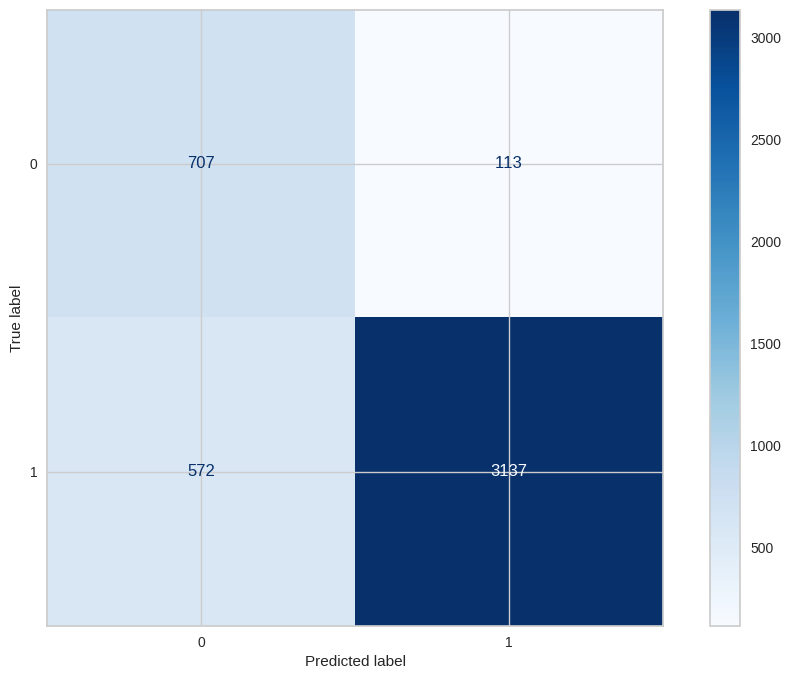

In [151]:
print("Scores")

eval(log, X_train_tf_idf, X_test_tf_idf)

In [152]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    LogisticRegression(C=0.1, max_iter=1000, random_state=101, class_weight="balanced")
    scores = cross_val_score(model, X_train_tf_idf, y_train, cv = 10, scoring = j).mean()
    if i == "recall-1":
        log_tfidf_rec = scores
    elif i == "f1-1":
        log_tfidf_f1 = scores
    elif i == "accuracy":
        log_tfidf_acc = scores
    print(f" {i:20} score for tf-idf vectorizor : {scores}\n")


 accuracy             score for tf-idf vectorizor : 0.860257465110808

 precision-0          score for tf-idf vectorizor : 0.5784925099903739

 recall-0             score for tf-idf vectorizor : 0.8463887241456002

 f1-0                 score for tf-idf vectorizor : 0.6870476202382443

 precision-1          score for tf-idf vectorizor : 0.9621600784762144

 recall-1             score for tf-idf vectorizor : 0.8633260510402712

 f1-1                 score for tf-idf vectorizor : 0.9100295215782153



## Naive Bayes

### Naive Bayes Using Count vectorization

In [153]:
nb = MultinomialNB()
nb.fit(X_train_count, y_train)

MultinomialNB()

NB MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       820
           1       0.94      0.92      0.93      3709

    accuracy                           0.89      4529
   macro avg       0.80      0.83      0.82      4529
weighted avg       0.89      0.89      0.89      4529

Train_Set
              precision    recall  f1-score   support

           0       0.70      0.81      0.75      3281
           1       0.96      0.92      0.94     14831

    accuracy                           0.90     18112
   macro avg       0.83      0.87      0.85     18112
weighted avg       0.91      0.90      0.91     18112



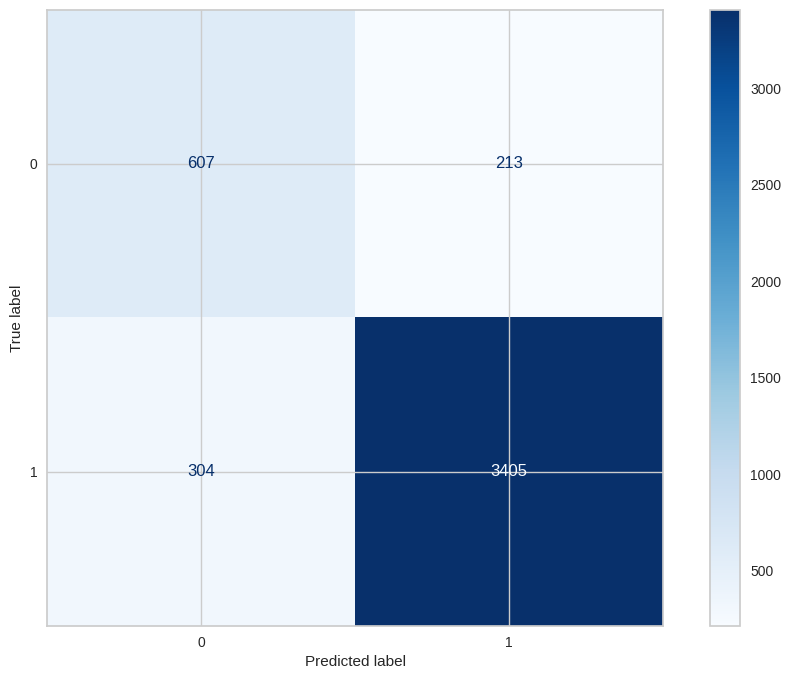

In [154]:
print("NB MODEL")

eval(nb, X_train_count, X_test_count)

In [155]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = MultinomialNB()
    scores = cross_val_score(model, X_train_count, y_train, cv = 10, scoring = j).mean()
    if i == "recall-1":
        nb_count_rec = scores
    elif i == "f1-1":
        nb_count_f1 = scores
    elif i == "accuracy":
        nb_count_acc = scores
    print(f" {i:20} score for count : {scores}\n")

 accuracy             score for count : 0.8826189413968841

 precision-0          score for count : 0.654342059232186

 recall-0             score for count : 0.7476425235376973

 f1-0                 score for count : 0.6975979898377522

 precision-1          score for count : 0.9423871525871338

 recall-1             score for count : 0.9124805295596273

 f1-1                 score for count : 0.927165611564892



### Naive Bayes Using TF-IDF Vectorizer

In [156]:
nb = MultinomialNB()
nb.fit(X_train_tf_idf, y_train)

MultinomialNB()

NB MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.87      0.17      0.28       820
           1       0.84      0.99      0.91      3709

    accuracy                           0.84      4529
   macro avg       0.85      0.58      0.60      4529
weighted avg       0.85      0.84      0.80      4529

Train_Set
              precision    recall  f1-score   support

           0       0.95      0.22      0.36      3281
           1       0.85      1.00      0.92     14831

    accuracy                           0.86     18112
   macro avg       0.90      0.61      0.64     18112
weighted avg       0.87      0.86      0.82     18112



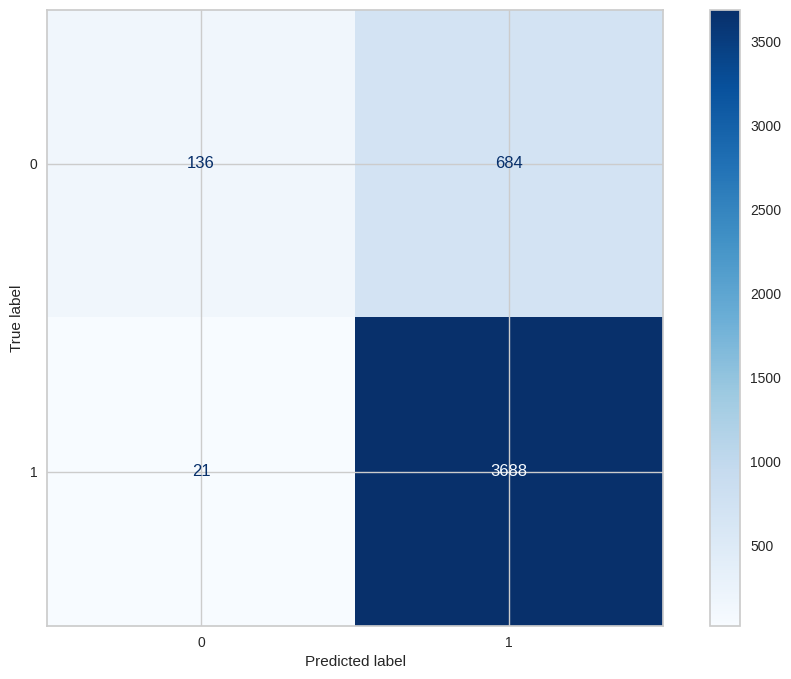

In [157]:
print("NB MODEL")
eval(nb, X_train_tf_idf, X_test_tf_idf)

In [158]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = BernoulliNB()
    scores = cross_val_score(model, X_train_tf_idf, y_train, cv = 10, scoring = j).mean()
    if i == "recall-1":
        nb_tfidf_rec = scores
    elif i == "f1-1":
        nb_tfidf_f1 = scores
    elif i == "accuracy":
        nb_tfidf_acc = scores
    print(f" {i:20} score for tfidf : {scores}\n")

 accuracy             score for tfidf : 0.8766563300312171

 precision-0          score for tfidf : 0.6434549409966672

 recall-0             score for tfidf : 0.7168618874638594

 f1-0                 score for tfidf : 0.6778544585841554

 precision-1          score for tfidf : 0.9357830256315294

 recall-1             score for tfidf : 0.9120087405692183

 f1-1                 score for tfidf : 0.9237148436630017



## Support Vector Machine

### Support Vector Machine Using Count Vectorizor

In [159]:
svc = LinearSVC(C=0.01, class_weight="balanced", random_state=101)
svc.fit(X_train_count,y_train)

LinearSVC(C=0.01, class_weight='balanced', random_state=101)

SVC MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.60      0.84      0.70       820
           1       0.96      0.87      0.92      3709

    accuracy                           0.87      4529
   macro avg       0.78      0.86      0.81      4529
weighted avg       0.90      0.87      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       0.65      0.92      0.76      3281
           1       0.98      0.89      0.93     14831

    accuracy                           0.90     18112
   macro avg       0.82      0.91      0.85     18112
weighted avg       0.92      0.90      0.90     18112



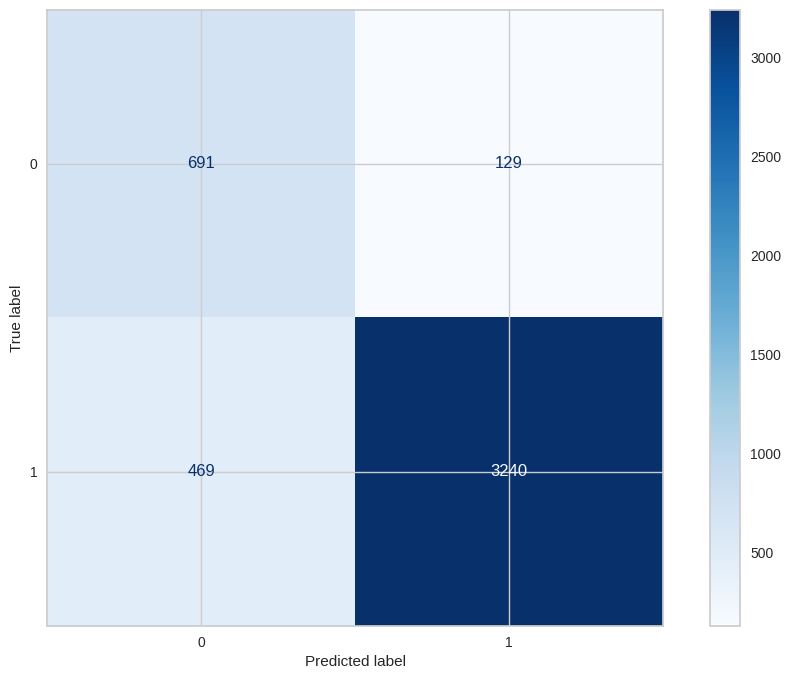

In [160]:
print("SVC MODEL")

eval(svc, X_train_count, X_test_count)

In [161]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = LinearSVC(C=0.01, class_weight="balanced", random_state=101)
    scores = cross_val_score(model, X_train_count, y_train, cv = 10, scoring = j).mean()
    if i == "recall-1":
        svc_count_rec = scores
    elif i == "f1-1":
        svc_count_f1 = scores
    elif i == "accuracy":
        svc_count_acc = scores
    print(f" {i:20} score for count : {scores}\n")

 accuracy             score for count : 0.8649509741181862

 precision-0          score for count : 0.590799663472119

 recall-0             score for count : 0.8305396990140114

 f1-0                 score for count : 0.6902787096697695

 precision-1          score for count : 0.9588319718226306

 recall-1             score for count : 0.872563900304075

 f1-1                 score for count : 0.91363862996587



### Support Vector Machine Using TF-IDF Vectorizer

In [162]:
svc = LinearSVC(C=0.01, class_weight="balanced", random_state=101)

svc.fit(X_train_tf_idf, y_train)

LinearSVC(C=0.01, class_weight='balanced', random_state=101)

SVC MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.55      0.87      0.67       820
           1       0.97      0.84      0.90      3709

    accuracy                           0.85      4529
   macro avg       0.76      0.86      0.79      4529
weighted avg       0.89      0.85      0.86      4529

Train_Set
              precision    recall  f1-score   support

           0       0.57      0.89      0.69      3281
           1       0.97      0.85      0.91     14831

    accuracy                           0.86     18112
   macro avg       0.77      0.87      0.80     18112
weighted avg       0.90      0.86      0.87     18112



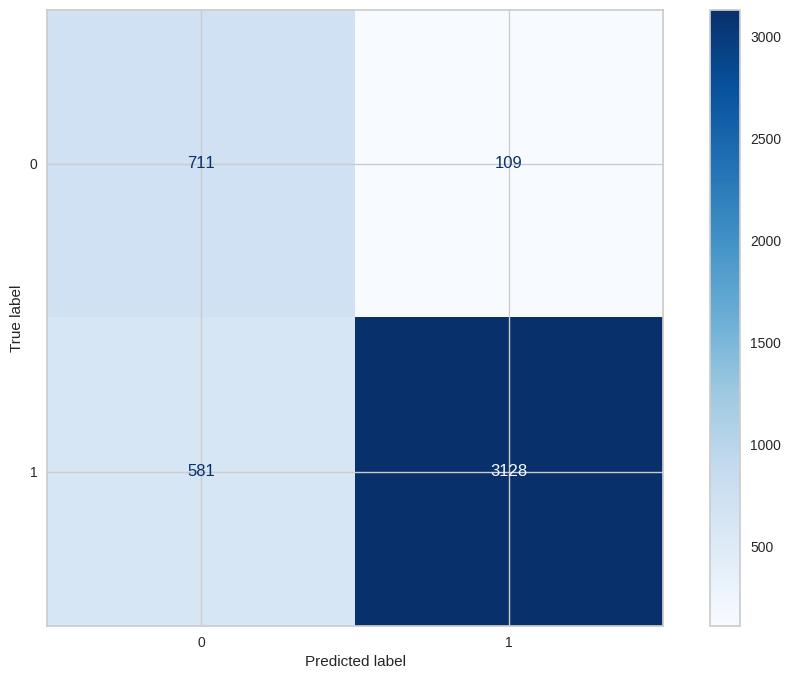

In [163]:
print("SVC MODEL")

eval(svc, X_train_tf_idf, X_test_tf_idf)

In [164]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = LinearSVC(C=0.01, class_weight="balanced", random_state=101)
    scores = cross_val_score(model, X_train_tf_idf, y_train, cv = 10, scoring = j).mean()
    if i == "recall-1":
        svc_tfidf_rec = scores
    elif i == "f1-1":
        svc_tfidf_f1 = scores
    elif i == "accuracy":
        svc_tfidf_acc = scores
    print(f" {i:20} score for tfidf : {scores}\n")

 accuracy             score for tfidf : 0.8430870703074053

 precision-0          score for tfidf : 0.5428195619628373

 recall-0             score for tfidf : 0.8576673585884796

 f1-0                 score for tfidf : 0.6646097767647368

 precision-1          score for tfidf : 0.9639062389709894

 recall-1             score for tfidf : 0.8398624664435934

 f1-1                 score for tfidf : 0.8975617321619218



## Random Forest

### Random Forest Using Count Vectorizer

In [165]:
rf = RandomForestClassifier(200, max_depth = 12, random_state = 42, n_jobs = -1, class_weight="balanced")
rf.fit(X_train_count, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

RF MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.57      0.78      0.66       820
           1       0.95      0.87      0.91      3709

    accuracy                           0.85      4529
   macro avg       0.76      0.83      0.78      4529
weighted avg       0.88      0.85      0.86      4529

Train_Set
              precision    recall  f1-score   support

           0       0.63      0.90      0.74      3281
           1       0.97      0.88      0.93     14831

    accuracy                           0.89     18112
   macro avg       0.80      0.89      0.83     18112
weighted avg       0.91      0.89      0.89     18112



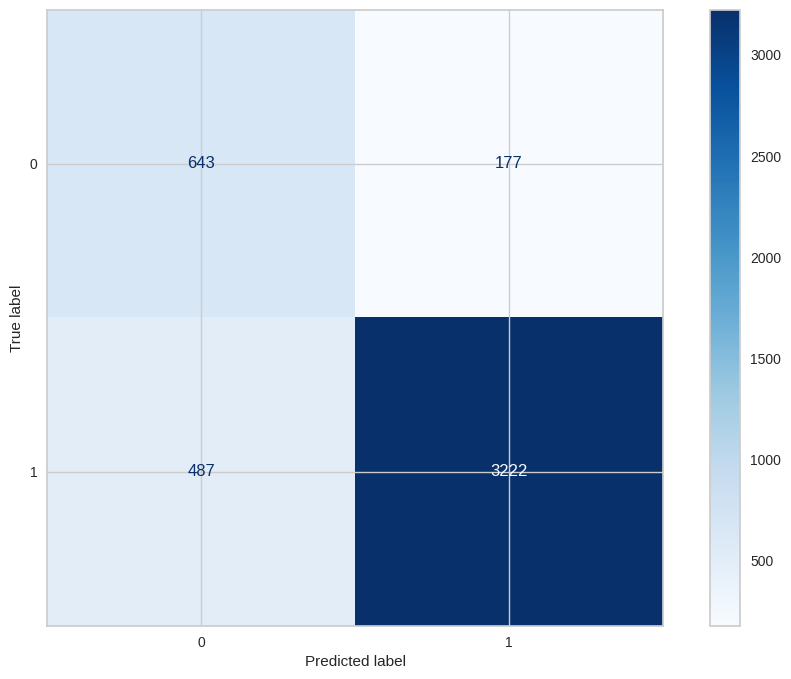

In [166]:
print("RF MODEL")

eval(rf, X_train_count, X_test_count)

In [167]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = RandomForestClassifier(200, max_depth = 12, random_state = 42, n_jobs = -1, class_weight="balanced")
    scores = cross_val_score(model, X_train_count, y_train, cv = 2, scoring = j).mean()
    if i == "recall-1":
        rf_count_rec = scores
    elif i == "f1-1":
        rf_count_f1 = scores
    elif i == "accuracy":
        rf_count_acc= scores
    print(f" {i:20} score for count : {scores}\n")

 accuracy             score for count : 0.8591541519434629

 precision-0          score for count : 0.5875352919590501

 recall-0             score for count : 0.7515968475498283

 f1-0                 score for count : 0.6592351935066783

 precision-1          score for count : 0.9414315184381631

 recall-1             score for count : 0.8829472424260278

 f1-1                 score for count : 0.9112159139936451



### Random Forest Using TF-IDF Vectorizer

In [168]:
rf = RandomForestClassifier(200, max_depth = 10, random_state = 42, n_jobs = -1, class_weight="balanced")

rf.fit(X_train_tf_idf, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

RF MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.53      0.79      0.63       820
           1       0.95      0.84      0.89      3709

    accuracy                           0.83      4529
   macro avg       0.74      0.82      0.76      4529
weighted avg       0.87      0.83      0.85      4529

Train_Set
              precision    recall  f1-score   support

           0       0.59      0.90      0.72      3281
           1       0.97      0.86      0.92     14831

    accuracy                           0.87     18112
   macro avg       0.78      0.88      0.82     18112
weighted avg       0.91      0.87      0.88     18112



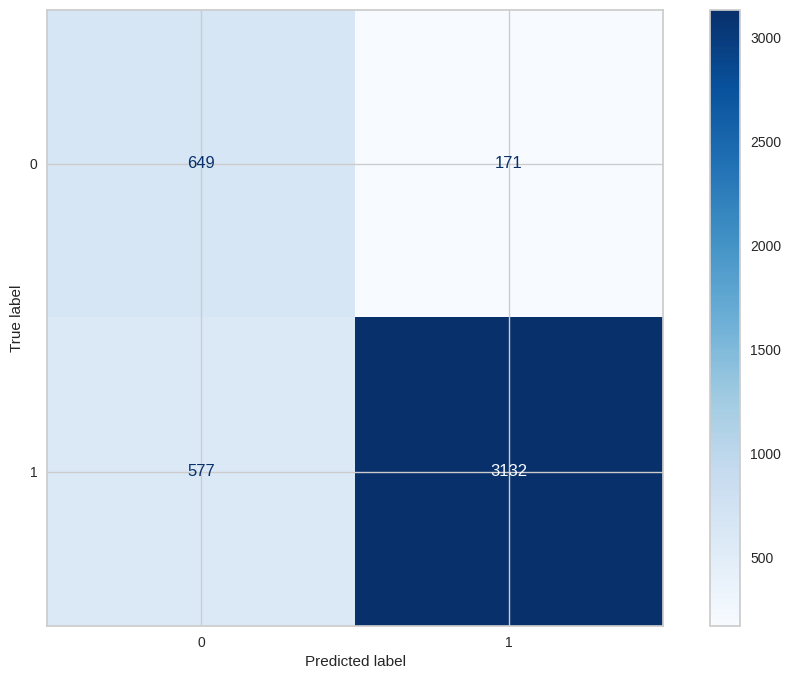

In [169]:
print("RF MODEL")

eval(rf, X_train_tf_idf, X_test_tf_idf)

In [170]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = RandomForestClassifier(200, max_depth = 10, random_state = 42, n_jobs = -1, class_weight="balanced")
    scores = cross_val_score(model, X_train_tf_idf, y_train, cv = 2, scoring = j).mean()
    if i == "recall-1":
        rf_tfidf_rec = scores
    elif i == "f1-1":
        rf_tfidf_f1 = scores
    elif i == "accuracy":
        rf_tfidf_acc = scores
    print(f" {i:20} score for tfidf : {scores}\n")

 accuracy             score for tfidf : 0.8407133392226149

 precision-0          score for tfidf : 0.5435066722724029

 recall-0             score for tfidf : 0.765920542203594

 f1-0                 score for tfidf : 0.6354736621526988

 precision-1          score for tfidf : 0.9430783494860965

 recall-1             score for tfidf : 0.857257657987941

 f1-1                 score for tfidf : 0.8980622479528586



## XGBoost Model

### XGBoost With Count Vectorizer

In [171]:
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_count, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

XGB MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.76      0.55      0.64       820
           1       0.91      0.96      0.93      3709

    accuracy                           0.89      4529
   macro avg       0.83      0.76      0.79      4529
weighted avg       0.88      0.89      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3281
           1       0.99      1.00      1.00     14831

    accuracy                           0.99     18112
   macro avg       0.99      0.99      0.99     18112
weighted avg       0.99      0.99      0.99     18112



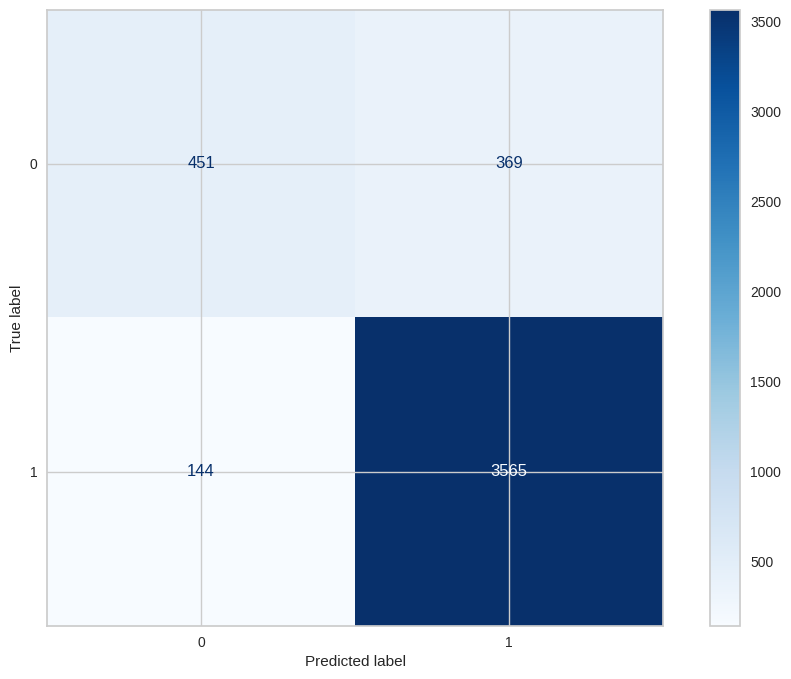

In [172]:
print("XGB MODEL")

eval(xgb_model, X_train_count, X_test_count)

In [173]:
from sklearn.model_selection import GridSearchCV

# Define XGBoost model
xgb_model = XGBClassifier(random_state=42, n_jobs=-1)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [200, 300],       # Reduce the number of estimators
    'max_depth': [8, 10],             # Reduce the number of maximum depths
    'learning_rate': [0.1, 0.01]      # Reduce the number of learning rates
}

# Perform Grid Search Cross-Validation with fewer folds
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=2, scoring='accuracy')
grid_search.fit(X_train_count, y_train)

# Get the best parameters and accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Accuracy:", best_accuracy)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}
Best Accuracy: 0.8790304770318021


In [174]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define custom scorers
custom_scorer = {
    'accuracy': make_scorer(accuracy_score),
    'precision-0': make_scorer(precision_score, pos_label=0),
    'recall-0': make_scorer(recall_score, pos_label=0),
    'f1-0': make_scorer(f1_score, pos_label=0),
    'precision-1': make_scorer(precision_score, pos_label=1),
    'recall-1': make_scorer(recall_score, pos_label=1),
    'f1-1': make_scorer(f1_score, pos_label=1)
}

# Iterate through custom scorers
for i, j in custom_scorer.items():
    model = XGBClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_count, y_train, cv=2, scoring=j).mean()
    if i == "recall-1":
        xgb_count_rec = scores
    elif i == "f1-1":
        xgb_count_f1 = scores
    elif i == "accuracy":
        xgb_count_acc = scores
    print(f"{i:20} score for count : {scores}\n")


accuracy             score for count : 0.8789200530035336

precision-0          score for count : 0.7184757470006402

recall-0             score for count : 0.5452581337970601

f1-0                 score for count : 0.6199616129756791

precision-1          score for count : 0.9044971461052499

recall-1             score for count : 0.9527340877299797

f1-1                 score for count : 0.9279879031040279



### XGBoost Using TF-IDF Vectorizer

In [175]:
# Define the XGBoost classifier with similar parameters
xgb = XGBClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1, scale_pos_weight=1)

# Train the XGBoost model
xgb.fit(X_train_tf_idf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

XGBoost MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.75      0.53      0.62       820
           1       0.90      0.96      0.93      3709

    accuracy                           0.88      4529
   macro avg       0.83      0.75      0.78      4529
weighted avg       0.88      0.88      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3281
           1       1.00      1.00      1.00     14831

    accuracy                           1.00     18112
   macro avg       1.00      0.99      0.99     18112
weighted avg       1.00      1.00      1.00     18112



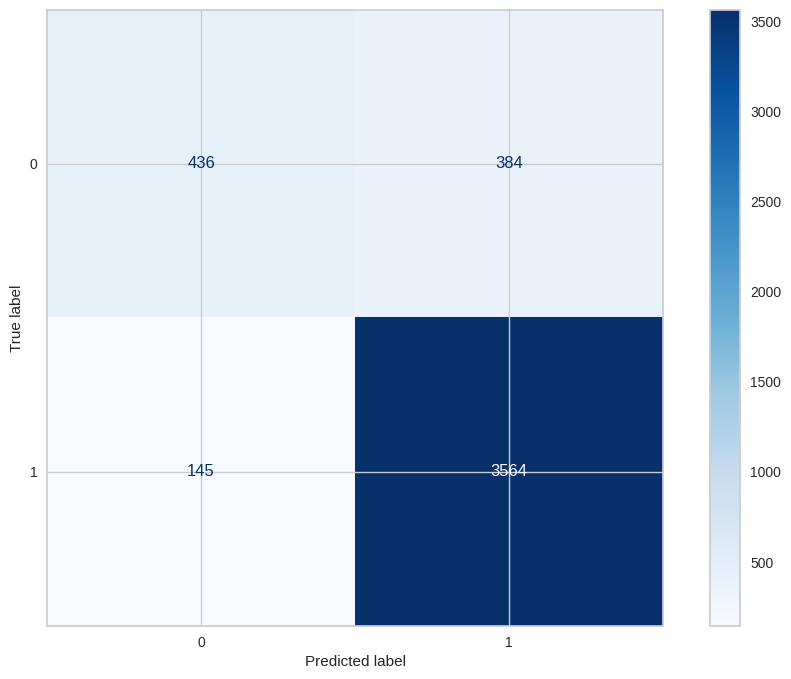

In [176]:
print("XGBoost MODEL")

eval(xgb, X_train_tf_idf, X_test_tf_idf)

In [177]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

# Define custom scorers
custom_scorer = {
    'accuracy': make_scorer(accuracy_score),
    'precision-0': make_scorer(precision_score, pos_label=0),
    'recall-0': make_scorer(recall_score, pos_label=0),
    'f1-0': make_scorer(f1_score, pos_label=0),
    'precision-1': make_scorer(precision_score, pos_label=1),
    'recall-1': make_scorer(recall_score, pos_label=1),
    'f1-1': make_scorer(f1_score, pos_label=1)
}

# Initialize XGBoost classifier
xgb = XGBClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1, scale_pos_weight=1)

# Evaluate the model using cross-validation
for metric, scorer in custom_scorer.items():
    scores = cross_val_score(xgb, X_train_tf_idf, y_train, cv=2, scoring=scorer).mean()
    if metric == "recall-1":
        xgb_tfidf_rec = scores
    elif metric == "f1-1":
        xgb_tfidf_f1 = scores
    elif metric == "accuracy":
        xgb_tfidf_acc = scores
    print(f"{metric:20} score for tfidf: {scores}\n")


accuracy             score for tfidf: 0.872791519434629

precision-0          score for tfidf: 0.7206382489381276

recall-0             score for tfidf: 0.4864354349667811

f1-0                 score for tfidf: 0.5807698863060737

precision-1          score for tfidf: 0.8940072112179398

recall-1             score for tfidf: 0.9582629928110096

f1-1                 score for tfidf: 0.9250191191938575



## Ada Boosting

### Ada Boosting Using Count Vectorizer

In [178]:
ada = AdaBoostClassifier(n_estimators= 500, random_state = 42)
ada.fit(X_train_count, y_train)

AdaBoostClassifier(n_estimators=500, random_state=42)

Ada MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.73      0.59      0.65       820
           1       0.91      0.95      0.93      3709

    accuracy                           0.89      4529
   macro avg       0.82      0.77      0.79      4529
weighted avg       0.88      0.89      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       0.80      0.66      0.72      3281
           1       0.93      0.96      0.94     14831

    accuracy                           0.91     18112
   macro avg       0.86      0.81      0.83     18112
weighted avg       0.90      0.91      0.90     18112



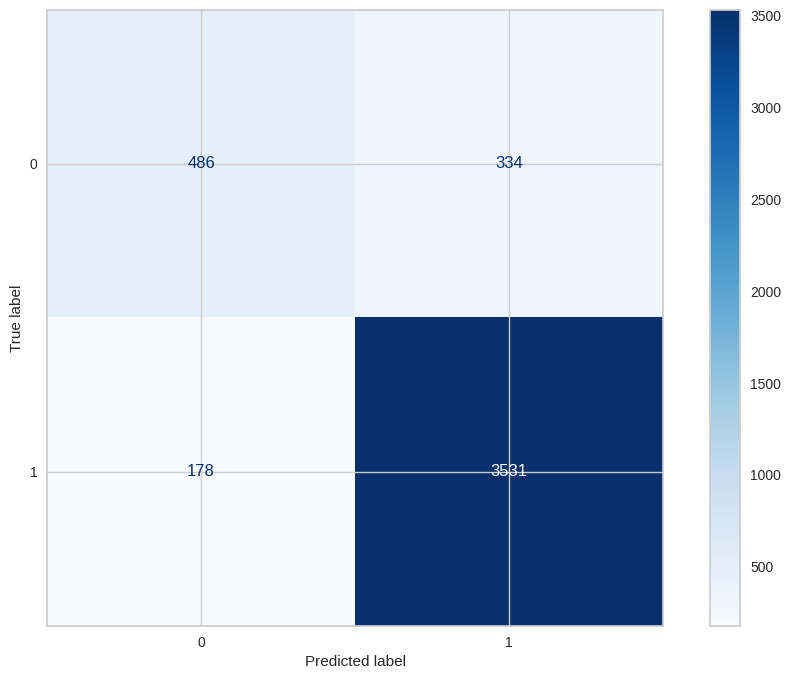

In [179]:
print("Ada MODEL")

eval(ada, X_train_count, X_test_count)

In [180]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model = AdaBoostClassifier(n_estimators= 500, random_state = 42)
    scores = cross_val_score(model, X_train_count, y_train, cv = 2, scoring = j).mean()
    if i == "recall-1":
        ada_count_rec = scores
    elif i == "f1-1":
        ada_count_f1 = scores
    elif i == "accuracy":
        ada_count_acc = scores
    print(f" {i:20} score for count : {scores}\n")

 accuracy             score for count : 0.8709143109540636

 precision-0          score for count : 0.6753813232930928

 recall-0             score for count : 0.5534922563576641

 f1-0                 score for count : 0.608344212866522

 precision-1          score for count : 0.9050164478662672

 recall-1             score for count : 0.941136903242138

 f1-1                 score for count : 0.9227210854030318



### Ada Boosting using TF-IDF Vectorizer

In [181]:
ada = AdaBoostClassifier(n_estimators= 500, random_state = 42)

ada.fit(X_train_tf_idf, y_train)

AdaBoostClassifier(n_estimators=500, random_state=42)

Ada MODEL
Test_Set
              precision    recall  f1-score   support

           0       0.71      0.58      0.63       820
           1       0.91      0.95      0.93      3709

    accuracy                           0.88      4529
   macro avg       0.81      0.76      0.78      4529
weighted avg       0.87      0.88      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       0.82      0.70      0.76      3281
           1       0.94      0.97      0.95     14831

    accuracy                           0.92     18112
   macro avg       0.88      0.83      0.85     18112
weighted avg       0.91      0.92      0.92     18112



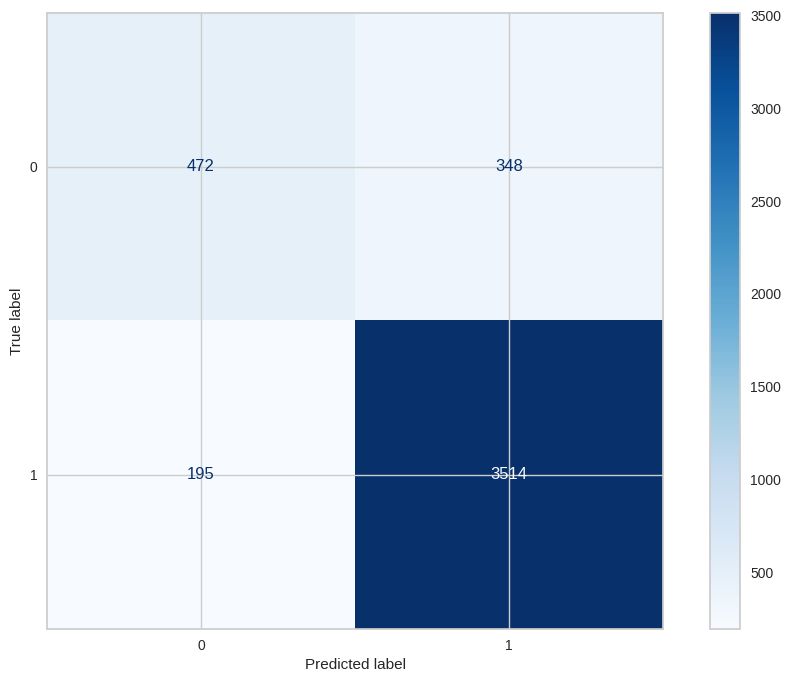

In [182]:
print("Ada MODEL")

eval(ada, X_train_tf_idf, X_test_tf_idf)

In [183]:
custom_scorer = {'accuracy': make_scorer(accuracy_score),
                 'precision-0': make_scorer(precision_score, pos_label=0),
                 'recall-0': make_scorer(recall_score, pos_label=0),
                 'f1-0': make_scorer(f1_score, pos_label=0),
                 'precision-1': make_scorer(precision_score, pos_label=1),
                 'recall-1': make_scorer(recall_score, pos_label=1),
                 'f1-1': make_scorer(f1_score, pos_label=1)
                 }

for i, j in custom_scorer.items():
    model =AdaBoostClassifier(n_estimators= 500, random_state = 42)
    scores = cross_val_score(model, X_train_tf_idf, y_train, cv = 2, scoring = j).mean()
    if i == "recall-1":
        ada_tfidf_rec = scores
    elif i == "f1-1":
        ada_tfidf_f1 = scores
    elif i == "accuracy":
        ada_tfidf_acc = scores
    print(f" {i:20} score for tfidf : {scores}\n")

 accuracy             score for tfidf : 0.8630742049469965

 precision-0          score for tfidf : 0.6440341482295875

 recall-0             score for tfidf : 0.5470879594536348

 f1-0                 score for tfidf : 0.5914819853158346

 precision-1          score for tfidf : 0.9030236856620542

 recall-1             score for tfidf : 0.932977902746772

 f1-1                 score for tfidf : 0.9177495560327807



## LightGBM

### Using Count Vectorizor

In [184]:
import lightgbm as lgb

# Create the LightGBM classifier
lgb_model = lgb.LGBMClassifier(n_estimators=200, num_leaves=31, max_depth=12, random_state=42, n_jobs=-1)
X_train_count = X_train_count.toarray()
y_train = y_train.values
# Fit the model to the training data
lgb_model.fit(X_train_count, y_train)


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14831, number of negative: 3281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.240348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5584
[LightGBM] [Info] Number of data points in the train set: 18112, number of used features: 1879
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.818849 -> initscore=1.508571
[LightGBM] [Info] Start training from score 1.508571
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

LGBMClassifier(max_depth=12, n_estimators=200, n_jobs=-1, random_state=42)

XGB MODEL
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
Test_Set
              precision    recall  f1-score   support

           0       0.78      0.54      0.64       820
           1       0.91      0.97      0.94      3709

    accuracy                           0.89      4529
   macro avg       0.84      0.75      0.79      4529
weighted avg       0.88      0.89      0.88      4529

Train_Set
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      3281
           1       0.95      0.99      0.97     14831

    accuracy                           0.95     18112
   macro avg       0.94      0.88      0.91     18112
weighted avg       0.95      0.95      0.95     18112



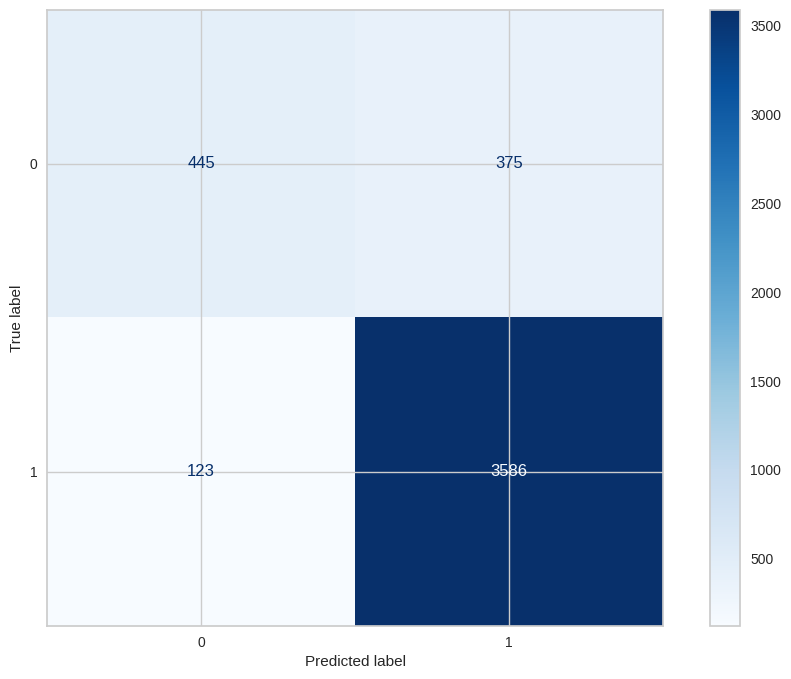

In [185]:
print("XGB MODEL")
X_test_count = X_test_count.toarray()
eval(lgb_model, X_train_count, X_test_count)

In [186]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

# Define LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [200, 300, 400],  # Try different numbers of estimators
    'max_depth': [8, 10, 12],          # Try different maximum depths
    'learning_rate': [0.1, 0.01, 0.001],  # Try different learning rates
    'num_leaves': [31, 63, 127]
}

# Perform Grid Search Cross-Validation with fewer folds
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=2, scoring='accuracy')
grid_search.fit(X_train_count, y_train)

# Get the best parameters and accuracy
best_params_count = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Best Parameters:", best_params_count)
print("Best Accuracy:", best_accuracy)


Streaming output truncated to the last 5000 lines.
[LightGBM] [Info] Number of positive: 7415, number of negative: 1641
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.088734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3932
[LightGBM] [Info] Number of data points in the train set: 9056, number of used features: 1313
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.818794 -> initscore=1.508199
[LightGBM] [Info] Start training from score 1.508199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [187]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define custom scorers
# Define custom scorers with positive label specified
custom_scorer = {
    'accuracy': make_scorer(accuracy_score),
    'precision-0': make_scorer(precision_score, pos_label=0),
    'recall-0': make_scorer(recall_score, pos_label=0),
    'f1-0': make_scorer(f1_score, pos_label=0),
    'precision-1': make_scorer(precision_score, pos_label=1),
    'recall-1': make_scorer(recall_score, pos_label=1),
    'f1-1': make_scorer(f1_score, pos_label=1)
}


# Iterate through custom scorers
for i, j in custom_scorer.items():
    model = LGBMClassifier(n_estimators=best_params_count['n_estimators'],
                          max_depth=best_params_count['max_depth'],
                           num_leaves=best_params_count['num_leaves'],
                          learning_rate=best_params_count['learning_rate'],
                          random_state=42,
                          n_jobs=-1)
    scores = cross_val_score(model, X_train_count, y_train, cv=2, scoring=j).mean()
    if i == "recall-1":
        lgb_count_rec = scores
    elif i == "f1-1":
        lgb_count_f1 = scores
    elif i == "accuracy":
        lgb_count_acc = scores
    print(f"{i:20} score for count : {scores}\n")


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 7415, number of negative: 1641
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3932
[LightGBM] [Info] Number of data points in the train set: 9056, number of used features: 1313
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.818794 -> initscore=1.508199
[LightGBM] [Info] Start training from score 1.508199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

### Using TF-IDF Vectorizor

In [188]:
import lightgbm as lgb

# Define the LightGBM classifier with similar parameters
lgb_model = lgb.LGBMClassifier(n_estimators=200,num_leaves=31, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')

# Train the LightGBM model
lgb_model.fit(X_train_tf_idf, y_train)


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 14831, number of negative: 3281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.280647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 106968
[LightGBM] [Info] Number of data points in the train set: 18112, number of used features: 1879
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

LGBMClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
               n_jobs=-1, random_state=42)

XGBoost MODEL
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
Test_Set
              precision    recall  f1-score   support

           0       0.60      0.76      0.67       820
           1       0.94      0.89      0.92      3709

    accuracy                           0.87      4529
   macro avg       0.77      0.82      0.79      4529
weighted avg       0.88      0.87      0.87      4529

Train_Set
              precision    recall  f1-score   support

           0       0.74      0.99      0.85      3281
           1       1.00      0.92      0.96     14831

    accuracy                           0.94     18112
   macro avg       0.87      0.96      0.90     18112
weighted avg       0.95      0.94      0.94     18112



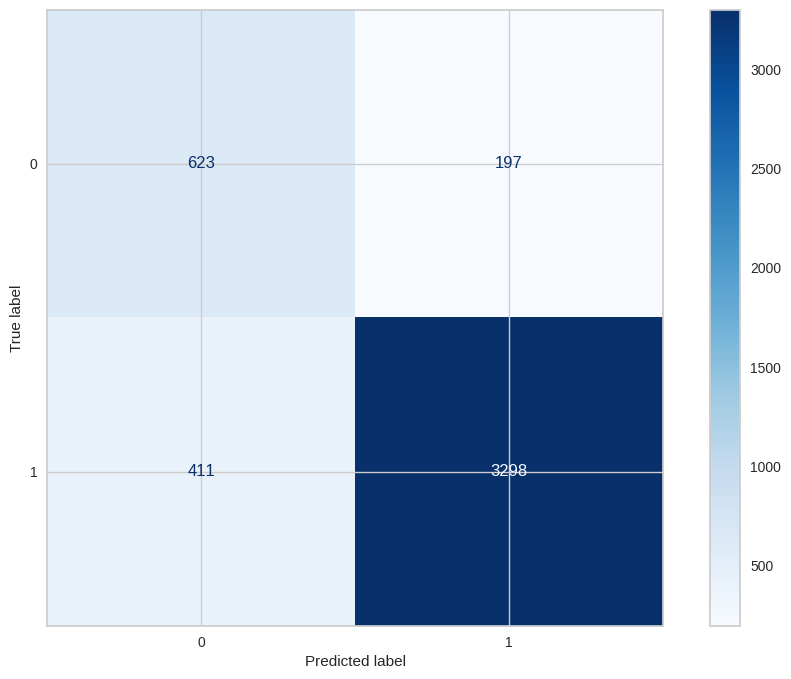

In [189]:
print("XGBoost MODEL")

eval(lgb_model, X_train_tf_idf, X_test_tf_idf)

In [190]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

# Define LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [200, 300, 400],  # Try different numbers of estimators
    'max_depth': [8, 10, 12],          # Try different maximum depths
    'learning_rate': [0.1, 0.01, 0.001],  # Try different learning rates
    'num_leaves': [31, 63, 127]
}

# Perform Grid Search Cross-Validation with fewer folds
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=2, scoring='accuracy')
grid_search.fit(X_train_tf_idf, y_train)

# Get the best parameters and accuracy
best_params_tf_idf = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Best Parameters:", best_params_tf_idf)
print("Best Accuracy:", best_accuracy)


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [191]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define custom scorers
# Define custom scorers with positive label specified
custom_scorer = {
    'accuracy': make_scorer(accuracy_score),
    'precision-0': make_scorer(precision_score, pos_label=0),
    'recall-0': make_scorer(recall_score, pos_label=0),
    'f1-0': make_scorer(f1_score, pos_label=0),
    'precision-1': make_scorer(precision_score, pos_label=1),
    'recall-1': make_scorer(recall_score, pos_label=1),
    'f1-1': make_scorer(f1_score, pos_label=1)
}


# Initialize LightGBM classifier
lgb_model = lgb.LGBMClassifier(n_estimators=best_params_tf_idf['n_estimators'],
                          max_depth=best_params_tf_idf['max_depth'],
                          num_leaves=best_params_tf_idf['num_leaves'],
                          learning_rate=best_params_tf_idf['learning_rate'],
                          random_state=42,
                          n_jobs=-1)

# Evaluate the model using cross-validation
for metric, scorer in custom_scorer.items():
    scores = cross_val_score(lgb_model, X_train_tf_idf, y_train, cv=2, scoring=scorer).mean()
    if metric == "recall-1":
        lgb_tfidf_rec = scores
    elif metric == "f1-1":
        lgb_tfidf_f1 = scores
    elif metric == "accuracy":
        lgb_tfidf_acc = scores
    print(f"{metric:20} score for tfidf: {scores}\n")


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 7415, number of negative: 1641
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.144736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 61954
[LightGBM] [Info] Number of data points in the train set: 9056, number of used features: 1313
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.818794 -> initscore=1.508199
[LightGBM] [Info] Start training from score 1.508199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

# 10) DEEP LEARNING MODELLING

In [192]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [193]:
df0 = pd.read_csv('/content/drive/MyDrive/CSE445 (Project)/Womens Clothing E-Commerce Reviews.csv')
df_dl = df0.copy()
df_dl.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses


In [194]:
df_dl = df_dl[["Review Text","Recommended IND"]]
df_dl.head()

,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comfortable,1
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length...",1
2,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i co...,0
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",1
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,1


In [195]:
df_dl.shape

(23486, 2)

In [196]:
df_dl.dropna(inplace = True)

In [197]:
df_dl.shape

(22641, 2)

### 10.1 Tokenization

In [198]:
X = df_dl['Review Text'].values
y = df_dl['Recommended IND'].values

In [199]:
num_words = 10000
# We have defined the most frequent 10000 repeated words in corpus for tokenizing. We ignore the rest.

tokenizer = Tokenizer(num_words=num_words)
# The default values of "filters" are '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'.
# If you also want to filters the numbers, then just "1234567890" at the end.

In [200]:
tokenizer.fit_on_texts(X)

### 10.2 Creating Word Index

In [201]:
tokenizer.word_index

{'the': 1,
 'i': 2,
 'and': 3,
 'a': 4,
 'it': 5,
 'is': 6,
 'this': 7,
 'to': 8,
 'in': 9,
 'but': 10,
 'on': 11,
 'for': 12,
 'of': 13,
 'with': 14,
 'was': 15,
 'so': 16,
 'my': 17,
 'dress': 18,
 'not': 19,
 'that': 20,
 'love': 21,
 'size': 22,
 'very': 23,
 'have': 24,
 'top': 25,
 'fit': 26,
 'are': 27,
 'like': 28,
 'be': 29,
 'as': 30,
 'me': 31,
 'wear': 32,
 "it's": 33,
 'great': 34,
 'too': 35,
 "i'm": 36,
 'or': 37,
 'am': 38,
 'just': 39,
 'you': 40,
 'would': 41,
 'they': 42,
 'up': 43,
 'at': 44,
 'fabric': 45,
 'small': 46,
 'color': 47,
 'look': 48,
 'if': 49,
 'more': 50,
 'really': 51,
 'ordered': 52,
 'little': 53,
 'perfect': 54,
 'will': 55,
 'one': 56,
 'these': 57,
 'flattering': 58,
 'well': 59,
 'an': 60,
 'soft': 61,
 'out': 62,
 'back': 63,
 'because': 64,
 'had': 65,
 'can': 66,
 '\r': 67,
 'comfortable': 68,
 'cute': 69,
 'nice': 70,
 'than': 71,
 'bought': 72,
 'beautiful': 73,
 'when': 74,
 'all': 75,
 'looks': 76,
 'bit': 77,
 'fits': 78,
 'large': 79,

In [202]:
len(tokenizer.word_index)

14847

### 10.3 Converting Tokens To Numeric

In [203]:
X_num_tokens = tokenizer.texts_to_sequences(X)

In [204]:
num_tokens = [len(tokens) for tokens in X_num_tokens]
num_tokens = np.array(num_tokens)

In [205]:
from keras.preprocessing.sequence import pad_sequences

# Get the maximum length of the lists in X_num_tokens
max_length = max(len(tokens) for tokens in X_num_tokens)

# Pad the shorter lists with zeros
X_num_tokens = pad_sequences(X_num_tokens, maxlen=max_length, padding='post')

# Convert the padded list to a NumPy array
X_array = np.array(X_num_tokens)

In [206]:
np.array(X_num_tokens)

array([[253, 532, 917, ...,   0,   0,   0],
       [ 21,   7,  18, ...,   0,   0,   0],
       [  2,  65, 312, ...,   0,   0,   0],
       ...,
       [  7,  26,  59, ...,   0,   0,   0],
       [  2,  72,   7, ...,   0,   0,   0],
       [  7,  18,   9, ...,   0,   0,   0]], dtype=int32)

In [207]:
X[105]

'The shirt is exactly as it is pictured, i have the burnt orange color and love it! i received numerous compliments both paired with jeans and tucked into a fun skirt. it fits true to size, as i normally wear a small in all retailer however it is the slightest bit tight in the shoulders. i would give this top a 5/5.'

In [208]:
print(X_num_tokens[105])

[   1   80    6  478   30    5    6  389    2   24    1 1905  482   47
    3   21    5    2  243 2182  210  189  563   14   92    3  871  313
    4  283  109    5   78  130    8   22   30    2  239   32    4   46
    9   75  103  143    5    6    1 2868   77  148    9    1  200    2
   41  324    7   25    4  265  265    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


In [209]:
# tokenizer.word_index["The"]
# This code will give you an error since "The" which is not among the most repeated 10000 words was excluded while tokenizing

In [210]:
tokenizer.word_index["shirt"]

80

In [211]:
tokenizer.word_index["exactly"]

478

### 10.4 The Determination of Maximum Number of Tokens

This part is the preparation for padding.

In [212]:
num_tokens.mean()

60.39287133960514

In [213]:
num_tokens.max()

116

In [214]:
num_tokens.argmax()

16263

In [215]:
X[16263]

"I love maeve tops. i love the material and feel of this brand. when i saw the new tops that came out i ran to my local store to try one on. i'm usually a large in a top, once in a while an xl. they only had a large to try so i tried it in the black motif.\ni could barely get the top on. it looked like i was missing 1/2 of the top. i doubled checked the size and it was a large.\nit's a shame, the top is really cute. if you are the least bit broad or busty, go up a size or two. if you are usually a"

In [216]:
len(X[16263])

499

In [217]:
num_tokens.argmin()

820

In [218]:
X[820]

'Great style!'

In [219]:
len(X[820])

12

### 10.5 Fixing Token Counts of All documents (Pad Sequences)

In [220]:
len(X_num_tokens[105])

116

In [221]:
np.array(X_num_tokens[105])

array([   1,   80,    6,  478,   30,    5,    6,  389,    2,   24,    1,
       1905,  482,   47,    3,   21,    5,    2,  243, 2182,  210,  189,
        563,   14,   92,    3,  871,  313,    4,  283,  109,    5,   78,
        130,    8,   22,   30,    2,  239,   32,    4,   46,    9,   75,
        103,  143,    5,    6,    1, 2868,   77,  148,    9,    1,  200,
          2,   41,  324,    7,   25,    4,  265,  265,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0], dtype=int32)

In [222]:
len(X_num_tokens[106])

116

In [223]:
np.array(X_num_tokens[106])

array([  54,   18,   12,  495, 2088, 2955,  452,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0], dtype=int32)

In [224]:
num_tokens = [len(tokens) for tokens in X_num_tokens]

num_tokens = np.array(num_tokens)

In [225]:
num_tokens

array([116, 116, 116, ..., 116, 116, 116])

In [226]:
max_tokens = 103

In [227]:
sum(num_tokens < max_tokens) / len(num_tokens)

0.0

In [228]:
sum(num_tokens < max_tokens) # the number of documents which have 103 or less tokens

0

In [229]:
len(num_tokens)  # total number of all documents in corpus which is constrained by num_words as 20000

22641

In [230]:
X_pad = pad_sequences(X_num_tokens, maxlen=max_tokens)

In [231]:
X_pad.shape

(22641, 103)

In [232]:
X_pad[105]

array([  47,    3,   21,    5,    2,  243, 2182,  210,  189,  563,   14,
         92,    3,  871,  313,    4,  283,  109,    5,   78,  130,    8,
         22,   30,    2,  239,   32,    4,   46,    9,   75,  103,  143,
          5,    6,    1, 2868,   77,  148,    9,    1,  200,    2,   41,
        324,    7,   25,    4,  265,  265,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0], dtype=int32)

### 10.6 Train | Set & Split

In [233]:
from sklearn.model_selection import train_test_split

In [234]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, stratify=y, random_state=101)

# we have been using stratify to prevent imbalance.

## LSTM Model implementation

In [286]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

model = Sequential()

embedding_size = 100

model.add(Embedding(input_dim=num_words,
                    output_dim=embedding_size,
                    input_length=max_tokens,
                    name='embedding_layer'))

model.add(LSTM(units=48, return_sequences=True))
model.add(LSTM(units=24, return_sequences=True))
model.add(LSTM(units=12))
model.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.006)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['Recall'])

model.summary()

early_stop = EarlyStopping(monitor="val_loss", mode="auto",
                           verbose=1, patience=10, restore_best_weights=True)

pd.Series(y_train).value_counts(normalize=True)

weights = {0:82, 1:18}

model.fit(X_train, y_train, epochs=30, batch_size=256, class_weight=weights,
          validation_data=(X_test, y_test), callbacks=[early_stop])

model.save('NLP_Sentiment_Analysis_Project_lstm')


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_layer (Embedding  (None, 103, 100)          1000000   
 )                                                               
                                                                 
 lstm_6 (LSTM)               (None, 103, 48)           28608     
                                                                 
 lstm_7 (LSTM)               (None, 103, 24)           7008      
                                                                 
 lstm_8 (LSTM)               (None, 12)                1776      
                                                                 
 dense_3 (Dense)             (None, 1)                 13        
                                                                 
Total params: 1037405 (3.96 MB)
Trainable params: 1037405 (3.96 MB)
Non-trainable params: 0 (0.00 Byte)
________________

566/566 [==============================] - 20s 33ms/step
[[ 2823   458]
 [ 1196 13635]]
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0.86      0.77      3281
           1       0.97      0.92      0.94     14831

    accuracy                           0.91     18112
   macro avg       0.83      0.89      0.86     18112
weighted avg       0.92      0.91      0.91     18112

142/142 [==============================] - 7s 39ms/step
[[ 604  216]
 [ 394 3315]]
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.61      0.74      0.66       820
           1       0.94      0.89      0.92      3709

    accuracy                           0.87      4529
   macro avg       0.77      0.82      0.79      4529
weighted avg       0.88      0.87      0.87      4529

142/142 [==============================] - 4s 30ms/step


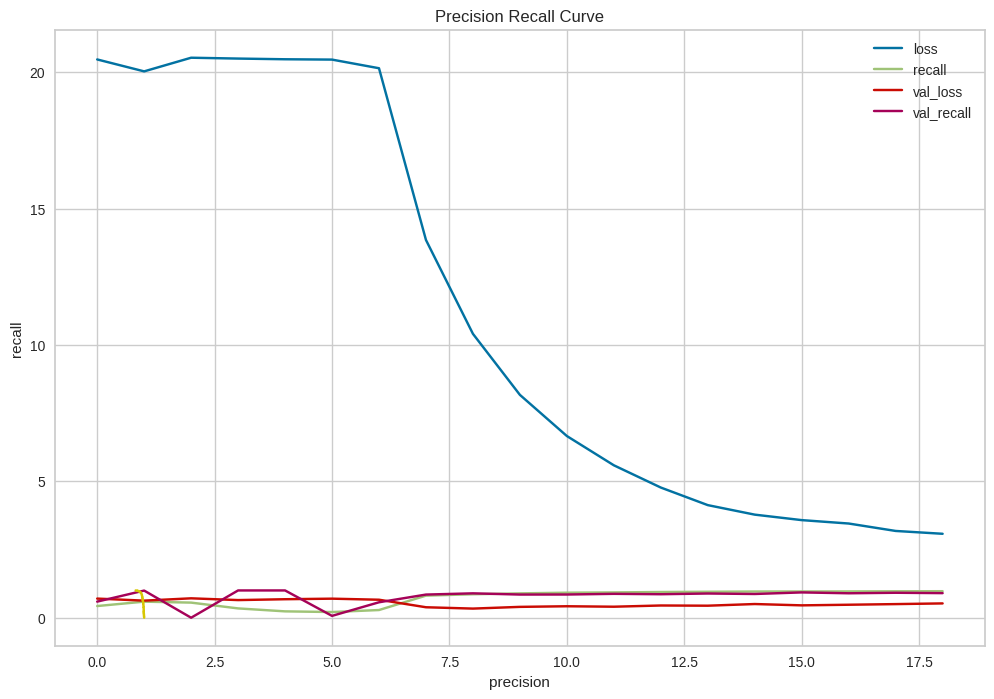

In [287]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score, recall_score

# Evaluate the model
model_loss = pd.DataFrame(model.history.history)
model_loss.head()

model_loss.plot();

model.evaluate(X_train, y_train)

model.evaluate(X_test, y_test)

# Predictions on training data
y_train_pred = (model.predict(X_train) >= 0.5).astype("int32")
print(confusion_matrix(y_train, y_train_pred))
print("-------------------------------------------------------")
print(classification_report(y_train, y_train_pred))

# Predictions on test data
y_pred = (model.predict(X_test) >= 0.5).astype("int32")
print(confusion_matrix(y_test, y_pred))
print("-------------------------------------------------------")
print(classification_report(y_test, y_pred))

# Precision-Recall Curve
y_pred_proba = model.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.plot(precision, recall)
plt.xlabel('precision')
plt.ylabel('recall')
plt.title('Precision Recall Curve')
plt.show()

# Other evaluation metrics
DLM_AP = average_precision_score(y_test, y_pred_proba)
DLM_f1 = f1_score(y_test, y_pred)
DLM_rec = recall_score(y_test, y_pred)
DLM_acc = accuracy_score(y_test, y_pred)


### 11) PREDICTION

In [288]:
review1 = "Love this dress"
review2 = "Absolutely wonderful. silky and sexy and comfortable"
review3 = "i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up!"
review4 = "I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!"
review5 = 'This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!'
review6 = 'I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress.'
review7 = 'I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.'
review8 = 'Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the material on the top looks and feels very cheap that even just pulling on it will cause it to rip the fabric. pretty disappointed as it was going to be my christmas dress this year! needless to say it will be going back.'
review9 =  "if you are at least average height or taller, this may look good on you."
review10 = "sadly will be returning, but i'm sure i will find something to exchange it for!"
review11 = "Cute little dress fits tts. it is a little high waisted. good length for my 5'9 height. i like the dress, i'm just not in love with it. i dont think it looks or feels cheap. it appears just as pictured."
review12 = 'Loved the material, but i didnt really look at how long the dress was before i purchased both a large and a medium. im 5\'5" and there was atleast 5" of material at my feet. the gaps in the front are much wider than they look. felt like the dress just fell flat. both were returned. im usually a large and the med fit better. 36d 30 in jeans'
review13 = "I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat."
review14 = 'Very comfortable, material is good, cut out on sleeves flattering'
reviews = [review1, review2, review3, review4, review5, review6, review7, review8, review9, review10, review11, review12, review13, review14]

Let's convert reviews above to numeric by tokenizing.

In [289]:
tokens = tokenizer.texts_to_sequences(reviews)

Let's pad the tokenized reviews.

In [290]:
tokens_pad = pad_sequences(tokens, maxlen=max_tokens)
tokens_pad.shape

(14, 103)

Let's predict the sentiment of our reviews.

In [291]:
mod_pred = model.predict(tokens_pad)

1/1 [==============================] - 0s 42ms/step


In [292]:
mod_pred

array([[0.73684514],
       [0.8246322 ],
       [0.8702968 ],
       [0.9596711 ],
       [0.9529553 ],
       [0.8067219 ],
       [0.95173955],
       [0.0873832 ],
       [0.42665988],
       [0.47722763],
       [0.90801615],
       [0.07877311],
       [0.42814088],
       [0.7220852 ]], dtype=float32)

Let's create DataFrame for visually a better understanding.

In [293]:
df_pred = pd.DataFrame(mod_pred, index=reviews)
df_pred.rename(columns={0: 'Pred_Proba'}, inplace=True)

In [294]:
df_pred["Predicted_Feedbaack"] = df_pred["Pred_Proba"].apply(lambda x: "Recommended" if x>=0.5 else "Not Recommended")

In [295]:
df_pred

,Pred_Proba,Predicted_Feedbaack
Love this dress,0.74,Recommended
Absolutely wonderful. silky and sexy and comfortable,0.82,Recommended
i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up!,0.87,Recommended
"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",0.96,Recommended
This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,0.95,Recommended
"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress.",0.81,Recommended
I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,0.95,Recommended
Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the material on the top looks and feels very cheap that even just pulling on it will cause it to rip the fabric. pretty disappointed as it was going to be my christmas dress this year! needless to say it will be going back.,0.09,Not Recommended
"if you are at least average height or taller, this may look good on you.",0.43,Not Recommended
"sadly will be returning, but i'm sure i will find something to exchange it for!",0.48,Not Recommended


## GRU Model Implemntation

In [245]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Embedding
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Gated Recurrent Unit

In [246]:
model = Sequential()

In [247]:
embedding_size = 100

In [248]:
model.add(Embedding(input_dim=num_words,
                    output_dim=embedding_size,
                    input_length=max_tokens,
                    name='embedding_layer'))

In [249]:
model.add(GRU(units=48, return_sequences=True))
model.add(GRU(units=24, return_sequences=True))
model.add(GRU(units=12))
model.add(Dense(1, activation='sigmoid'))

In [250]:
optimizer = Adam(learning_rate=0.006)

In [251]:
model.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['Recall'])

In [252]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_layer (Embedding  (None, 103, 100)          1000000   
 )                                                               
                                                                 
 gru (GRU)                   (None, 103, 48)           21600     
                                                                 
 gru_1 (GRU)                 (None, 103, 24)           5328      
                                                                 
 gru_2 (GRU)                 (None, 12)                1368      
                                                                 
 dense_1 (Dense)             (None, 1)                 13        
                                                                 
Total params: 1028309 (3.92 MB)
Trainable params: 1028309 (3.92 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [253]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", mode="auto",
                           verbose=1, patience = 10, restore_best_weights=True)

In [254]:
pd.Series(y_train).value_counts(normalize=True)

1   0.82
0   0.18
Name: proportion, dtype: float64

In [255]:
weights = {0:82, 1:18}

In [256]:
model.fit(X_train, y_train, epochs=30, batch_size=256, class_weight=weights,
          validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/30
71/71 [==============================] - 39s 447ms/step - loss: 20.5498 - recall: 0.4739 - val_loss: 0.6922 - val_recall: 0.9997
Epoch 2/30
71/71 [==============================] - 28s 390ms/step - loss: 18.5131 - recall: 0.4837 - val_loss: 0.5338 - val_recall: 0.7185
Epoch 3/30
71/71 [==============================] - 31s 442ms/step - loss: 10.9612 - recall: 0.8355 - val_loss: 0.4096 - val_recall: 0.8061
Epoch 4/30
71/71 [==============================] - 29s 404ms/step - loss: 7.8003 - recall: 0.8885 - val_loss: 0.3190 - val_recall: 0.9056
Epoch 5/30
71/71 [==============================] - 27s 385ms/step - loss: 5.8238 - recall: 0.9197 - val_loss: 0.4021 - val_recall: 0.8736
Epoch 6/30
71/71 [==============================] - 26s 359ms/step - loss: 4.2877 - recall: 0.9437 - val_loss: 0.4409 - val_recall: 0.8733
Epoch 7/30
71/71 [==============================] - 29s 404ms/step - loss: 3.4510 - recall: 0.9609 - val_loss: 0.4224 - val_recall: 0.9102
Epoch 8/30
71/71 [======

In [257]:
model.save('NLP_Sentiment_Analysis_Project')

###  Model Evaluation

In [258]:
model_loss = pd.DataFrame(model.history.history)
model_loss.head()

,loss,recall,val_loss,val_recall
0,20.55,0.47,0.69,1.00
1,18.51,0.48,0.53,0.72
2,10.96,0.84,0.41,0.81
3,7.80,0.89,0.32,0.91
4,5.82,0.92,0.40,0.87


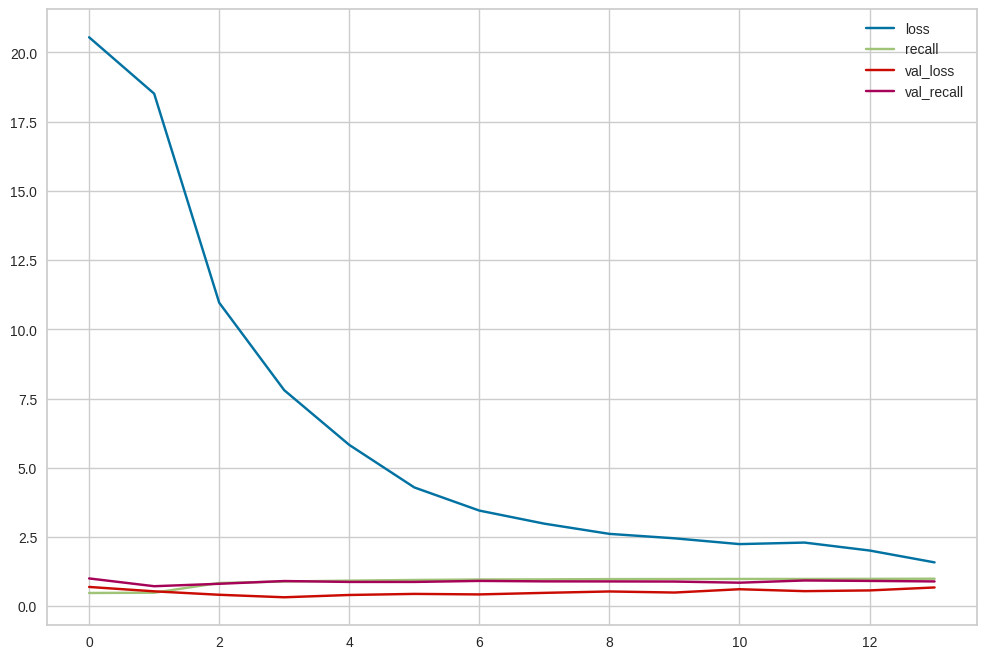

In [259]:
model_loss.plot();

In [260]:
model.evaluate(X_train, y_train)

566/566 [==============================] - 18s 31ms/step - loss: 0.1767 - recall: 0.9407


[0.17669151723384857, 0.9406648278236389]

In [261]:
model.evaluate(X_test, y_test)

142/142 [==============================] - 4s 27ms/step - loss: 0.3190 - recall: 0.9056


[0.3189781904220581, 0.9056349396705627]

In [262]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score

y_train_pred = (model.predict(X_train) >= 0.5).astype("int32")

print(confusion_matrix(y_train, y_train_pred))
print("-------------------------------------------------------")
print(classification_report(y_train, y_train_pred))

566/566 [==============================] - 18s 30ms/step
[[ 3050   231]
 [  880 13951]]
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.93      0.85      3281
           1       0.98      0.94      0.96     14831

    accuracy                           0.94     18112
   macro avg       0.88      0.94      0.90     18112
weighted avg       0.95      0.94      0.94     18112



In [263]:
y_pred = (model.predict(X_test) >= 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))
print("-------------------------------------------------------")
print(classification_report(y_test, y_pred))

142/142 [==============================] - 6s 34ms/step
[[ 604  216]
 [ 350 3359]]
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.63      0.74      0.68       820
           1       0.94      0.91      0.92      3709

    accuracy                           0.88      4529
   macro avg       0.79      0.82      0.80      4529
weighted avg       0.88      0.88      0.88      4529



142/142 [==============================] - 4s 27ms/step


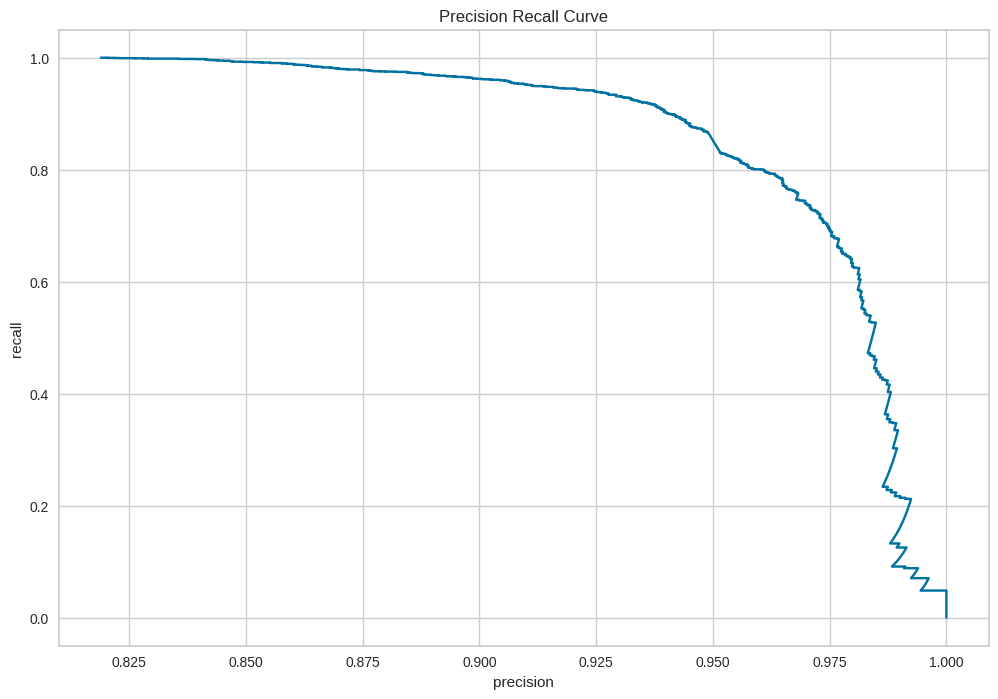

In [264]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_pred_proba = model.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# plt.plot([1, 0], [0, 1],'k--')
plt.plot(precision, recall)
plt.xlabel('precision')
plt.ylabel('recall')
plt.title('Precision Recall Curve')
plt.show()

In [265]:
from sklearn.metrics import precision_recall_curve, average_precision_score, recall_score,accuracy_score

DL_AP = average_precision_score(y_test, y_pred_proba)
DL_f1 = f1_score(y_test, y_pred)
DL_rec = recall_score(y_test, y_pred)
DL_acc = accuracy_score(y_test,y_pred)

###  PREDICTION

In [266]:
review1 = "Love this dress"
review2 = "Absolutely wonderful. silky and sexy and comfortable"
review3 = "i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up!"
review4 = "I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!"
review5 = 'This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!'
review6 = 'I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress.'
review7 = 'I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.'
review8 = 'Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the material on the top looks and feels very cheap that even just pulling on it will cause it to rip the fabric. pretty disappointed as it was going to be my christmas dress this year! needless to say it will be going back.'
review9 =  "if you are at least average height or taller, this may look good on you."
review10 = "sadly will be returning, but i'm sure i will find something to exchange it for!"
review11 = "Cute little dress fits tts. it is a little high waisted. good length for my 5'9 height. i like the dress, i'm just not in love with it. i dont think it looks or feels cheap. it appears just as pictured."
review12 = 'Loved the material, but i didnt really look at how long the dress was before i purchased both a large and a medium. im 5\'5" and there was atleast 5" of material at my feet. the gaps in the front are much wider than they look. felt like the dress just fell flat. both were returned. im usually a large and the med fit better. 36d 30 in jeans'
review13 = "I have been waiting for this sweater coat to ship for weeks and i was so excited for it to arrive. this coat is not true to size and made me look short and squat."
review14 = 'Very comfortable, material is good, cut out on sleeves flattering'
reviews = [review1, review2, review3, review4, review5, review6, review7, review8, review9, review10, review11, review12, review13, review14]

Let's convert reviews above to numeric by tokenizing.

In [267]:
tokens = tokenizer.texts_to_sequences(reviews)

Let's pad the tokenized reviews.

In [268]:
tokens_pad = pad_sequences(tokens, maxlen=max_tokens)
tokens_pad.shape

(14, 103)

Let's predict the sentiment of our reviews.

In [269]:
mod_pred = model.predict(tokens_pad)

1/1 [==============================] - 0s 39ms/step


In [270]:
mod_pred

array([[0.6451574 ],
       [0.60163283],
       [0.41253933],
       [0.9322099 ],
       [0.9426529 ],
       [0.7257275 ],
       [0.9301041 ],
       [0.03802831],
       [0.5776049 ],
       [0.3431997 ],
       [0.46693748],
       [0.03350556],
       [0.26004526],
       [0.5405218 ]], dtype=float32)

Let's create DataFrame for visually a better understanding.

In [271]:
df_pred = pd.DataFrame(mod_pred, index=reviews)
df_pred.rename(columns={0: 'Pred_Proba'}, inplace=True)

In [272]:
df_pred["Predicted_Feedbaack"] = df_pred["Pred_Proba"].apply(lambda x: "Recommended" if x>=0.5 else "Not Recommended")

In [273]:
df_pred

,Pred_Proba,Predicted_Feedbaack
Love this dress,0.65,Recommended
Absolutely wonderful. silky and sexy and comfortable,0.60,Recommended
i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up!,0.41,Not Recommended
"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",0.93,Recommended
This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,0.94,Recommended
"I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pretty out of the package but its a lot of dress.",0.73,Recommended
I love this dress. i usually get an xs but it runs a little snug in bust so i ordered up a size. very flattering and feminine with the usual retailer flair for style.,0.93,Recommended
Dress runs small esp where the zipper area runs. i ordered the sp which typically fits me and it was very tight! the material on the top looks and feels very cheap that even just pulling on it will cause it to rip the fabric. pretty disappointed as it was going to be my christmas dress this year! needless to say it will be going back.,0.04,Not Recommended
"if you are at least average height or taller, this may look good on you.",0.58,Recommended
"sadly will be returning, but i'm sure i will find something to exchange it for!",0.34,Not Recommended


# Comparing Models

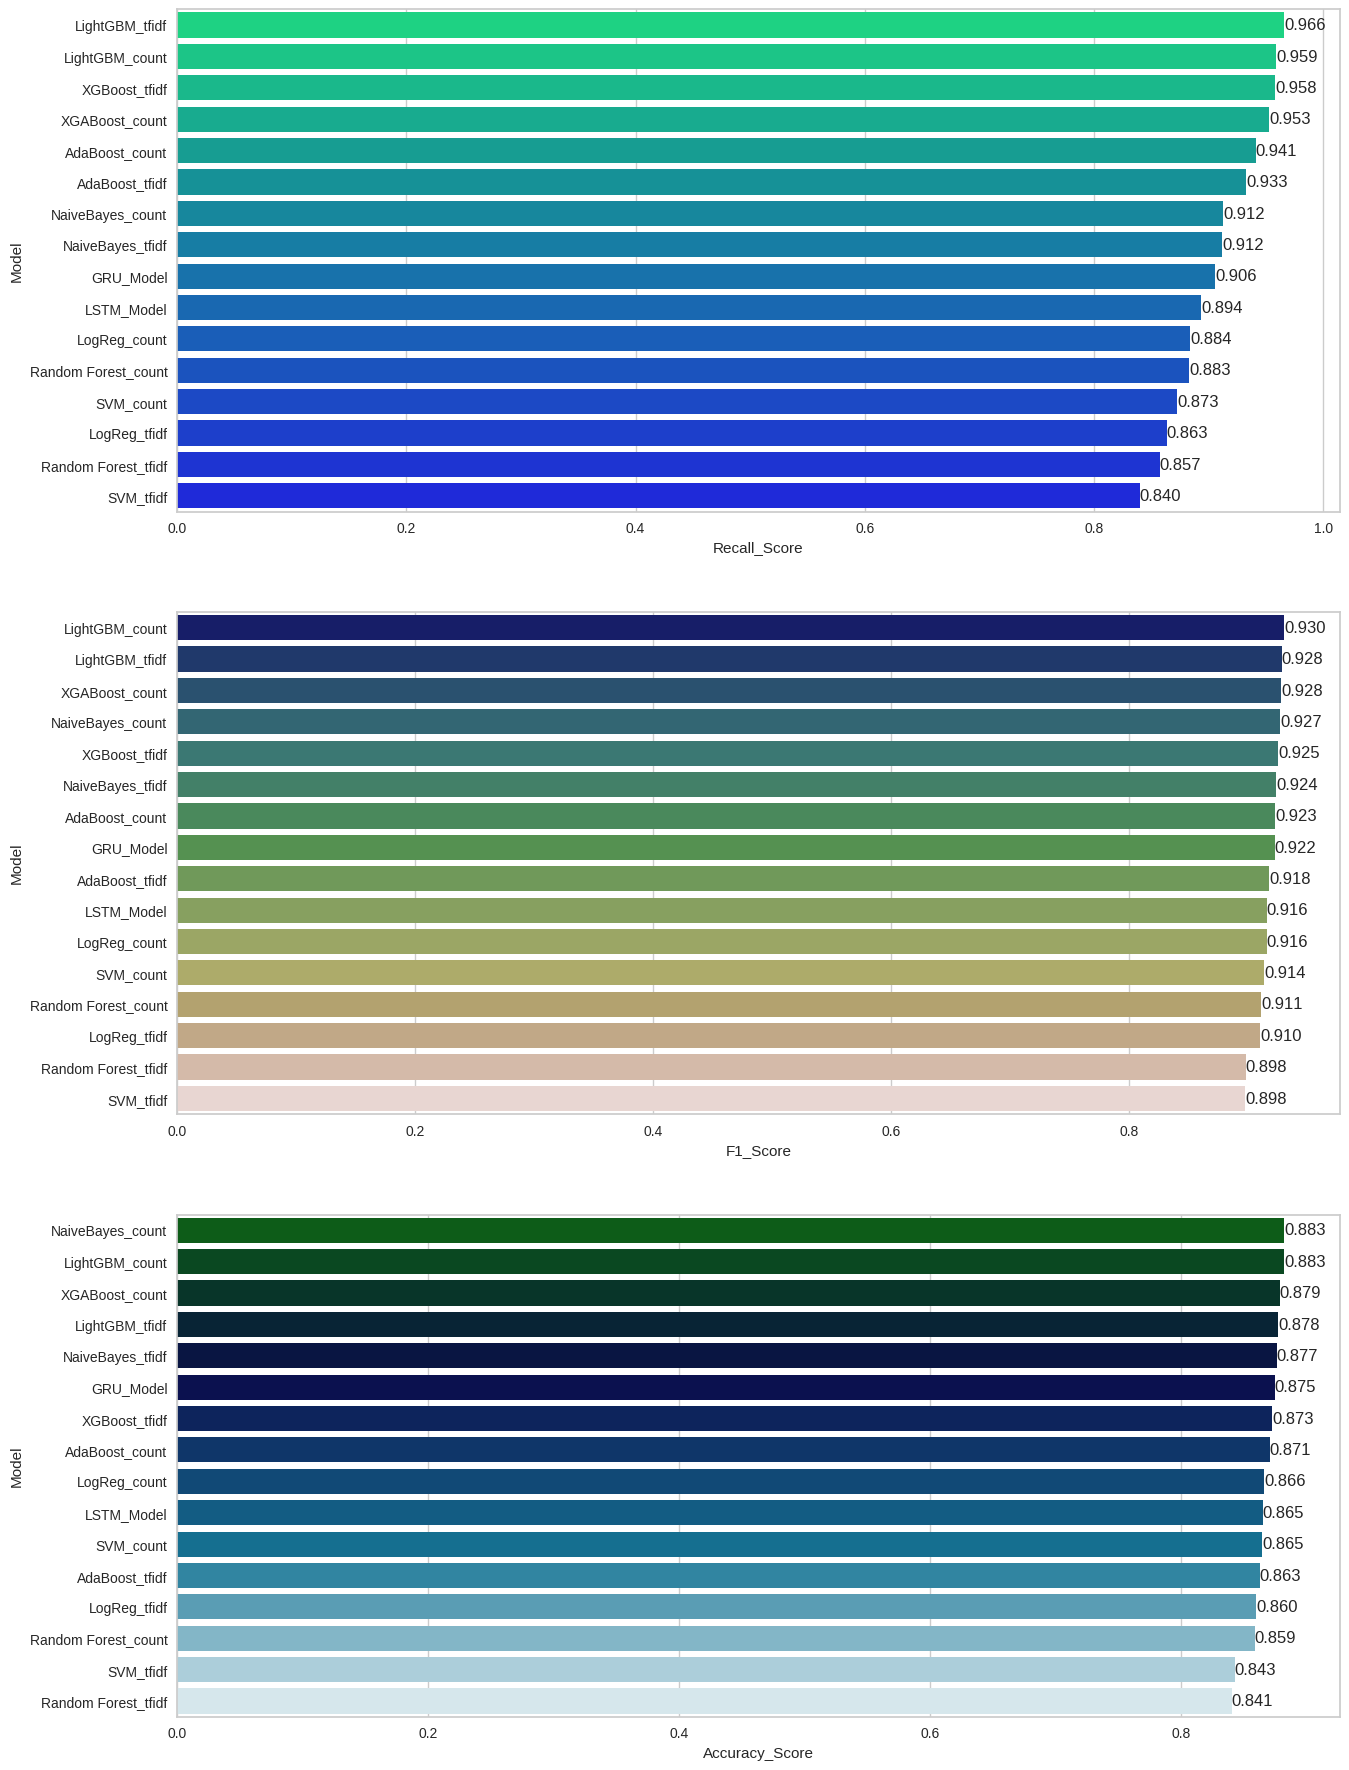

In [296]:
compare = pd.DataFrame({"Model": ["NaiveBayes_count", "LogReg_count", "SVM_count", "Random Forest_count",
                                  "XGABoost_count","AdaBoost_count", "LightGBM_count", "NaiveBayes_tfidf", "LogReg_tfidf", "SVM_tfidf",
                                  "Random Forest_tfidf", "XGBoost_tfidf","AdaBoost_tfidf", "LightGBM_tfidf","LSTM_Model","GRU_Model"],

                        "F1_Score": [nb_count_f1, log_count_f1, svc_count_f1,
                                             rf_count_f1, xgb_count_f1, ada_count_f1, lgb_count_f1, nb_tfidf_f1, log_tfidf_f1,
                                             svc_tfidf_f1, rf_tfidf_f1, xgb_tfidf_f1,ada_tfidf_f1, lgb_tfidf_f1, DLM_f1,DL_f1],

                        "Recall_Score": [nb_count_rec, log_count_rec, svc_count_rec,
                                                   rf_count_rec, xgb_count_rec, ada_count_rec,lgb_count_rec,
                                                  nb_tfidf_rec, log_tfidf_rec, svc_tfidf_rec,
                                                  rf_tfidf_rec, xgb_tfidf_rec, ada_tfidf_rec, lgb_tfidf_rec, DLM_rec,DL_rec],
                        "Accuracy_Score": [nb_count_acc, log_count_acc, svc_count_acc,
                                                   rf_count_acc, xgb_count_acc, ada_count_acc, lgb_count_acc,
                                                  nb_tfidf_acc, log_tfidf_acc, svc_tfidf_acc,
                                                  rf_tfidf_acc, xgb_tfidf_acc, ada_tfidf_acc, lgb_tfidf_acc, DLM_acc,DL_acc],

                        })

def labels(ax):

    for p in ax.patches:
        width = p.get_width()                        # get bar length
        ax.text(width,                               # set the text at 1 unit right of the bar
                p.get_y() + p.get_height() / 2,      # get Y coordinate + X coordinate / 2
                '{:1.3f}'.format(width),             # set variable to display, 2 decimals
                ha = 'left',                         # horizontal alignment
                va = 'center')                       # vertical alignment

plt.figure(figsize=(15,30))
plt.subplot(411)
compare = compare.sort_values(by="Recall_Score", ascending=False)
ax=sns.barplot(x="Recall_Score", y="Model", data=compare, palette="winter_r")
labels(ax)

plt.subplot(412)
compare = compare.sort_values(by="F1_Score", ascending=False)
ax=sns.barplot(x="F1_Score", y="Model", data=compare, palette="gist_earth")
labels(ax)

plt.subplot(413)
compare = compare.sort_values(by="Accuracy_Score", ascending=False)
ax=sns.barplot(x="Accuracy_Score", y="Model", data=compare, palette="ocean")
labels(ax)

plt.show();